# Notebook 2: Hardware-Based Stochastic Number Generation for Robust Multiplication

## Introduction

In Notebook 1, we established the fundamental principles of stochastic computing.

We learned how real-valued numbers can be represented using stochastic bitstreams, how multiplication can be performed using a simple AND operation, and how finite bitstream length affects computational accuracy.

For unipolar stochastic computing, a number:

$$
x \in [0,1]
$$

is represented by a bitstream in which the probability of observing a logic `1` is equal to the represented value:

$$
P(X=1)=x
$$

For two suitably independent stochastic bitstreams $A$ and $B$:

$$
P(A \land B)=P(A=1)P(B=1)
$$

Therefore, multiplication can be implemented using a simple AND operation:

$$
z=x\cdot y
$$

However, the accuracy of stochastic multiplication depends strongly on how the stochastic bitstreams are generated.

This notebook moves beyond software-based random bitstream generation and investigates **hardware-realizable stochastic number generators (SNGs)**.

The objective is to understand how different hardware architectures influence:

- Bitstream representation accuracy
- Distribution of logic `1`s over time
- Dependence between operand streams
- Stochastic multiplication accuracy
- Robustness across a diverse input space
- Performance with short stream lengths

The final objective is to identify a suitable hardware-oriented SNG architecture or configuration for the proposed stochastic vector multiplier.

## From Notebook 1 to Notebook 2

Notebook 1 focused on understanding the fundamental principles of stochastic computing.

The following concepts were established:

1. Representation of real numbers using stochastic bitstreams
2. Encoding and decoding of stochastic values
3. Multiplication using a bitwise AND operation
4. Error caused by finite bitstream length
5. The relationship between stream length and computational accuracy

The bitstreams used in Notebook 1 were primarily generated to understand the mathematical behavior of stochastic computing.

However, a practical hardware implementation requires a **hardware-realizable stochastic number generator (SNG)**.

Therefore, Notebook 2 shifts the focus from:

**Mathematical Stochastic Computing**

to:

$$
\text{Hardware Architecture}
\rightarrow
\text{Bitstream Generation}
\rightarrow
\text{Multiplication Accuracy}
$$

The central question is no longer simply:

> How does stochastic multiplication work?

Instead, we investigate:

> **How does the architecture used to generate stochastic bitstreams influence the accuracy and robustness of stochastic multiplication?**

## Motivation

Two stochastic bitstreams may accurately represent their individual input values while still producing an inaccurate multiplication result.

Consider two inputs:

$$
x=0.6
$$

and:

$$
y=0.7
$$

The ideal mathematical product is:

$$
x\cdot y=0.42
$$

The stochastic multiplication result is obtained using:

$$
S_z=S_x \land S_y
$$

The accuracy of this result depends not only on the number of logic `1`s in each stream, but also on how those logic `1`s are distributed and aligned over time.

For example, two streams may accurately represent their individual values:

$$
\hat{x}=x
$$

and:

$$
\hat{y}=y
$$

but if logic `1`s frequently occur at the same clock positions, the AND operation may produce too many logic `1`s.

Conversely, if logic `1`s rarely overlap, the multiplication result may be underestimated.

Therefore:

$$
\boxed{
\text{Accurate Individual Bitstreams}
\neq
\text{Accurate Stochastic Multiplication}
}
$$

This motivates a systematic investigation of hardware-based stochastic number generation architectures.

## Research Question

The central research question of this notebook is:

> **Which hardware-realizable stochastic number generation architecture provides the most accurate and robust stochastic multiplication performance across a diverse input space?**

The objective is not to optimize an architecture for one specific pair of input values.

Instead, each architecture will be evaluated over a wide range of input combinations.

The desired architecture should demonstrate:

- Low average multiplication error
- Low variation in error
- Low worst-case error
- Stable behavior across different input regions
- Good performance for short stochastic stream lengths
- Practical hardware realizability

Therefore, the concept of the **best overall architecture** is defined as:

$$
\boxed{
\text{Best Overall Architecture}
=
\text{Accuracy}
+
\text{Robustness}
+
\text{Consistency}
+
\text{Hardware Practicality}
}
$$

## Research Hypothesis

This notebook does not assume beforehand that one stochastic number generator will outperform every other architecture.

Instead, the following hypothesis will be investigated:

> **Different hardware-based stochastic number generation architectures will exhibit different multiplication accuracy and robustness characteristics because of differences in sequence generation, temporal distribution, and dependence between operand streams.**

Several outcomes are possible.

### Possibility 1

One architecture provides the lowest average error.

### Possibility 2

Another architecture provides better worst-case behavior.

### Possibility 3

Another architecture performs most consistently across the input space.

### Possibility 4

No single architecture is universally superior.

All of these outcomes are scientifically meaningful.

The final architecture will therefore be selected based on experimental evidence rather than an assumption made before simulation.

## Scope of Investigation

This notebook focuses specifically on **hardware-realizable stochastic number generation architectures**.

The primary candidate architecture families are:

### 1. Conventional LFSR-Based SNG

A pseudo-random sequence is generated using a Linear Feedback Shift Register (LFSR) and converted into a stochastic bitstream using a comparator.

### 2. Counter-Based SNG

A deterministic counter sequence is combined with a comparator to generate the stochastic bitstream.

### 3. Low-Discrepancy SNG

A hardware-oriented sequence generation strategy designed to distribute logic `1`s more uniformly throughout a short stochastic stream.

### 4. Even-Distribution-Based SNG

An architecture based on even-distribution coding and controlled bitstream randomization.

These architectures represent different approaches to stochastic number generation:

$$
\boxed{
\text{Pseudo-Random}
\quad
\text{Deterministic}
\quad
\text{Low-Discrepancy}
\quad
\text{Even-Distribution}
}
$$

The objective is to compare their behavior under identical experimental conditions.

## Target System

The long-term objective of this project is the design of a hardware-oriented stochastic vector multiplier.

The target specifications are:

| Parameter | Target |
|---|---|
| Input representation | 8-bit unsigned operands |
| Stochastic encoding | Unipolar |
| Primary stream lengths | 16 and 32 |
| Multiplication operation | Bitwise AND |
| Final implementation direction | RTL / Verilog |
| Reference architecture | Conventional / Booth multiplier |

For an 8-bit unsigned input:

$$
X \in [0,255]
$$

the normalized stochastic value is:

$$
x=\frac{X}{255}
$$

Similarly:

$$
y=\frac{Y}{255}
$$

The ideal normalized multiplication result is:

$$
z=x\cdot y
$$

The emphasis of this notebook is on short stochastic stream lengths:

$$
\boxed{
L=16
\quad \text{and} \quad
L=32
}
$$

These short lengths are particularly important because the quality of stochastic number generation can strongly influence computational accuracy when only a limited number of stochastic bits are available.

## Experimental Philosophy

A stochastic number generator should not be evaluated using only one input value or one multiplication result.

Instead, each architecture will be evaluated across a broad and systematically distributed input space.

The experimental philosophy is:

$$
\boxed{
\text{Do not optimize for one specific input}
}
$$

Instead:

$$
\boxed{
\text{Optimize for robust performance across the input space}
}
$$

The evaluation will consider the following aspects.

### Individual Stream Quality

Does the generated stochastic stream accurately represent its intended input value?

### Temporal Distribution

How are logic `1`s distributed throughout the stream?

### Operand Dependence

How does the relationship between the two operand streams influence multiplication?

### Multiplication Accuracy

How close is the stochastic multiplication result to the ideal mathematical product?

### Input-Space Robustness

Does the architecture maintain good performance for small, medium, large, and mixed input values?

### Short-Stream Performance

How well does the architecture perform when:

$$
L=16
$$

and:

$$
L=32
$$

The goal is to identify an architecture that performs robustly across diverse operating conditions.

## High-Level Methodology

The investigation in this notebook follows the workflow:

```text
8-bit Input Values
        │
        ▼
Hardware-Based SNG Architecture
        │
        ▼
Generate Stochastic Stream A and Stream B
        │
        ▼
Analyze Stream Quality and Distribution
        │
        ▼
Analyze Stream Dependence
        │
        ▼
Bitwise AND Multiplication
        │
        ▼
Decode Stochastic Result
        │
        ▼
Compare with Exact Product
        │
        ▼
Error and Robustness Analysis
        │
        ▼
Final Hardware-Oriented Architecture Selection

## Expected Outcome

By the end of this notebook, we aim to answer the following questions:

1. Which hardware-based SNG architecture produces the most accurate individual stochastic streams?

2. Which architecture produces the most accurate stochastic multiplication results?

3. How does the temporal distribution of logic `1`s influence multiplication behavior?

4. How does dependence between operand streams influence multiplication error?

5. Which architecture performs most consistently across a diverse input space?

6. Which architecture is most suitable for short stream lengths of:

$$
L = 16
$$

and:

$$
L = 32
$$

7. Which architecture provides the best balance between:

$$
\boxed{
\text{Accuracy}
+
\text{Robustness}
+
\text{Consistency}
+
\text{Hardware Practicality}
}
$$

The results of this notebook will provide the design justification for the next stage of the project:

> ## Proposed Hardware-Oriented Stochastic Vector Multiplier

# Section 0 Summary

This section established the motivation and research objective of Notebook 2.

The investigation now moves from the fundamental mathematical understanding developed in Notebook 1 toward a hardware-oriented analysis of stochastic number generation.

The central principle of this notebook is:

$$
\boxed{
\text{The quality of a stochastic multiplier depends not only on the number of logic 1s generated,}
}
$$

$$
\boxed{
\text{but also on how those bits are generated, distributed, and related between operand streams.}
}
$$

The next section establishes a common experimental framework so that every SNG architecture can be evaluated fairly under identical assumptions.

---

## Next Section

# Section 1: Common Experimental Framework

We will define:

- Number representation
- Unipolar encoding
- 8-bit input assumptions
- Stream lengths
- Input normalization
- Exact reference multiplication
- Common decoding method
- Evaluation metrics

Only after establishing these common rules will we begin implementing and evaluating the hardware-based SNG architectures.

# Section 1: Common Experimental Framework

Before comparing different stochastic number generator (SNG) architectures, a common experimental framework must be established.

Different SNG architectures should not be compared using different input ranges, stream lengths, decoding methods, or error definitions.

Therefore, every architecture investigated in this notebook will operate under the same fundamental assumptions.

The common framework defines:

- Input representation
- Stochastic encoding
- Input normalization
- Stream lengths
- Reference multiplication
- Stream decoding
- Error definitions
- Input-space evaluation strategy

This ensures that any observed performance difference can be attributed primarily to the stochastic number generation architecture rather than differences in the experimental setup.

## 1.1 Input Representation

The target stochastic vector multiplier is intended to operate with two 8-bit unsigned input operands.

Let the two digital inputs be:

$$
X, Y \in \{0,1,2,\ldots,255\}
$$

Each input is an 8-bit unsigned integer.

The corresponding normalized values are defined as:

$$
x = \frac{X}{255}
$$

and:

$$
y = \frac{Y}{255}
$$

Therefore:

$$
x,y \in [0,1]
$$

This normalization allows the 8-bit unsigned inputs to be represented using unipolar stochastic computing.

For example:

| 8-bit Input | Normalized Value |
|---:|---:|
| 0 | 0.0000 |
| 64 | $64/255$ |
| 128 | $128/255$ |
| 192 | $192/255$ |
| 255 | 1.0000 |

The use of 8-bit inputs maintains consistency with the intended hardware implementation of the stochastic vector multiplier.

## 1.2 Unipolar Stochastic Encoding

This notebook uses **unipolar stochastic encoding**.

In unipolar stochastic computing, a value:

$$
x \in [0,1]
$$

is represented by the proportion of logic `1`s in a bitstream.

For a stochastic stream of length $L$:

$$
S = \{s_1,s_2,\ldots,s_L\}
$$

where:

$$
s_i \in \{0,1\}
$$

the decoded value is:

$$
\hat{x}
=
\frac{1}{L}
\sum_{i=1}^{L}s_i
$$

Therefore, the number of logic `1`s determines the represented value.

If a stream contains $N_1$ logic `1`s:

$$
\hat{x}=\frac{N_1}{L}
$$

For example, if:

$$
L=16
$$

and the stream contains:

$$
N_1=8
$$

logic `1`s, then:

$$
\hat{x}=\frac{8}{16}=0.5
$$

An important consequence of finite stream length is that only discrete stochastic values can be represented for a fixed value of $L$.

## 1.3 Finite-Length Stochastic Quantization

A stochastic stream of finite length cannot represent every possible real value exactly.

For a stream of length $L$, the decoded value can only take the form:

$$
\hat{x} \in
\left\{
0,
\frac{1}{L},
\frac{2}{L},
\ldots,
1
\right\}
$$

Therefore, the resolution of the stochastic representation is determined by:

$$
\Delta = \frac{1}{L}
$$

For the primary stream lengths used in this notebook:

### For $L=16$

$$
\Delta=\frac{1}{16}=0.0625
$$

### For $L=32$

$$
\Delta=\frac{1}{32}=0.03125
$$

This creates an important distinction between the original 8-bit input value and its finite-length stochastic representation.

An 8-bit input can take 256 possible values, while a stochastic stream of length 16 can represent only 17 possible decoded levels.

Similarly, a stochastic stream of length 32 can represent only 33 possible decoded levels.

Therefore, the total multiplication error observed in this notebook may contain contributions from:

1. Finite-length representation effects
2. Sequence generation characteristics
3. Temporal distribution of logic `1`s
4. Dependence between operand streams

A major objective of the later experiments will be to distinguish how the SNG architecture influences these effects.

## 1.4 Stream Length Configuration

The primary stochastic stream lengths investigated in this notebook are:

$$
L=16
$$

and:

$$
L=32
$$

These lengths are selected because the proposed stochastic vector multiplier is intended to operate using short stochastic vectors.

The use of short streams is particularly important because stochastic computing typically exhibits a trade-off between:

$$
\text{Accuracy}
\quad \leftrightarrow \quad
\text{Latency / Stream Length}
$$

Longer stochastic streams can provide finer representation resolution, but they require more clock cycles.

Shorter streams reduce latency but increase the importance of:

- Bitstream generation quality
- Distribution of logic `1`s
- Operand dependence
- Sequence properties

Therefore, this notebook focuses specifically on determining which hardware-based SNG architectures perform effectively under short-stream conditions.

In [272]:
# ============================================================
# SECTION 1: COMMON EXPERIMENTAL CONFIGURATION
# ============================================================

INPUT_BITS = 8

INPUT_MIN = 0
INPUT_MAX = (2 ** INPUT_BITS) - 1

STREAM_LENGTHS = [16, 32]

print("Common Experimental Configuration")
print("-" * 45)
print(f"Input width        : {INPUT_BITS}-bit unsigned")
print(f"Input range        : {INPUT_MIN} to {INPUT_MAX}")
print(f"Encoding           : Unipolar")
print(f"Stream lengths     : {STREAM_LENGTHS}")

Common Experimental Configuration
---------------------------------------------
Input width        : 8-bit unsigned
Input range        : 0 to 255
Encoding           : Unipolar
Stream lengths     : [16, 32]


## 1.5 Exact Reference Multiplication

Every stochastic multiplication result requires an exact reference value for comparison.

For two 8-bit unsigned inputs:

$$
X,Y \in [0,255]
$$

the corresponding normalized values are:

$$
x=\frac{X}{255}
$$

and:

$$
y=\frac{Y}{255}
$$

The ideal normalized multiplication result is therefore:

$$
z_{\text{exact}}
=
x\cdot y
$$

or equivalently:

$$
z_{\text{exact}}
=
\frac{X\cdot Y}{255^2}
$$

The exact integer multiplication result is:

$$
P_{\text{integer}}=X\cdot Y
$$

Since two 8-bit unsigned operands are multiplied, the exact integer product can require up to 16 bits.

Therefore, the stochastic multiplier experiments will compare the decoded stochastic result against the ideal normalized product:

$$
z_{\text{exact}}
=
\frac{X\cdot Y}{255^2}
$$

This provides a common mathematical reference for every SNG architecture.

In [273]:
# ============================================================
# INPUT NORMALIZATION AND EXACT REFERENCE FUNCTIONS
# ============================================================

def normalize_input(value, max_value=INPUT_MAX):
    """
    Convert an unsigned digital input into its normalized
    unipolar stochastic computing value.
    """

    if not INPUT_MIN <= value <= max_value:
        raise ValueError(
            f"Input must be between {INPUT_MIN} and {max_value}"
        )

    return value / max_value


def exact_normalized_product(x_int, y_int):
    """
    Calculate the ideal normalized multiplication result
    for two unsigned 8-bit inputs.
    """

    x = normalize_input(x_int)
    y = normalize_input(y_int)

    return x * y


def exact_integer_product(x_int, y_int):
    """
    Calculate the exact conventional integer product.
    """

    return x_int * y_int

In [274]:
# ============================================================
# VERIFY THE COMMON REFERENCE MODEL
# ============================================================

test_pairs = [
    (0, 0),
    (64, 128),
    (128, 128),
    (192, 64),
    (255, 255)
]

print("Reference Multiplication Examples")
print("-" * 70)

for X, Y in test_pairs:

    x = normalize_input(X)
    y = normalize_input(Y)

    product_integer = exact_integer_product(X, Y)
    product_normalized = exact_normalized_product(X, Y)

    print(
        f"X={X:3d}, Y={Y:3d} | "
        f"x={x:.4f}, y={y:.4f} | "
        f"Integer Product={product_integer:5d} | "
        f"Normalized Product={product_normalized:.6f}"
    )

Reference Multiplication Examples
----------------------------------------------------------------------
X=  0, Y=  0 | x=0.0000, y=0.0000 | Integer Product=    0 | Normalized Product=0.000000
X= 64, Y=128 | x=0.2510, y=0.5020 | Integer Product= 8192 | Normalized Product=0.125982
X=128, Y=128 | x=0.5020, y=0.5020 | Integer Product=16384 | Normalized Product=0.251965
X=192, Y= 64 | x=0.7529, y=0.2510 | Integer Product=12288 | Normalized Product=0.188973
X=255, Y=255 | x=1.0000, y=1.0000 | Integer Product=65025 | Normalized Product=1.000000


## 1.6 Stochastic Multiplication Model

For two stochastic operand streams:

$$
S_X=\{s_{x,1},s_{x,2},\ldots,s_{x,L}\}
$$

and:

$$
S_Y=\{s_{y,1},s_{y,2},\ldots,s_{y,L}\}
$$

stochastic multiplication is performed bit-by-bit using an AND operation:

$$
s_{z,i}=s_{x,i}\land s_{y,i}
$$

for:

$$
i=1,2,\ldots,L
$$

The output stream is therefore:

$$
S_Z=S_X\land S_Y
$$

The decoded stochastic multiplication result is:

$$
\hat{z}
=
\frac{1}{L}
\sum_{i=1}^{L}s_{z,i}
$$

The stochastic result will be compared with the exact normalized reference:

$$
z_{\text{exact}}=x\cdot y
$$

The multiplication error is therefore:

$$
e=\hat{z}-z_{\text{exact}}
$$

and the absolute error is:

$$
|e|
=
\left|
\hat{z}-z_{\text{exact}}
\right|
$$

## 1.7 Evaluation Metrics

A single error value is not sufficient to evaluate an SNG architecture across a large input space.

Therefore, several complementary metrics will be used.

### Mean Absolute Error (MAE)

The Mean Absolute Error measures the average magnitude of the multiplication error:

$$
\text{MAE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left|
\hat{z}_i-z_i
\right|
$$

A lower MAE indicates better average accuracy.

---

### Root Mean Squared Error (RMSE)

The Root Mean Squared Error is defined as:

$$
\text{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
(\hat{z}_i-z_i)^2
}
$$

RMSE gives greater importance to larger errors.

---

### Mean Error (Bias)

The average signed error is:

$$
\text{Bias}
=
\frac{1}{N}
\sum_{i=1}^{N}
(\hat{z}_i-z_i)
$$

A positive bias indicates a tendency toward overestimation.

A negative bias indicates a tendency toward underestimation.

---

### Worst-Case Absolute Error

The worst-case error is defined as:

$$
E_{\max}
=
\max
\left(
\left|
\hat{z}_i-z_i
\right|
\right)
$$

This metric identifies the largest error observed across the tested input space.

---

### Error Standard Deviation

The standard deviation of the error indicates how consistently the architecture performs.

A low standard deviation suggests more predictable error behavior across different input conditions.

Together, these metrics provide information about:

$$
\boxed{
\text{Average Accuracy}
+
\text{Large Errors}
+
\text{Bias}
+
\text{Consistency}
}
$$

## 1.8 Fair Comparison Rules

To ensure a meaningful comparison between SNG architectures, the following conditions will remain consistent across all experiments.

### Fixed Conditions

- Input width: 8 bits
- Input range: 0 to 255
- Encoding: Unipolar
- Multiplication operation: Bitwise AND
- Primary stream lengths: 16 and 32
- Reference result: Exact normalized multiplication
- Decoding method: Proportion of logic `1`s
- Error definitions: MAE, RMSE, Bias, standard deviation, and worst-case error

The SNG architecture itself will be the primary variable under investigation.

Where architecture-specific configuration parameters are required, such as:

- LFSR seed
- LFSR implementation style
- Sequence ordering
- Counter initialization
- Operand stream configuration

those parameters will be explicitly documented.

This approach ensures that the experimental comparison remains reproducible and interpretable.

## 1.9 Input-Space Evaluation Strategy

The objective of this notebook is not to determine which architecture performs best for one selected input pair.

Instead, the architectures will be evaluated across a diverse input space.

Two complementary evaluation strategies will be used.

### Structured Input Grid

A systematic set of input combinations will be used to observe how multiplication error changes across different regions of the input space.

This will help identify:

- Regions of low error
- Regions of high error
- Input-dependent behavior
- Symmetry or asymmetry in the error distribution

### Broad Statistical Evaluation

A large and diverse collection of input pairs will be used to estimate overall performance.

This will provide measures such as:

- MAE
- RMSE
- Bias
- Error variation
- Worst-case behavior

The objective is therefore:

$$
\boxed{
\text{Do not select an architecture based on one input condition}
}
$$

Instead:

$$
\boxed{
\text{Evaluate robustness across the input space}
}
$$

An architecture that provides consistently good performance across diverse inputs may be more useful for the final hardware multiplier than an architecture that produces the best result only under selected conditions.

# Section 1 Summary

A common experimental framework has now been established for the investigation of hardware-based stochastic number generators.

The common assumptions are:

- Two 8-bit unsigned input operands
- Input range from 0 to 255
- Unipolar stochastic encoding
- Primary stream lengths of 16 and 32
- Bitwise AND multiplication
- Exact normalized multiplication as the reference
- Common decoding and error metrics
- Evaluation across a diverse input space

The most important principle established in this section is:

$$
\boxed{
\text{All SNG architectures must be evaluated under identical conditions}
}
$$

This allows the influence of the stochastic number generation architecture to be studied systematically and fairly.

---

## Next Section

# Section 2: Common Simulation Infrastructure

The next section will create the reusable Python infrastructure required by every architecture.

We will build:

- Stream validation functions
- Stream decoding functions
- Bitwise stochastic multiplication
- Error calculation functions
- Common result storage

No specific SNG architecture will be implemented yet.

This separation will keep the notebook clean:

$$
\text{Common Infrastructure}
\rightarrow
\text{Architecture Implementation}
\rightarrow
\text{Fair Comparison}
$$

# Section 2: Common Simulation Infrastructure

Before implementing specific stochastic number generator architectures, we first create a common simulation infrastructure.

Every candidate SNG architecture will eventually generate two binary streams:

$$
S_A
$$

and:

$$
S_B
$$

These streams will then pass through the same multiplication and evaluation process.

The common workflow is:

$$
\text{Input}
\rightarrow
\text{SNG}
\rightarrow
\text{Stochastic Stream}
\rightarrow
\text{AND Multiplier}
\rightarrow
\text{Decoded Output}
\rightarrow
\text{Error Analysis}
$$

By separating the common infrastructure from the SNG architectures, the later comparison remains clean, fair, and reproducible.

In [275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2.1 Stochastic Stream Representation

In this notebook, a stochastic stream is represented as a one-dimensional binary NumPy array.

For example:

```text
[1, 0, 1, 1, 0, 0, 1, 0]

In [276]:
def validate_stream(stream):
    """
    Validate that a stochastic stream is a one-dimensional
    binary NumPy-compatible array.
    """

    stream = np.asarray(stream)

    if stream.ndim != 1:
        raise ValueError(
            "The stochastic stream must be one-dimensional."
        )

    if len(stream) == 0:
        raise ValueError(
            "The stochastic stream cannot be empty."
        )

    if not np.all(np.isin(stream, [0, 1])):
        raise ValueError(
            "The stochastic stream must contain only binary values: 0 or 1."
        )

    return stream.astype(int)

In [277]:
# ============================================================
# STOCHASTIC STREAM DECODING
# ============================================================

def decode_stream(stream):
    """
    Decode a unipolar stochastic bitstream.

    The represented value is the proportion of logic 1s.
    """

    stream = validate_stream(stream)

    return np.mean(stream)

In [278]:
# ============================================================
# TEST STOCHASTIC STREAM DECODING
# ============================================================

example_stream = np.array([
    1, 0, 1, 1,
    0, 0, 1, 0
])

decoded_value = decode_stream(example_stream)

print("Example Stream:")
print(example_stream)

print("\nStream Length:")
print(len(example_stream))

print("\nNumber of Logic 1s:")
print(np.sum(example_stream))

print("\nDecoded Value:")
print(decoded_value)

Example Stream:
[1 0 1 1 0 0 1 0]

Stream Length:
8

Number of Logic 1s:
4

Decoded Value:
0.5


## 2.2 Common Stochastic Multiplier

All SNG architectures in this notebook will use the same multiplication hardware model.

For two binary streams:

$$
S_A
=
\{a_1,a_2,\ldots,a_L\}
$$

and:

$$
S_B
=
\{b_1,b_2,\ldots,b_L\}
$$

multiplication is performed bit-by-bit using:

$$
c_i=a_i\land b_i
$$

The output stream is therefore:

$$
S_C=S_A\land S_B
$$

This multiplication block remains identical for every SNG architecture.

Therefore, differences in the final results can be traced primarily to differences in stochastic stream generation.

In [279]:
# ============================================================
# STOCHASTIC AND MULTIPLIER
# ============================================================

def stochastic_and_multiply(stream_a, stream_b):
    """
    Perform stochastic multiplication using a bitwise AND operation.
    """

    stream_a = validate_stream(stream_a)
    stream_b = validate_stream(stream_b)

    if len(stream_a) != len(stream_b):
        raise ValueError(
            "Both stochastic streams must have the same length."
        )

    return np.bitwise_and(stream_a, stream_b)

In [280]:
# ============================================================
# TEST STOCHASTIC MULTIPLICATION
# ============================================================

stream_a = np.array([1, 0, 1, 1, 0, 1, 0, 0])
stream_b = np.array([1, 1, 0, 1, 0, 0, 1, 0])

output_stream = stochastic_and_multiply(stream_a, stream_b)

print("Stream A:")
print(stream_a)

print("\nStream B:")
print(stream_b)

print("\nAND Output:")
print(output_stream)

print("\nDecoded A:", decode_stream(stream_a))
print("Decoded B:", decode_stream(stream_b))
print("Decoded Output:", decode_stream(output_stream))

Stream A:
[1 0 1 1 0 1 0 0]

Stream B:
[1 1 0 1 0 0 1 0]

AND Output:
[1 0 0 1 0 0 0 0]

Decoded A: 0.5
Decoded B: 0.5
Decoded Output: 0.25


## 2.3 Multiplication Error Calculation

The stochastic multiplication result is compared with the exact normalized reference value.

For an input pair:

$$
(X,Y)
$$

the exact normalized product is:

$$
z_{\text{exact}}
=
\frac{X}{255}
\cdot
\frac{Y}{255}
$$

The decoded stochastic result is:

$$
\hat{z}
=
\frac{\text{Number of logic 1s in the output stream}}{L}
$$

The signed error is:

$$
e
=
\hat{z}
-
z_{\text{exact}}
$$

The absolute error is:

$$
|e|
=
\left|
\hat{z}
-
z_{\text{exact}}
\right|
$$

In [281]:
# ============================================================
# MULTIPLICATION ERROR CALCULATION
# ============================================================

def calculate_error(stochastic_result, exact_result):
    """
    Calculate signed and absolute multiplication error.
    """

    signed_error = stochastic_result - exact_result
    absolute_error = abs(signed_error)

    return {
        "signed_error": signed_error,
        "absolute_error": absolute_error
    }

In [282]:
# ============================================================
# COMPLETE STOCHASTIC MULTIPLICATION EVALUATION
# ============================================================

def evaluate_multiplication(
    x_int,
    y_int,
    stream_a,
    stream_b
):
    """
    Evaluate one stochastic multiplication experiment.

    Parameters
    ----------
    x_int : int
        First 8-bit unsigned input.

    y_int : int
        Second 8-bit unsigned input.

    stream_a : array-like
        Stochastic stream representing x_int.

    stream_b : array-like
        Stochastic stream representing y_int.

    Returns
    -------
    dict
        Complete evaluation results.
    """

    # Validate streams
    stream_a = validate_stream(stream_a)
    stream_b = validate_stream(stream_b)

    # Decode input streams
    decoded_a = decode_stream(stream_a)
    decoded_b = decode_stream(stream_b)

    # Perform stochastic multiplication
    output_stream = stochastic_and_multiply(
        stream_a,
        stream_b
    )

    # Decode stochastic output
    stochastic_result = decode_stream(output_stream)

    # Calculate exact reference
    exact_result = exact_normalized_product(
        x_int,
        y_int
    )

    # Calculate error
    error = calculate_error(
        stochastic_result,
        exact_result
    )

    return {
        "x_int": x_int,
        "y_int": y_int,

        "normalized_x": normalize_input(x_int),
        "normalized_y": normalize_input(y_int),

        "decoded_a": decoded_a,
        "decoded_b": decoded_b,

        "stream_length": len(stream_a),

        "output_stream": output_stream,

        "stochastic_result": stochastic_result,
        "exact_result": exact_result,

        "signed_error": error["signed_error"],
        "absolute_error": error["absolute_error"]
    }

In [283]:
# ============================================================
# INFRASTRUCTURE TEST
# ============================================================

test_stream_a = np.array([
    1, 1, 1, 1,
    0, 0, 0, 0
])

test_stream_b = np.array([
    1, 0, 1, 0,
    1, 0, 1, 0
])

result = evaluate_multiplication(
    x_int=128,
    y_int=128,
    stream_a=test_stream_a,
    stream_b=test_stream_b
)

print("Complete Evaluation Result")
print("-" * 50)

for key, value in result.items():

    if key != "output_stream":
        print(f"{key:20}: {value}")

Complete Evaluation Result
--------------------------------------------------
x_int               : 128
y_int               : 128
normalized_x        : 0.5019607843137255
normalized_y        : 0.5019607843137255
decoded_a           : 0.5
decoded_b           : 0.5
stream_length       : 8
stochastic_result   : 0.25
exact_result        : 0.2519646289888504
signed_error        : -0.0019646289888504143
absolute_error      : 0.0019646289888504143


## 2.4 Why a Common Evaluation Function Is Important

Every future SNG architecture will generate its own stochastic streams.

However, once the streams are generated, they will all pass through the same evaluation procedure:

1. Validate the streams
2. Decode the operand streams
3. Perform bitwise AND multiplication
4. Decode the output stream
5. Calculate the exact reference result
6. Calculate multiplication error

This separation is important because it prevents differences in evaluation methodology from influencing the architecture comparison.

The experimental structure is therefore:

$$
\boxed{
\text{SNG Architecture}
\rightarrow
\text{Generated Streams}
\rightarrow
\text{Common Evaluation Engine}
\rightarrow
\text{Performance Metrics}
}
$$

In [284]:
# ============================================================
# DATASET-LEVEL ERROR METRICS
# ============================================================

def calculate_error_metrics(errors):
    """
    Calculate common statistical metrics for a collection
    of signed errors.
    """

    errors = np.asarray(errors)

    absolute_errors = np.abs(errors)

    metrics = {
        "MAE": np.mean(absolute_errors),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
        "Bias": np.mean(errors),
        "Error_STD": np.std(errors),
        "Max_Absolute_Error": np.max(absolute_errors)
    }

    return metrics

In [285]:
# ============================================================
# TEST ERROR METRICS
# ============================================================

example_errors = np.array([
    0.02,
   -0.03,
    0.01,
   -0.04,
    0.00,
    0.02
])

metrics = calculate_error_metrics(example_errors)

print("Example Error Metrics")
print("-" * 40)

for name, value in metrics.items():
    print(f"{name:20}: {value:.6f}")

Example Error Metrics
----------------------------------------
MAE                 : 0.020000
RMSE                : 0.023805
Bias                : -0.003333
Error_STD           : 0.023570
Max_Absolute_Error  : 0.040000


## Section 2 Summary

A reusable common simulation infrastructure has now been established.

The following components are available:

- Binary stream validation
- Unipolar stream decoding
- Bitwise AND multiplication
- Exact multiplication reference
- Signed and absolute error calculation
- Complete evaluation of a multiplication experiment
- Dataset-level statistical error metrics

From this point onward, every SNG architecture will only be responsible for one primary task:

$$
\boxed{
\text{Generate Stream A and Stream B}
}
$$

Everything after stream generation will use the common infrastructure created in this section.

This provides a clean separation between:

$$
\text{Generation}
\rightarrow
\text{Multiplication}
\rightarrow
\text{Evaluation}
$$

---

# Next Section

## Section 3: Candidate Hardware-Based SNG Architectures

The next step will introduce the candidate architecture families and define exactly how each one will be implemented and compared.

# Section 3: Candidate Hardware-Based SNG Architectures

The common simulation and evaluation framework has now been established.

The next step is to define the hardware-oriented stochastic number generation architectures that will be investigated.

The objective is not simply to generate binary streams containing the correct number of logic `1`s.

Different SNG architectures can generate streams containing the same number of logic `1`s while placing those logic `1`s at different positions.

For a stream of length $L$, suppose the target number of logic `1`s is $K$.

The represented stochastic value is:

$$
\hat{x} = \frac{K}{L}
$$

For example, the following two streams both contain four logic `1`s:

    11110000

    10101010

Therefore, both represent:

$$
\hat{x} = \frac{4}{8} = 0.5
$$

However, their temporal distributions are very different.

This difference can influence stochastic multiplication when the stream interacts with another operand stream.

Therefore, the purpose of this section is to define the candidate SNG architectures and establish a fair basis for comparing them.

## 3.1 Common SNG Representation Principle

For the primary experiments, every architecture will receive the same digital input and target the same finite-length stochastic representation.

For an 8-bit input:

$$
X \in [0,255]
$$

and a stream length $L$, the target number of logic `1`s is defined as:

$$
K =
\operatorname{round}
\left(
\frac{X}{255}L
\right)
$$

where:

$$
K \in \{0,1,2,\ldots,L\}
$$

The corresponding finite-length stochastic representation is:

$$
\hat{x} = \frac{K}{L}
$$

This creates an important separation in our experiments.

The number of logic `1`s determines the represented value, while the SNG architecture determines how those logic `1`s are arranged throughout the stream.

Therefore, different architectures can be compared based on their temporal sequence properties while targeting the same representation level.

In [286]:
# ============================================================
# SECTION 3: COMMON SNG REPRESENTATION FUNCTIONS
# ============================================================

def input_to_ones_count(x_int, stream_length):
    """
    Map an 8-bit unsigned input to the target number of logic 1s
    in a finite stochastic stream.
    """

    if not INPUT_MIN <= x_int <= INPUT_MAX:
        raise ValueError(
            f"Input must be between {INPUT_MIN} and {INPUT_MAX}."
        )

    if stream_length <= 0:
        raise ValueError(
            "Stream length must be positive."
        )

    ones_count = int(
        np.round((x_int / INPUT_MAX) * stream_length)
    )

    return int(np.clip(ones_count, 0, stream_length))

In [287]:
# ============================================================
# VERIFY INPUT-TO-ONES MAPPING
# ============================================================

test_inputs = [0, 32, 64, 96, 128, 160, 192, 224, 255]

for L in STREAM_LENGTHS:

    print("=" * 55)
    print(f"Stream Length = {L}")
    print("=" * 55)

    for X in test_inputs:

        K = input_to_ones_count(X, L)
        represented_value = K / L

        print(
            f"Input = {X:3d} | "
            f"Target Ones = {K:2d} | "
            f"Represented Value = {represented_value:.4f}"
        )

    print()

Stream Length = 16
Input =   0 | Target Ones =  0 | Represented Value = 0.0000
Input =  32 | Target Ones =  2 | Represented Value = 0.1250
Input =  64 | Target Ones =  4 | Represented Value = 0.2500
Input =  96 | Target Ones =  6 | Represented Value = 0.3750
Input = 128 | Target Ones =  8 | Represented Value = 0.5000
Input = 160 | Target Ones = 10 | Represented Value = 0.6250
Input = 192 | Target Ones = 12 | Represented Value = 0.7500
Input = 224 | Target Ones = 14 | Represented Value = 0.8750
Input = 255 | Target Ones = 16 | Represented Value = 1.0000

Stream Length = 32
Input =   0 | Target Ones =  0 | Represented Value = 0.0000
Input =  32 | Target Ones =  4 | Represented Value = 0.1250
Input =  64 | Target Ones =  8 | Represented Value = 0.2500
Input =  96 | Target Ones = 12 | Represented Value = 0.3750
Input = 128 | Target Ones = 16 | Represented Value = 0.5000
Input = 160 | Target Ones = 20 | Represented Value = 0.6250
Input = 192 | Target Ones = 24 | Represented Value = 0.7500
I

## 3.2 Candidate Architecture Families

The architectures investigated in this notebook represent different hardware-oriented approaches to stochastic number generation.

### Architecture A: Counter-Based SNG

A deterministic counter generates an ordered sequence of states.

The input value is converted into a stochastic stream using a comparison rule.

This architecture is simple and highly hardware-friendly.

### Architecture B: LFSR-Based SNG

A Linear Feedback Shift Register (LFSR) generates a pseudo-random sequence.

The generated sequence is combined with a comparison mechanism to produce stochastic bits.

This represents a conventional hardware-based approach to stochastic number generation.

### Architecture C: Low-Discrepancy Sequence-Based SNG

A deterministic sequence is designed to provide more uniform coverage across the available positions.

The objective is to reduce clustering and improve distribution quality, especially for short streams.

### Architecture D: Even-Distribution-Based SNG

The logic `1`s are deliberately distributed as evenly as possible throughout the stream.

Instead of allowing large clusters of logic `1`s, the architecture attempts to spread active bits across the available vector positions.

These architectures represent different approaches to generating stochastic streams and will later be evaluated under the same experimental conditions.

## 3.3 Stream-Length Compatibility

The primary target stream lengths in this project are:

$$
L = 16
$$

and:

$$
L = 32
$$

A conventional maximal-length LFSR with $n$ flip-flops naturally produces:

$$
2^n - 1
$$

non-zero states.

Therefore:

For a 4-bit LFSR:

$$
2^4 - 1 = 15
$$

For a 5-bit LFSR:

$$
2^5 - 1 = 31
$$

Therefore, conventional maximal-length LFSR sequences do not naturally have lengths of exactly 16 or 32.

This must be handled carefully to ensure a fair comparison.

The experiments will distinguish between:

1. Natural LFSR sequence experiments using periods of 15 and 31.

2. Fixed-length vector experiments where the final stochastic vector length is exactly 16 or 32.

The primary comparison for the proposed vector multiplier will remain focused on:

$$
L = 16
$$

and:

$$
L = 32
$$

## 3.4 Fair Architecture Comparison

A fair comparison requires separating two different properties.

### Representation Accuracy

The first question is whether the generated stream represents the intended input value.

For a stream containing $K$ logic `1`s:

$$
\hat{x} = \frac{K}{L}
$$

### Temporal Sequence Quality

The second question is how the logic `1`s are arranged throughout the stream.

For example:

    11110000

and:

    10101010

both represent the value:

$$
0.5
$$

but their temporal structures are different.

Therefore, the architecture comparison will examine both:

- Representation quality
- Temporal distribution quality

Whenever possible, all architectures will be tested using the same input values and the same target stream lengths.

This allows the effect of sequence generation itself to be investigated systematically.

## 3.5 Operand Stream Configurations

A stochastic number generator should not be evaluated only as an isolated stream generator.

Stochastic multiplication depends on the interaction between two operand streams:

$$
S_A
$$

and:

$$
S_B
$$

Therefore, the experiments will investigate not only which SNG produces a good individual stream, but also which Stream A and Stream B configuration produces robust multiplication behavior.

The primary configurations will include:

### Configuration 1: Same Architecture for Both Streams

Both Stream A and Stream B use the same SNG architecture.

This represents a symmetric hardware configuration.

### Configuration 2: Same Architecture with Different Configurations

Both streams use the same architecture family but use different sequence configurations.

Examples may include:

- Different LFSR seeds
- Different sequence phases
- Different deterministic permutations

The objective is to investigate whether changing the relationship between the two streams improves multiplication behavior.

### Configuration 3: Different Architectures for Stream A and Stream B

Stream A and Stream B may use different SNG architectures.

For example:

$$
S_A \rightarrow \text{Architecture X}
$$

and:

$$
S_B \rightarrow \text{Architecture Y}
$$

Therefore, the later experiments will evaluate not only individual architectures but also architecture pairs.

The configuration can be represented as:

$$
(\text{SNG}_A,\text{SNG}_B)
$$

because stochastic multiplication depends on the interaction between both operand streams.

In [288]:
# ============================================================
# STREAM REPRESENTATION CHECK
# ============================================================

def check_stream_representation(stream, expected_ones):
    """
    Check whether a generated stream contains the expected
    number of logic 1s.
    """

    stream = validate_stream(stream)

    actual_ones = int(np.sum(stream))
    stream_length = len(stream)

    return {
        "stream_length": stream_length,
        "expected_ones": expected_ones,
        "actual_ones": actual_ones,
        "ones_difference": actual_ones - expected_ones,
        "decoded_value": decode_stream(stream)
    }

## 3.6 Architecture Evaluation Philosophy

No architecture will be declared superior based on a single multiplication example.

Each candidate architecture will eventually be evaluated at several levels.

### Level 1: Individual Stream Properties

- Number of logic `1`s
- Representation accuracy
- Temporal distribution
- Bit clustering

### Level 2: Operand Stream Interaction

- Relationship between Stream A and Stream B
- Alignment behavior
- Dependence between streams

### Level 3: Multiplication Performance

- Signed error
- Absolute error
- Mean Absolute Error
- Root Mean Squared Error
- Bias
- Worst-case error

### Level 4: Input-Space Robustness

The architectures will be evaluated across diverse 8-bit input combinations rather than one selected input pair.

### Level 5: Hardware Practicality

The final interpretation will also consider:

- Hardware complexity
- Required registers
- Comparator requirements
- Counter or feedback logic
- Scalability
- Suitability for RTL implementation

The final architecture selection will therefore consider:

$$
\text{Accuracy}
+
\text{Robustness}
+
\text{Operand Compatibility}
+
\text{Hardware Practicality}
$$

## 3.7 Experimental Roadmap

The candidate architectures will be implemented progressively.

### Step 1: Counter-Based SNG

This provides a simple deterministic and hardware-friendly baseline.

### Step 2: LFSR-Based SNG

This provides a conventional pseudo-random hardware baseline.

### Step 3: Low-Discrepancy SNG

This investigates improved distribution properties for short stochastic streams.

### Step 4: Even-Distribution-Based SNG

This investigates deliberate spreading of logic `1`s throughout the stream.

For every architecture, the following procedure will be used:

1. Generate the stochastic stream.
2. Verify the number of logic `1`s.
3. Examine the temporal distribution.
4. Test representative input values.
5. Store the architecture in a common experimental format.

After all candidate architectures have been implemented and verified, they will be compared using:

- Stream A and Stream B configurations
- Multiplication accuracy
- Input-space robustness
- Dependence analysis
- Short-stream performance
- Hardware practicality

The overall workflow is:

$$
\text{Generate}
\rightarrow
\text{Verify}
\rightarrow
\text{Analyze}
\rightarrow
\text{Combine Streams}
\rightarrow
\text{Multiply}
\rightarrow
\text{Compare}
$$

# Section 3 Summary

This section defined the candidate hardware-oriented stochastic number generator architectures and established the principles for comparing them.

The four primary candidates are:

1. Counter-Based SNG
2. LFSR-Based SNG
3. Low-Discrepancy SNG
4. Even-Distribution-Based SNG

The key principle established in this section is:

The number of logic `1`s determines the represented stochastic value:

$$
\hat{x} = \frac{K}{L}
$$

while the temporal placement of those logic `1`s determines the structure of the stream.

Two streams may represent the same numerical value while producing different multiplication behavior when combined with another stream.

Therefore, the later experiments will investigate both:

- Individual SNG quality
- Stream pair interaction

The final objective is not simply to select the best isolated SNG.

Instead, we aim to identify the most suitable pair:

$$
(\text{SNG}_A,\text{SNG}_B)
$$

for robust short-stream stochastic multiplication.

---

## Next Section

# Section 4: Counter-Based Stochastic Number Generator

The first architecture implemented will be the Counter-Based SNG.

This will provide a simple deterministic and hardware-friendly baseline against which the other architectures can later be compared.

# Section 5: LFSR-Based Stochastic Number Generation

The Counter-Based SNG demonstrated that accurate individual stream representation does not guarantee accurate stochastic multiplication.

The main problem was deterministic alignment between Stream A and Stream B.

This section introduces a hardware-oriented Linear Feedback Shift Register (LFSR) as a pseudo-random sequence generator.

For an $n$-bit maximal-length LFSR, the maximum sequence period is:

$$
P = 2^n - 1
$$

For the 8-bit LFSR used in this notebook:

$$
P = 2^8 - 1 = 255
$$

A maximal-length sequence visits every non-zero register state exactly once before repeating.

The LFSR state is used as an 8-bit pseudo-random number and compared with the 8-bit input to generate each stochastic bit.

The experiments will investigate how different LFSR feedback structures and different initial seeds influence the interaction between Stream A and Stream B.

# Introduction — Hardware-Oriented Stochastic Multiplier Design

## 1. Objective

The objective of this study is to investigate the design and evaluation of a **hardware-oriented stochastic multiplier** for 8-bit unsigned operands.

In conventional binary arithmetic, multiplying two 8-bit numbers produces a 16-bit product:

$$
P_{\text{ideal}} = A \times B
$$

In stochastic computing (SC), numerical values are represented by the **probability of 1s in a stochastic bitstream**. For an 8-bit unsigned value $X$, the normalized representation used in this project is

$$
x = \frac{X}{255}
$$

where

$$
0 \leq x \leq 1
$$

A stochastic bitstream of length $L$ represents this value approximately through its 1-density:

$$
p_X =
\frac{\text{Number of 1s in the bitstream}}{L}
$$

Therefore, the stochastic representation is inherently approximate when a finite stream length is used.

The main goal of this study is not simply to demonstrate stochastic multiplication, but to investigate how the choice of **SNG architecture, LFSR polynomial, seed, stream length, and relationship between stochastic streams** affects multiplication accuracy.

---

## 2. Why Hardware-Oriented SNGs?

A stochastic multiplier requires stochastic bitstreams at its inputs. The quality of these bitstreams directly affects the final multiplication accuracy.

A software random-number generator can generate Bernoulli-distributed bits, but such a generator does not directly represent the type of compact deterministic structure that can be implemented in hardware.

Therefore, this study focuses on **hardware-realizable stochastic number generators (SNGs)**, particularly LFSR-based SNGs.

The basic architecture investigated is:

$$
\boxed{\text{LFSR} + \text{Comparator}}
$$

The LFSR generates a deterministic pseudo-random sequence of states, while the comparator converts each state into a stochastic bit.

For input value $X$:

$$
S_i =
\begin{cases}
1, & \text{if LFSR}_i < X \\
0, & \text{otherwise}
\end{cases}
$$

This provides a hardware-friendly mechanism for generating stochastic representations of 8-bit values.

---

## 3. LFSR Configurations

An 8-bit Fibonacci LFSR is used in this study.

The feedback bit is generated by XORing selected state bits.

Three maximal-length 8-bit LFSR configurations are investigated.

### P1

**Taps:**

$$
[7,5,4,3]
$$

**Feedback:**

$$
f=s_7\oplus s_5\oplus s_4\oplus s_3
$$

### P2

**Taps:**

$$
[7,5,4,1]
$$

**Feedback:**

$$
f=s_7\oplus s_5\oplus s_4\oplus s_1
$$

### P3

**Taps:**

$$
[7,6,1,0]
$$

**Feedback:**

$$
f=s_7\oplus s_6\oplus s_1\oplus s_0
$$

These configurations are maximal-length 8-bit LFSRs. A non-zero seed produces a 255-state cycle before the sequence repeats.

The notation **P2-198** therefore means:

> Polynomial/tap configuration P2 with initial LFSR state (seed) 198.

The polynomial determines the feedback structure, while the seed determines the starting state of the sequence.

---

## 4. Stream Length

Two stochastic stream lengths are investigated:

$$
L=16
$$

and

$$
L=32
$$

The stream length determines the resolution with which a stochastic value can be represented.

For $L=32$, the possible densities are

$$
0,\frac{1}{32},\frac{2}{32},\ldots,\frac{32}{32}
$$

Therefore, the density resolution is

$$
\frac{1}{32}=3.125\%
$$

For $L=16$:

$$
\frac{1}{16}=6.25\%
$$

Thus, increasing the stream length provides finer stochastic resolution and generally reduces finite-stream quantization error, at the cost of requiring more clock cycles.

---

## 5. Stochastic Multiplication

Once stochastic streams representing $A$ and $B$ have been generated, multiplication is performed using an AND gate.

Let the two stochastic streams be $S_A(i)$ and $S_B(i)$.

The output stream is

$$
S_P(i)=S_A(i)\land S_B(i)
$$

If the two stochastic streams are statistically independent, then

$$
p_{\text{AND}}=p_Ap_B
$$

Therefore, the ideal normalized multiplication result is

$$
p_{\text{ideal}}
=
\frac{A}{255}
\frac{B}{255}
$$

This is the fundamental property that makes stochastic multiplication hardware-simple:

$$
\boxed{\text{Multiplication} \rightarrow \text{AND gate}}
$$

However, practical finite-length streams may have representation errors and non-ideal dependence. These effects cause the actual AND density to deviate from the ideal product.

---

# 6. Error Definitions

A major objective of this study is to distinguish the different sources and forms of error.

---

## 6.1 Individual Representation Error

For input $A$, the ideal normalized value is

$$
x=\frac{A}{255}
$$

If the measured stochastic density is $p_A$, the signed representation error is

$$
e_A=p_A-x
$$

The absolute representation error is

$$
\boxed{
E_A=|p_A-x|
}
$$

Similarly, for input $B$:

$$
y=\frac{B}{255}
$$

and

$$
\boxed{
E_B=|p_B-y|
}
$$

For one particular input, this is called **representation error**.

The term MAE is used only when absolute errors are averaged over multiple inputs.

---

## 6.2 Dependence Error

For independent stochastic streams, the expected AND density is

$$
p_Ap_B
$$

The dependence error is therefore defined as

$$
\boxed{
E_{\text{dep}}
=
p_{AND}-p_Ap_B
}
$$

A positive value indicates that the measured AND density is higher than the independent expectation.

A negative value indicates that it is lower.

Dependence error therefore measures the effect of the relationship between the two stochastic streams.

---

## 6.3 Representation-Product Error

Even when the two streams are independent, their measured densities may not exactly equal their ideal values.

The resulting product-representation error is

$$
\boxed{
E_{\text{rep-prod}}
=
p_Ap_B-xy
}
$$

where

$$
x=\frac{A}{255}
$$

and

$$
y=\frac{B}{255}
$$

This represents the contribution of imperfect individual SNG representations to the final multiplication error.

---

## 6.4 Normalized Multiplication Error

The normalized multiplication error is defined as

$$
\boxed{
E_{\text{norm}}
=
p_{AND}-xy
}
$$

where

$$
xy=
\frac{A}{255}\frac{B}{255}
$$

This is the primary multiplication-error quantity used during the exhaustive SNG-pair evaluation.

The error can be decomposed exactly as

$$
\boxed{
E_{\text{norm}}
=
E_{\text{dep}}
+
E_{\text{rep-prod}}
}
$$

because

$$
p_{AND}-xy
=
(p_{AND}-p_Ap_B)
+
(p_Ap_B-xy)
$$

Therefore, the final normalized multiplication error is affected by both:

1. **Dependence between the stochastic streams**
2. **Imperfect representation of the individual operands**

---

## 6.5 Integer-Scale Product Error

The ideal binary product is

$$
P_{\text{actual}}=A\times B
$$

The stochastic product is decoded as

$$
P_{\text{SC}}
=
p_{AND}\times255^2
$$

Therefore, the signed product error is

$$
\boxed{
E_{\text{int}}
=
P_{\text{SC}}-P_{\text{actual}}
}
$$

and the absolute product error is

$$
\boxed{
|E_{\text{int}}|
=
|P_{\text{SC}}-P_{\text{actual}}|
}
$$

The normalized and integer-scale errors are directly related:

$$
\boxed{
E_{\text{int}}
=
E_{\text{norm}}\times255^2
}
$$

Thus, normalized multiplication error and actual product error are **the same underlying error represented on different scales**.

---

## 6.6 Relative Multiplication Percentage Error

For a particular multiplication, the conventional relative percentage error is

$$
\boxed{
E_{\text{relative}}
=
\frac{|P_{\text{SC}}-P_{\text{actual}}|}
{|P_{\text{actual}}|}
\times100\%
}
$$

provided that

$$
P_{\text{actual}}\neq0
$$

The signed relative error is

$$
\boxed{
E_{\text{signed-relative}}
=
\frac{P_{\text{SC}}-P_{\text{actual}}}
{P_{\text{actual}}}
\times100\%
}
$$

This metric is useful for describing the error of a particular numerical multiplication.

However, it is not used as the primary architecture-ranking metric because relative error can become very large for small products and is undefined when the actual product is zero.

---

# 7. Exhaustive SNG-Pair Evaluation

The objective is to identify SNG pairs that perform robustly across the complete 8-bit input range.

The operands satisfy

$$
A,B\in\{0,1,\ldots,255\}
$$

Therefore, the complete multiplication space contains

$$
256\times256=65,536
$$

possible input combinations.

For each candidate SNG pair, the following quantities are evaluated:

- Representation error
- Dependence error
- Representation-product error
- Normalized multiplication error
- Multiplication MAE
- Multiplication RMSE
- Maximum absolute multiplication error
- Multiplication bias

The primary ranking metric is normalized multiplication MAE:

$$
\boxed{
MAE_{\text{mult}}
=
\frac{1}{65,536}
\sum_{A=0}^{255}
\sum_{B=0}^{255}
|E_{\text{norm}}(A,B)|
}
$$

Lower MAE indicates better average multiplication accuracy.

RMSE is used as a secondary metric because it gives greater weight to larger errors.

Maximum absolute error is used as a worst-case indicator.

Bias is used to determine whether the multiplier systematically tends to overestimate or underestimate the ideal result.

---

# 8. Overall Experimental Workflow

The complete investigation follows this sequence:

$$
\boxed{
\text{LFSR Design}
\rightarrow
\text{Polynomial Selection}
\rightarrow
\text{Seed Evaluation}
}
$$

followed by

$$
\boxed{
\text{SNG Representation Analysis}
\rightarrow
\text{Pairwise Stream Analysis}
\rightarrow
\text{AND Multiplication}
}
$$

and finally

$$
\boxed{
\text{Error Decomposition}
\rightarrow
256\times256\text{ Exhaustive Evaluation}
\rightarrow
\text{SNG Pair Ranking}
}
$$

The selected SNG configurations will subsequently be used for RTL implementation and comparison with a conventional binary/Booth multiplier.

---

# 9. Expected Outcome

The study aims to determine:

1. How LFSR polynomial selection affects stochastic sequences.
2. How seed selection affects finite-length stochastic representation.
3. How stream length affects multiplication accuracy.
4. How dependence between stochastic streams affects multiplication.
5. How representation and dependence errors contribute to total multiplication error.
6. Which SNG pair provides the best average multiplication accuracy.
7. How the resulting stochastic multiplier compares with a conventional binary multiplier.

The ultimate objective is therefore to develop a **systematic and hardware-oriented stochastic multiplier design methodology**, rather than selecting an arbitrary stochastic sequence or optimizing the multiplier for only one input pair.

# Pairwise Stream Dependence Analysis

The previous sections evaluated the representation accuracy of individual stochastic number generators (SNGs).

For stochastic multiplication, however, accurate individual streams are not sufficient.

For two stochastic streams \(A\) and \(B\), an AND gate produces:

$$
P(A \land B)=P(A=1,B=1)
$$

For ideally independent streams:

$$
P(A=1,B=1)=P(A=1)P(B=1)
$$

Therefore, this section evaluates how strongly different candidate SNG configurations interact when used together.

The analysis focuses on:

1. Pairwise correlation.
2. Joint-probability dependence.
3. Dependence error relevant to AND-based multiplication.

The objective is to identify promising Stream-A and Stream-B configuration pairs before performing the complete multiplication experiment.

In [289]:
# ============================================================
# GENERATE STOCHASTIC STREAM FROM AN LFSR CANDIDATE
# ============================================================

def generate_stochastic_stream(
    architecture,
    seed,
    input_value,
    stream_length,
    n_bits=8

):
    """
    Generate a stochastic bitstream using an LFSR-based SNG.

    Parameters
    ----------
    architecture : str
        Name of the selected LFSR architecture.

    seed : int
        Non-zero initial LFSR state.

    input_value : int
        Unsigned 8-bit input value (0 to 255).

    stream_length : int
        Number of stochastic bits to generate.

    Returns
    -------
    numpy.ndarray
        Binary stochastic stream.
    """

    taps = LFSR_CONFIGS[architecture]["taps"]

    states = generate_lfsr_sequence(
        seed=seed,
        taps=taps,
        length=stream_length,
        n_bits=n_bits
    )

    stream = (
        states < input_value
    ).astype(int)

    return stream

In [290]:
# ============================================================
# PAIRWISE STREAM DEPENDENCE METRICS
# ============================================================

def calculate_dependence_metrics(stream_a, stream_b):
    """
    Calculate pairwise dependence metrics for two binary streams.
    """

    stream_a = np.asarray(stream_a)
    stream_b = np.asarray(stream_b)

    # Individual probabilities
    p_a = np.mean(stream_a)
    p_b = np.mean(stream_b)

    # Joint probability
    p_ab = np.mean(
        stream_a & stream_b
    )

    # Independence-based expectation
    expected_joint = p_a * p_b

    # Dependence error
    dependence_error = (
        p_ab - expected_joint
    )

    # Pearson correlation coefficient
    #
    # Handle constant streams safely.
    if (
        np.std(stream_a) == 0
        or
        np.std(stream_b) == 0
    ):
        correlation = np.nan

    else:
        correlation = np.corrcoef(
            stream_a,
            stream_b
        )[0, 1]

    return {
        "P_A": p_a,
        "P_B": p_b,
        "P_AB": p_ab,
        "Expected_P_AB": expected_joint,
        "Dependence_Error": dependence_error,
        "Absolute_Dependence_Error": abs(dependence_error),
        "Correlation": correlation
    }

In [291]:
# ============================================================
# SANITY CHECK: ONE STREAM PAIR
# ============================================================

STREAM_LENGTH_TEST = 16

test_candidates = candidate_df[
    candidate_df["Stream_Length"] == STREAM_LENGTH_TEST
].reset_index(drop=True)

candidate_a = test_candidates.iloc[0]
candidate_b = test_candidates.iloc[1]

TEST_INPUT_A = 128
TEST_INPUT_B = 128


stream_a = generate_stochastic_stream(
    architecture=candidate_a["Architecture"],
    seed=int(candidate_a["Seed"]),
    input_value=TEST_INPUT_A,
    stream_length=STREAM_LENGTH_TEST
)

stream_b = generate_stochastic_stream(
    architecture=candidate_b["Architecture"],
    seed=int(candidate_b["Seed"]),
    input_value=TEST_INPUT_B,
    stream_length=STREAM_LENGTH_TEST
)


test_metrics = calculate_dependence_metrics(
    stream_a,
    stream_b
)

print("Candidate A:")
print(
    f"{candidate_a['Architecture']} | "
    f"Seed {int(candidate_a['Seed'])}"
)

print("\nCandidate B:")
print(
    f"{candidate_b['Architecture']} | "
    f"Seed {int(candidate_b['Seed'])}"
)

print("\nDependence Metrics:")
for key, value in test_metrics.items():
    print(f"{key}: {value}")

Candidate A:
P1 | Seed 47

Candidate B:
P1 | Seed 23

Dependence Metrics:
P_A: 0.5
P_B: 0.5
P_AB: 0.25
Expected_P_AB: 0.25
Dependence_Error: 0.0
Absolute_Dependence_Error: 0.0
Correlation: 0.0


## Complete Input-Space Pairwise Dependence Evaluation

Stream dependence can vary with the represented input values.

Therefore, candidate pairs will not be evaluated using only one fixed input.

For every candidate pair, both SNG inputs are evaluated across a representative set of input combinations.

For each combination:

$$
D=P(A \land B)-P(A)P(B)
$$

is calculated.

The final pairwise score is based on the average absolute dependence error across the tested input combinations.

A lower value indicates behavior closer to the independence condition required for accurate AND-based stochastic multiplication.

In [292]:
# ============================================================
# REPRESENTATIVE INPUT GRID
# ============================================================

DEPENDENCE_INPUTS = np.array([
    0,
    16,
    32,
    48,
    64,
    80,
    96,
    112,
    128,
    144,
    160,
    176,
    192,
    208,
    224,
    240,
    255
])

input_pairs = [
    (input_a, input_b)
    for input_a in DEPENDENCE_INPUTS
    for input_b in DEPENDENCE_INPUTS
]

print(
    f"Number of dependence test input pairs: "
    f"{len(input_pairs)}"
)

Number of dependence test input pairs: 289


In [293]:
# ============================================================
# COMPLETE PAIRWISE DEPENDENCE ANALYSIS
# ============================================================

pairwise_dependence_results = []

for stream_length in STREAM_LENGTHS:

    candidates = (
        candidate_df[
            candidate_df["Stream_Length"] == stream_length
        ]
        .reset_index(drop=True)
    )

    print("\n" + "=" * 70)
    print(
        f"ANALYZING PAIRS FOR STREAM LENGTH = "
        f"{stream_length}"
    )
    print("=" * 70)

    for index_a, candidate_a in candidates.iterrows():

        for index_b, candidate_b in candidates.iterrows():

            dependence_errors = []
            correlations = []

            for input_a, input_b in input_pairs:

                stream_a = generate_stochastic_stream(
                    architecture=candidate_a["Architecture"],
                    seed=int(candidate_a["Seed"]),
                    input_value=input_a,
                    stream_length=stream_length
                )

                stream_b = generate_stochastic_stream(
                    architecture=candidate_b["Architecture"],
                    seed=int(candidate_b["Seed"]),
                    input_value=input_b,
                    stream_length=stream_length
                )

                metrics = calculate_dependence_metrics(
                    stream_a,
                    stream_b
                )

                dependence_errors.append(
                    metrics["Absolute_Dependence_Error"]
                )

                if not np.isnan(
                    metrics["Correlation"]
                ):
                    correlations.append(
                        abs(metrics["Correlation"])
                    )

            pairwise_dependence_results.append({

                "Stream_Length": stream_length,

                "Architecture_A":
                    candidate_a["Architecture"],

                "Seed_A":
                    int(candidate_a["Seed"]),

                "Architecture_B":
                    candidate_b["Architecture"],

                "Seed_B":
                    int(candidate_b["Seed"]),

                "Mean_Absolute_Dependence_Error":
                    np.mean(dependence_errors),

                "Max_Absolute_Dependence_Error":
                    np.max(dependence_errors),

                "Mean_Absolute_Correlation":
                    (
                        np.mean(correlations)
                        if correlations else np.nan
                    )
            })


pairwise_dependence_df = pd.DataFrame(
    pairwise_dependence_results
)

print("\nPairwise dependence analysis completed.")

pairwise_dependence_df.head()


ANALYZING PAIRS FOR STREAM LENGTH = 16

ANALYZING PAIRS FOR STREAM LENGTH = 32

Pairwise dependence analysis completed.


,Stream_Length,Architecture_A,Seed_A,Architecture_B,Seed_B,Mean_Absolute_Dependence_Error,Max_Absolute_Dependence_Error,Mean_Absolute_Correlation
0,16,P1,47,P1,47,0.073083,0.250000,0.514223
1,16,P1,47,P1,23,0.035197,0.140625,0.272514
2,16,P1,47,P1,95,0.045929,0.175781,0.325739
3,16,P1,47,P2,161,0.039198,0.140625,0.284044
4,16,P1,47,P2,229,0.030682,0.125000,0.241774


In [294]:
# ============================================================
# RANK CANDIDATE PAIRS
# ============================================================

TOP_PAIRS = 15

for stream_length in STREAM_LENGTHS:

    print("\n" + "=" * 100)
    print(
        f"TOP {TOP_PAIRS} PAIRS WITH LOWEST DEPENDENCE ERROR "
        f"| L = {stream_length}"
    )
    print("=" * 100)

    ranking = (
        pairwise_dependence_df[
            pairwise_dependence_df["Stream_Length"]
            == stream_length
        ]
        .sort_values(
            by=[
                "Mean_Absolute_Dependence_Error",
                "Max_Absolute_Dependence_Error",
                "Mean_Absolute_Correlation"
            ]
        )
        .head(TOP_PAIRS)
        .reset_index(drop=True)
    )

    display(ranking)


TOP 15 PAIRS WITH LOWEST DEPENDENCE ERROR | L = 16


,Stream_Length,Architecture_A,Seed_A,Architecture_B,Seed_B,Mean_Absolute_Dependence_Error,Max_Absolute_Dependence_Error,Mean_Absolute_Correlation
0,16,P3,174,P3,121,0.017788,0.078125,0.146687
1,16,P3,121,P3,174,0.017788,0.078125,0.146687
2,16,P2,161,P3,121,0.019329,0.101562,0.157840
3,16,P3,121,P2,161,0.019329,0.101562,0.157840
4,16,P1,23,P2,229,0.019815,0.101562,0.156656
5,16,P2,229,P1,23,0.019815,0.101562,0.156656
6,16,P1,23,P3,174,0.020734,0.078125,0.170141
7,16,P3,174,P1,23,0.020734,0.078125,0.170141
8,16,P1,47,P3,215,0.022153,0.089844,0.184342
9,16,P3,215,P1,47,0.022153,0.089844,0.184342



TOP 15 PAIRS WITH LOWEST DEPENDENCE ERROR | L = 32


,Stream_Length,Architecture_A,Seed_A,Architecture_B,Seed_B,Mean_Absolute_Dependence_Error,Max_Absolute_Dependence_Error,Mean_Absolute_Correlation
0,32,P2,86,P3,14,0.011563,0.072266,0.094691
1,32,P3,14,P2,86,0.011563,0.072266,0.094691
2,32,P1,163,P3,14,0.013155,0.062500,0.110466
3,32,P3,14,P1,163,0.013155,0.062500,0.110466
4,32,P1,191,P1,140,0.013263,0.078125,0.104968
5,32,P1,140,P1,191,0.013263,0.078125,0.104968
6,32,P3,14,P3,173,0.013739,0.062500,0.110894
7,32,P3,173,P3,14,0.013739,0.062500,0.110894
8,32,P2,86,P1,140,0.014050,0.051758,0.112487
9,32,P1,140,P2,86,0.014050,0.051758,0.112487


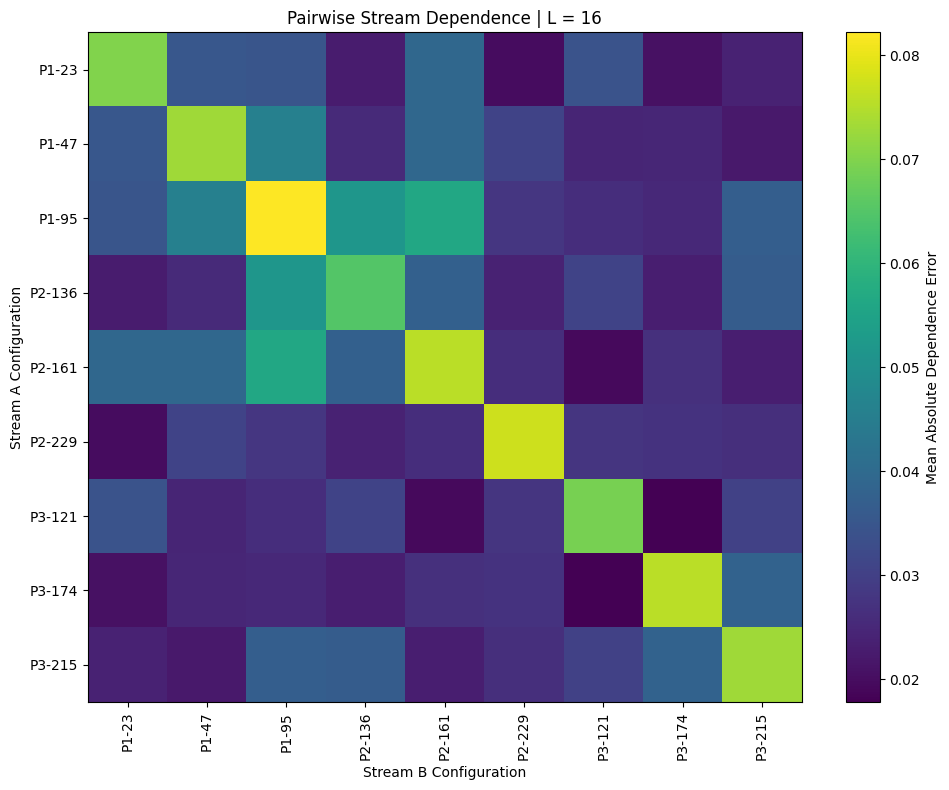

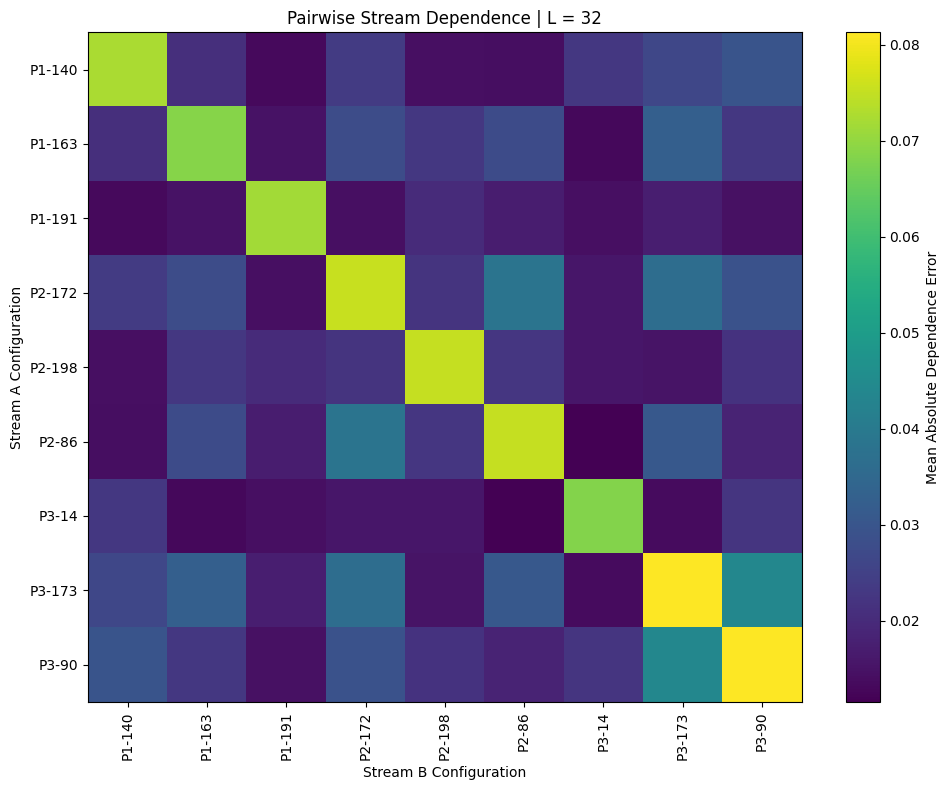

In [295]:
# ============================================================
# PAIRWISE DEPENDENCE HEATMAP
# ============================================================

for stream_length in STREAM_LENGTHS:

    subset = pairwise_dependence_df[
        pairwise_dependence_df["Stream_Length"]
        == stream_length
    ].copy()

    subset["Candidate_A"] = (
        subset["Architecture_A"]
        + "-"
        + subset["Seed_A"].astype(str)
    )

    subset["Candidate_B"] = (
        subset["Architecture_B"]
        + "-"
        + subset["Seed_B"].astype(str)
    )

    heatmap_data = subset.pivot(
        index="Candidate_A",
        columns="Candidate_B",
        values="Mean_Absolute_Dependence_Error"
    )

    plt.figure(figsize=(10, 8))

    plt.imshow(
        heatmap_data.values,
        aspect="auto"
    )

    plt.colorbar(
        label="Mean Absolute Dependence Error"
    )

    plt.xticks(
        range(len(heatmap_data.columns)),
        heatmap_data.columns,
        rotation=90
    )

    plt.yticks(
        range(len(heatmap_data.index)),
        heatmap_data.index
    )

    plt.xlabel("Stream B Configuration")
    plt.ylabel("Stream A Configuration")

    plt.title(
        f"Pairwise Stream Dependence | "
        f"L = {stream_length}"
    )

    plt.tight_layout()

    plt.show()

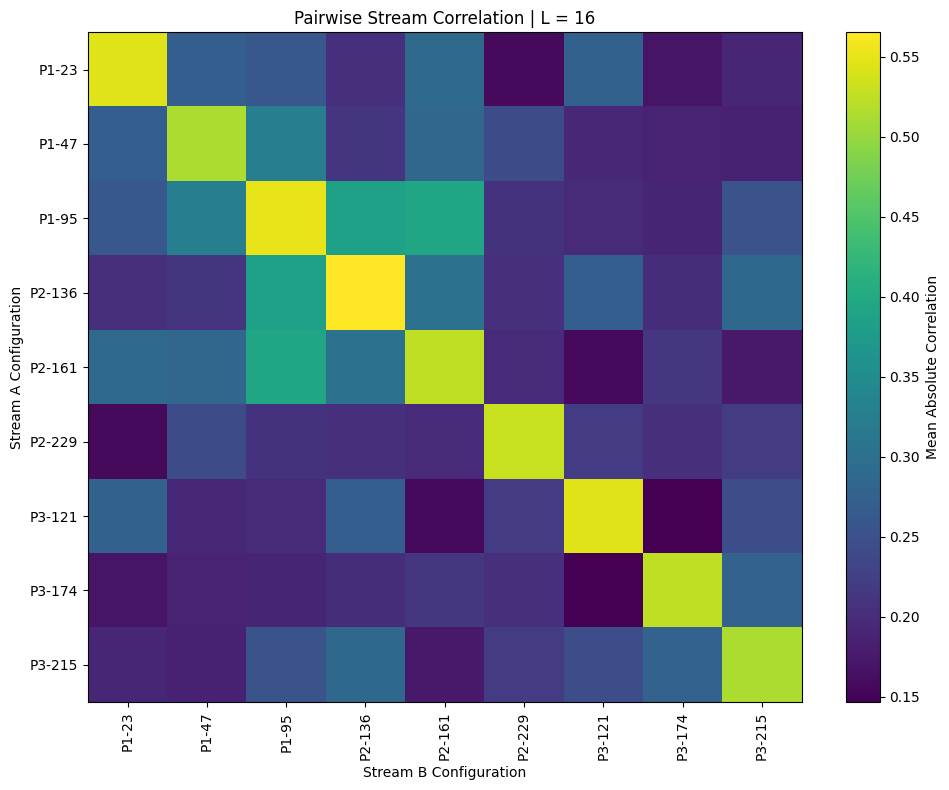

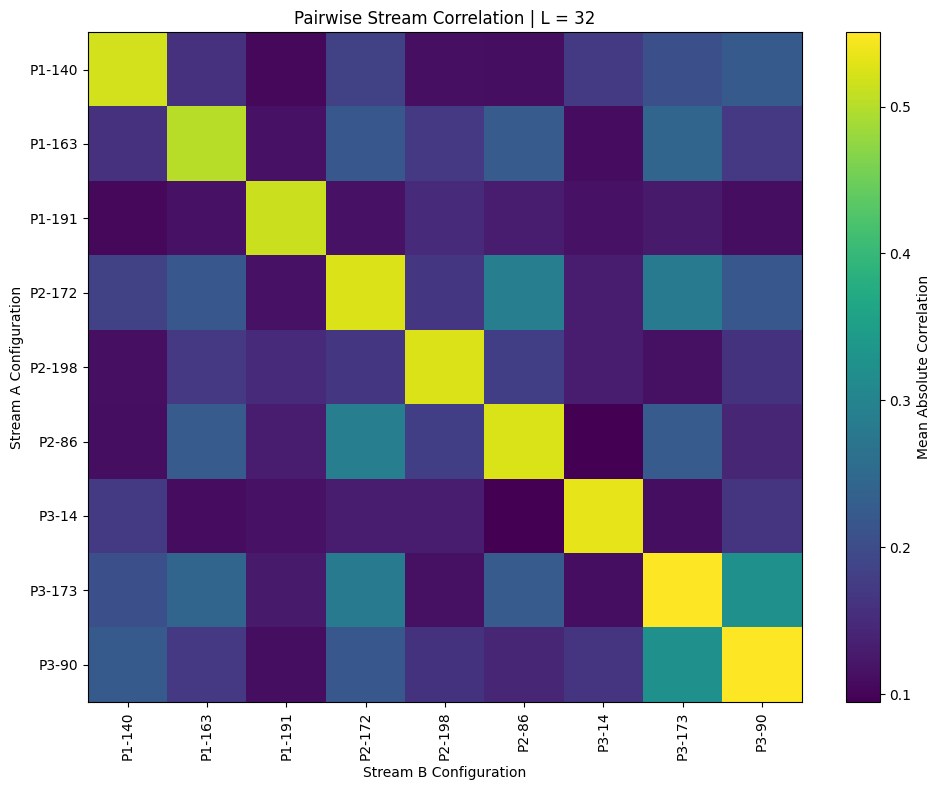

In [296]:
# ============================================================
# PAIRWISE CORRELATION HEATMAP
# ============================================================

for stream_length in STREAM_LENGTHS:

    subset = pairwise_dependence_df[
        pairwise_dependence_df["Stream_Length"]
        == stream_length
    ].copy()

    subset["Candidate_A"] = (
        subset["Architecture_A"]
        + "-"
        + subset["Seed_A"].astype(str)
    )

    subset["Candidate_B"] = (
        subset["Architecture_B"]
        + "-"
        + subset["Seed_B"].astype(str)
    )

    correlation_data = subset.pivot(
        index="Candidate_A",
        columns="Candidate_B",
        values="Mean_Absolute_Correlation"
    )

    plt.figure(figsize=(10, 8))

    plt.imshow(
        correlation_data.values,
        aspect="auto"
    )

    plt.colorbar(
        label="Mean Absolute Correlation"
    )

    plt.xticks(
        range(len(correlation_data.columns)),
        correlation_data.columns,
        rotation=90
    )

    plt.yticks(
        range(len(correlation_data.index)),
        correlation_data.index
    )

    plt.xlabel("Stream B Configuration")
    plt.ylabel("Stream A Configuration")

    plt.title(
        f"Pairwise Stream Correlation | "
        f"L = {stream_length}"
    )

    plt.tight_layout()

    plt.show()

## Interpretation of Pairwise Dependence

The pairwise analysis evaluates whether two individually accurate SNG configurations behave independently when used together.

The primary metric is:

$$
D=P(A \land B)-P(A)P(B)
$$

A value close to zero indicates that the observed joint probability is close to the value expected under independence.

However, low dependence error does not automatically guarantee the lowest multiplication error because finite stochastic streams also contain individual representation error.

Therefore, the next stage will directly evaluate:

$$
\text{Stochastic Product}
=
A \land B
$$

and compare the decoded output against the ideal numerical product.

The strongest final multiplier configuration will therefore be selected using both:

1. Stream dependence behavior.
2. Actual multiplication accuracy.

# Understanding Stream Dependence and the Next Stage of the Experiment

The previous sections of this notebook investigated the behavior of hardware-oriented LFSR-based stochastic number generators (SNGs).

The objective was not simply to find an individual SNG that represents an input accurately. The final objective is to design an accurate stochastic multiplier, which requires two stochastic streams to work correctly **together**.

Therefore, the experiment progressed through multiple stages.

---

## 1. What Has Been Done So Far?

### Stage 1: Individual SNG Representation Analysis

Different maximal-length LFSR architectures and initial seeds were evaluated for stochastic number generation.

For each configuration, the experiment tested how accurately an 8-bit input value was represented by a finite stochastic bitstream.

The main metrics included:

- Mean Absolute Error (MAE)
- Root Mean Square Error (RMSE)
- Bias
- Maximum Absolute Error

The experiment showed that for short stochastic streams:

$$
\text{Seed}
$$

can have a significant effect on representation accuracy.

This occurs because a short stream of length:

$$
L=16 \text{ or } L=32
$$

uses only a small portion of the complete maximal-length LFSR sequence.

Therefore, different initial seeds effectively produce different finite observation windows of the deterministic sequence.

The results suggested that:

$$
\boxed{
\text{Polynomial} + \text{Seed} + \text{Stream Length}
}
$$

jointly affect the quality of stochastic number representation.

---

## 2. Candidate Selection

The complete seed sweep produced a large number of possible SNG configurations.

Testing every possible configuration pair in later experiments would be unnecessarily large and difficult to analyze.

Therefore, a balanced candidate-selection strategy was used.

For each stream length:

$$
L \in \{16,32\}
$$

three strong candidate configurations were selected from each LFSR polynomial family.

Thus:

$$
3 \text{ candidates from P1}
+
3 \text{ candidates from P2}
+
3 \text{ candidates from P3}
=
9 \text{ candidates}
$$

for each stream length.

The purpose was to preserve:

1. Individual representation quality.
2. Architectural diversity.
3. Different initial LFSR states.

The selected candidates were not assumed to be the best multiplier configurations.

Instead, they were considered promising individual SNG configurations that required further pairwise evaluation.

---

# 3. Why Individual Accuracy Is Not Enough

Suppose two SNGs individually represent their inputs accurately.

Let the intended normalized input probabilities be:

$$
x=\frac{X}{255}
$$

and:

$$
y=\frac{Y}{255}
$$

The two stochastic streams may individually have probabilities:

$$
p_A \approx x
$$

and:

$$
p_B \approx y
$$

However, this does not guarantee that the two streams are independent.

For stochastic multiplication using an AND gate, the ideal condition is:

$$
P(A \land B)
=
P(A=1)P(B=1)
$$

or:

$$
P(A=1,B=1)
=
p_Ap_B
$$

This condition is satisfied when the streams behave independently.

If the streams are dependent, then:

$$
P(A=1,B=1)
\neq
p_Ap_B
$$

As a result, two individually accurate stochastic streams may still produce an inaccurate AND-based multiplication result.

Therefore, pairwise stream interaction must be investigated before selecting a final multiplier configuration.

---

# 4. Dependence Error

For two observed stochastic streams, the following probabilities are calculated:

$$
p_A=P(A=1)
$$

$$
p_B=P(B=1)
$$

and:

$$
p_{AB}=P(A=1,B=1)
$$

If the streams were ideally independent, the expected joint probability would be:

$$
p_Ap_B
$$

The dependence error is therefore defined as:

$$
\boxed{
D=p_{AB}-p_Ap_B
}
$$

The ideal value is:

$$
D=0
$$

A positive value indicates that the streams produce simultaneous ones more frequently than expected under independence.

A negative value indicates that simultaneous ones occur less frequently than expected under independence.

Therefore:

$$
\boxed{
D\approx0
}
$$

indicates behavior closer to the independence condition required for accurate stochastic multiplication.

---

# 5. Mean Absolute Dependence Error

The dependence error can vary across different input combinations.

For this reason, the absolute value is first calculated:

$$
|D|
$$

and then averaged over all tested input combinations.

Therefore:

$$
\boxed{
\text{Mean Absolute Dependence Error}
=
\operatorname{mean}(|D|)
}
$$

This metric answers the question:

> **On average, how strongly does this pair of stochastic streams violate the independence condition?**

A smaller value is better.

Ideally:

$$
\text{Mean Absolute Dependence Error}=0
$$

In practice, finite deterministic stochastic streams will usually produce some non-zero dependence.

Therefore, the objective is not necessarily to achieve perfect independence, but to identify configurations with the lowest dependence across a wide range of input values.

This metric is particularly useful as a screening metric because it is directly related to the behavior of the AND multiplication operation.

---

# 6. Maximum Dependence Error

While the mean dependence error describes average behavior, it does not describe the worst possible behavior.

For every tested input combination, the absolute dependence error is calculated:

$$
|D|
$$

The maximum value is:

$$
\boxed{
\text{Maximum Dependence Error}
=
\max(|D|)
}
$$

This metric answers:

> **What is the largest independence violation produced by this SNG pair within the tested input space?**

This is important because a pair may have good average behavior while still producing very large errors for specific input combinations.

For example:

| Configuration | Mean Error | Maximum Error |
|---|---:|---:|
| Pair A | Low | High |
| Pair B | Slightly Higher | Low |

Pair A may be better on average.

However, Pair B may provide better worst-case reliability.

Therefore, both average and maximum dependence behavior are useful for understanding the robustness of a stochastic stream pair.

---

# 7. Mean Absolute Correlation

Correlation provides another way to examine the relationship between two stochastic streams.

For each input combination, the Pearson correlation coefficient is calculated:

$$
\rho(A,B)
$$

The absolute value is used:

$$
|\rho|
$$

and the average value across the tested input combinations is calculated:

$$
\boxed{
\text{Mean Absolute Correlation}
=
\operatorname{mean}(|\rho|)
}
$$

A value close to:

$$
|\rho|=0
$$

indicates weak linear correlation.

A value close to:

$$
|\rho|=1
$$

indicates strong correlation.

Therefore, lower values generally indicate weaker observable relationships between the two streams.

However, correlation is primarily a **diagnostic metric**.

For stochastic multiplication, the more directly relevant quantity is:

$$
P(A=1,B=1)
$$

because the AND gate directly produces the joint event:

$$
A \land B
$$

Therefore, correlation helps explain stream behavior, but it should not be used as the only criterion for selecting the final multiplier architecture.

---

# 8. What the Pairwise Dependence Experiment Achieved

The pairwise experiment evaluated candidate Stream-A and Stream-B configurations using a representative input grid.

The purpose was to answer the following question:

> **Which individually promising SNG configurations also behave well when paired together?**

The experiment demonstrated an important result:

$$
\boxed{
\text{Good individual SNG accuracy does not automatically guarantee good pairwise behavior.}
}
$$

The pairwise interaction depends on several factors:

$$
\boxed{
\text{Polynomial}
+
\text{Seed}
+
\text{Finite Stream Length}
+
\text{Input Values}
}
$$

Therefore, there is no universal rule such as:

> Different polynomials are always better.

or:

> The same polynomial with different seeds is always worse.

Instead, the actual interaction between the deterministic streams must be measured.

This was the primary purpose of the pairwise dependence analysis.

---

# 9. Does Dependence Error Equal Multiplication Error?

No.

This distinction is extremely important.

The dependence experiment measures one important source of multiplication error, but it does not measure the complete multiplication error.

The ideal normalized numerical inputs are:

$$
x=\frac{X}{255}
$$

and:

$$
y=\frac{Y}{255}
$$

The ideal mathematical multiplication result is:

$$
\boxed{
xy
}
$$

However, finite stochastic streams do not necessarily represent the inputs perfectly.

The actual probabilities represented by the generated streams are:

$$
p_A
$$

and:

$$
p_B
$$

Therefore:

$$
p_A\neq x
$$

and:

$$
p_B\neq y
$$

in general.

This creates a representation-related error even before the multiplication operation is considered.

---

# 10. The Complete Stochastic Multiplication Error

The AND gate produces the observed stochastic product:

$$
p_{AND}=P(A\land B)
$$

The actual multiplication error is therefore:

$$
\boxed{
E_{\text{mult}}
=
p_{AND}-xy
}
$$

This is the most important error quantity for the final stochastic multiplier.

To understand where this error comes from, add and subtract:

$$
p_Ap_B
$$

which gives:

$$
p_{AND}-xy
=
(p_{AND}-p_Ap_B)
+
(p_Ap_B-xy)
$$

Therefore:

$$
\boxed{
E_{\text{mult}}
=
E_{\text{dependence}}
+
E_{\text{representation/product}}
}
$$

where:

### Dependence-related component

$$
\boxed{
E_{\text{dependence}}
=
p_{AND}-p_Ap_B
}
$$

This measures the error caused by the interaction between the two streams.

### Representation/product component

$$
\boxed{
E_{\text{representation/product}}
=
p_Ap_B-xy
}
$$

This represents the error caused by finite stochastic representation of the two input values.

Therefore, a configuration may have:

- low dependence error but significant representation error, or
- good individual representation but strong dependence.

The final multiplier must therefore be evaluated using the complete multiplication error.

---

# 11. Why the Representative Input Grid Was Used First

The pairwise dependence analysis initially used a representative grid of input values rather than the complete:

$$
256\times256
$$

input space.

The representative grid was used as a screening stage.

Its purpose was to efficiently identify promising and poor stream pairs before performing a more computationally detailed experiment.

The experiment evaluated:

$$
17\times17=289
$$

representative input combinations for each candidate pair.

This stage successfully reduced the large candidate space into a smaller set of promising stream pairs.

Therefore, the representative-grid experiment should be viewed as:

$$
\boxed{
\text{Screening}
}
$$

rather than final validation.

---

# 12. What Comes Next: Complete 8-Bit Input-Space Validation

The next stage will perform a more complete evaluation.

The strongest unique candidate pairs from the screening experiment will be selected.

Because AND multiplication is commutative:

$$
A\land B=B\land A
$$

the pair:

$$
(A,B)
$$

is equivalent to:

$$
(B,A)
$$

for multiplication purposes.

Therefore, reverse duplicates will be removed before final candidate selection.

The strongest unique pairs will then be evaluated across the complete unsigned 8-bit input space:

$$
X=0,1,2,\dots,255
$$

and:

$$
Y=0,1,2,\dots,255
$$

giving:

$$
\boxed{
256\times256=65,536
}
$$

input combinations for each selected pair.

---

# 13. Metrics for the Complete Experiment

For every input combination, the following quantities will be calculated.

### Intended input probabilities

$$
x=\frac{X}{255}
$$

$$
y=\frac{Y}{255}
$$

### Actual stochastic stream probabilities

$$
p_A
$$

$$
p_B
$$

### Actual AND output

$$
p_{AND}=P(A\land B)
$$

### Dependence error

$$
E_D=p_{AND}-p_Ap_B
$$

### Representation/product error

$$
E_R=p_Ap_B-xy
$$

### Final multiplication error

$$
\boxed{
E_M=p_{AND}-xy
}
$$

The following summary metrics will then be calculated across the complete input space.

---

## Primary Metric: Mean Absolute Multiplication Error

$$
\boxed{
MAE_{\text{mult}}
=
\operatorname{mean}(|E_M|)
}
$$

This will be the primary metric used to identify the best overall multiplier configuration.

It answers:

> **How large is the multiplication error on average across the complete 8-bit input space?**

Lower values indicate better overall multiplication accuracy.

---

## Root Mean Square Error

$$
\boxed{
RMSE_{\text{mult}}
=
\sqrt{
\operatorname{mean}(E_M^2)
}
}
$$

RMSE gives greater importance to larger errors.

Therefore, it helps identify configurations that may occasionally produce large multiplication deviations.

---

## Maximum Absolute Multiplication Error

$$
\boxed{
\max(|E_M|)
}
$$

This identifies the worst multiplication error found anywhere in the complete:

$$
256\times256
$$

input space.

---

## Bias

The mean signed multiplication error will also be calculated:

$$
\boxed{
\operatorname{mean}(E_M)
}
$$

A positive bias indicates a tendency toward overestimation.

A negative bias indicates a tendency toward underestimation.

---

# 14. Final Selection Philosophy

The final multiplier configuration will **not** be selected only because it has the lowest correlation.

It will also not be selected only because it has the lowest dependence error.

The final selection should prioritize:

$$
\boxed{
\text{Actual Multiplication Accuracy}
}
$$

The recommended metric hierarchy is:

### Primary

$$
\boxed{
\text{Mean Absolute Multiplication Error}
}
$$

### Secondary

$$
\boxed{
\text{Maximum Absolute Multiplication Error}
}
$$

and:

$$
\boxed{
RMSE}
$$

### Diagnostic Metrics

- Mean Absolute Dependence Error
- Maximum Dependence Error
- Mean Absolute Correlation

The diagnostic metrics will help explain **why** a particular stream pair performs well or poorly.

---

# 15. Overall Experimental Flow

The complete methodology of Notebook 2 can now be summarized as:

$$
\boxed{
\text{Hardware-Oriented LFSR SNG Design}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Maximal-Length Sequence Verification}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Complete Seed Sweep}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Individual Representation Accuracy}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Balanced Candidate Selection}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Representative Pairwise Dependence Screening}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Selection of Strong Unique Stream Pairs}
}
$$

$$
\downarrow
$$

$$
\boxed{
\textbf{Complete }256\times256\textbf{ Input-Space Evaluation}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Dependence Analysis}
+
\text{Representation Analysis}
+
\textbf{Actual Multiplication Error}
}
$$

$$
\downarrow
$$

$$
\boxed{
\textbf{Final Stochastic Multiplier Pair Selection}
}
$$

---

# Conclusion

The pairwise dependence experiment successfully completed its intended purpose: it identified how different deterministic LFSR-based stochastic streams interact when paired together.

However, dependence is only one component of the final multiplier behavior.

The next stage will therefore perform complete 8-bit input-space validation and directly measure the actual AND-based stochastic multiplication error.

The final objective is to identify a Stream-A and Stream-B configuration that provides:

$$
\boxed{
\text{Low Average Multiplication Error}
+|
\text{Low Worst-Case Error}
+
\text{Low Stream Dependence}
}
$$

across the complete unsigned 8-bit input space.

This final evaluation will provide the strongest basis for selecting the stochastic stream architecture to be used in the subsequent multiplier design and RTL implementation.

# Full 8-Bit Input-Space Multiplier Evaluation

The previous pairwise experiment evaluated the dependence between promising stochastic stream configurations using a representative input grid.

That experiment served as a screening stage.

The final objective, however, is not simply to minimize stream dependence. The objective is to identify the Stream-A and Stream-B configuration that produces the most accurate stochastic multiplication result.

Therefore, the strongest unique candidate pairs will now be evaluated across the complete unsigned 8-bit input space.

For two 8-bit inputs:

$$
X,Y \in \{0,1,2,\dots,255\}
$$

the complete experiment contains:

$$
256\times256=65,536
$$

input combinations for each candidate pair.

For every input combination, the experiment compares the actual stochastic AND output against the ideal numerical product.

The complete evaluation will measure:

- Stream representation probabilities.
- Pairwise dependence error.
- Representation/product error.
- Actual stochastic multiplication error.
- Average-case accuracy.
- Worst-case accuracy.

The final multiplier pair will be selected primarily according to its actual multiplication accuracy across the complete input space.

In [297]:
# ============================================================
# CREATE UNIQUE CANDIDATE PAIRS
# ============================================================

pairwise_unique = pairwise_dependence_df.copy()

# Create a unique identifier for each candidate
pairwise_unique["Candidate_A"] = (
    pairwise_unique["Architecture_A"].astype(str)
    + "_"
    + pairwise_unique["Seed_A"].astype(str)
)

pairwise_unique["Candidate_B"] = (
    pairwise_unique["Architecture_B"].astype(str)
    + "_"
    + pairwise_unique["Seed_B"].astype(str)
)

# Create an order-independent pair identifier
pairwise_unique["Pair_ID"] = pairwise_unique.apply(
    lambda row: " | ".join(
        sorted([
            row["Candidate_A"],
            row["Candidate_B"]
        ])
    ),
    axis=1
)

# Remove reverse duplicates
unique_pairs_df = (
    pairwise_unique
    .drop_duplicates(
        subset=["Stream_Length", "Pair_ID"]
    )
    .copy()
)

# Remove self-pairs for final candidate competition
unique_pairs_df = unique_pairs_df[
    unique_pairs_df["Candidate_A"]
    != unique_pairs_df["Candidate_B"]
].copy()

print("Total unique non-self pairs:")

for L in STREAM_LENGTHS:
    count = len(
        unique_pairs_df[
            unique_pairs_df["Stream_Length"] == L
        ]
    )

    print(f"L = {L}: {count} unique pairs")

Total unique non-self pairs:
L = 16: 36 unique pairs
L = 32: 36 unique pairs


In [298]:
# ============================================================
# SELECT TOP UNIQUE PAIRS FOR FULL VALIDATION
# ============================================================

TOP_K = 5

top_pairs_by_length = {}

for L in STREAM_LENGTHS:

    top_pairs = (
        unique_pairs_df[
            unique_pairs_df["Stream_Length"] == L
        ]
        .sort_values(
            by=[
                "Mean_Absolute_Dependence_Error",
                "Max_Absolute_Dependence_Error",
                "Mean_Absolute_Correlation"
            ]
        )
        .head(TOP_K)
        .reset_index(drop=True)
    )

    top_pairs_by_length[L] = top_pairs

    print("\n" + "=" * 90)
    print(f"TOP {TOP_K} UNIQUE PAIRS FOR L = {L}")
    print("=" * 90)

    display(
        top_pairs[
            [
                "Architecture_A",
                "Seed_A",
                "Architecture_B",
                "Seed_B",
                "Mean_Absolute_Dependence_Error",
                "Max_Absolute_Dependence_Error",
                "Mean_Absolute_Correlation"
            ]
        ]
    )


TOP 5 UNIQUE PAIRS FOR L = 16


,Architecture_A,Seed_A,Architecture_B,Seed_B,Mean_Absolute_Dependence_Error,Max_Absolute_Dependence_Error,Mean_Absolute_Correlation
0,P3,174,P3,121,0.017788,0.078125,0.146687
1,P2,161,P3,121,0.019329,0.101562,0.157840
2,P1,23,P2,229,0.019815,0.101562,0.156656
3,P1,23,P3,174,0.020734,0.078125,0.170141
4,P1,47,P3,215,0.022153,0.089844,0.184342



TOP 5 UNIQUE PAIRS FOR L = 32


,Architecture_A,Seed_A,Architecture_B,Seed_B,Mean_Absolute_Dependence_Error,Max_Absolute_Dependence_Error,Mean_Absolute_Correlation
0,P2,86,P3,14,0.011563,0.072266,0.094691
1,P1,163,P3,14,0.013155,0.062500,0.110466
2,P1,191,P1,140,0.013263,0.078125,0.104968
3,P3,14,P3,173,0.013739,0.062500,0.110894
4,P1,140,P2,86,0.014050,0.051758,0.112487


## Exhaustive Multiplier Evaluation

The selected candidate pairs will now be tested using every possible unsigned 8-bit input combination.

For each pair:

$$
X=0,1,\dots,255
$$

and:

$$
Y=0,1,\dots,255
$$

For each combination, the ideal normalized multiplication result is:

$$
x=\frac{X}{255}
$$

$$
y=\frac{Y}{255}
$$

$$
P_{\text{ideal}}=xy
$$

The two stochastic streams are generated using their respective LFSR configurations.

The AND gate produces:

$$
P_{\text{AND}}
=
P(A\land B)
$$

The final multiplication error is:

$$
\boxed{
E_{\text{mult}}
=
P_{\text{AND}}-xy
}
$$

This will be the primary quantity used to evaluate the final multiplier pair.

In [299]:
# ============================================================
# PRECOMPUTE ALL STOCHASTIC STREAMS
# ============================================================

def precompute_candidate_streams(
    architecture,
    seed,
    stream_length,
    n_bits=8
):
    """
    Precompute stochastic streams for all 256 possible
    unsigned 8-bit input values.

    Returns
    -------
    states : ndarray
        LFSR state sequence.

    streams : ndarray
        Shape = (256, stream_length)

        streams[x] represents the stochastic bitstream
        corresponding to input value x.
    """

    taps = LFSR_CONFIGS[architecture]["taps"]

    states = generate_lfsr_sequence(
        seed=int(seed),
        taps=taps,
        length=stream_length,
        n_bits=n_bits
    )

    input_values = np.arange(256)

    # Generate all 256 stochastic streams simultaneously
    streams = (
        states[np.newaxis, :]
        < input_values[:, np.newaxis]
    ).astype(np.uint8)

    return states, streams

In [300]:
# ============================================================
# FULL 256 x 256 MULTIPLIER EVALUATION
# ============================================================

def evaluate_full_input_space(
    architecture_a,
    seed_a,
    architecture_b,
    seed_b,
    stream_length
):
    """
    Evaluate one SNG pair over all 256 x 256 unsigned
    8-bit input combinations.
    """

    # --------------------------------------------------------
    # Precompute streams for Stream A
    # --------------------------------------------------------

    _, streams_a = precompute_candidate_streams(
        architecture=architecture_a,
        seed=seed_a,
        stream_length=stream_length
    )

    # --------------------------------------------------------
    # Precompute streams for Stream B
    # --------------------------------------------------------

    _, streams_b = precompute_candidate_streams(
        architecture=architecture_b,
        seed=seed_b,
        stream_length=stream_length
    )

    # --------------------------------------------------------
    # Actual represented probabilities
    # --------------------------------------------------------

    p_a = streams_a.mean(axis=1)

    p_b = streams_b.mean(axis=1)

    # --------------------------------------------------------
    # AND output for every input combination
    #
    # Shape:
    # (256, 256, stream_length)
    # --------------------------------------------------------

    and_streams = (
        streams_a[:, np.newaxis, :]
        &
        streams_b[np.newaxis, :, :]
    )

    p_and = and_streams.mean(axis=2)

    # --------------------------------------------------------
    # Ideal normalized inputs
    # --------------------------------------------------------

    inputs = np.arange(256)

    x = inputs / 255.0
    y = inputs / 255.0

    ideal_product = (
        x[:, np.newaxis]
        *
        y[np.newaxis, :]
    )

    # --------------------------------------------------------
    # Product of actual represented probabilities
    # --------------------------------------------------------

    represented_product = (
        p_a[:, np.newaxis]
        *
        p_b[np.newaxis, :]
    )

    # --------------------------------------------------------
    # Error Components
    # --------------------------------------------------------

    dependence_error = (
        p_and - represented_product
    )

    representation_error = (
        represented_product - ideal_product
    )

    multiplication_error = (
        p_and - ideal_product
    )

    # --------------------------------------------------------
    # Summary Metrics
    # --------------------------------------------------------

    results = {

        # Dependence metrics
        "Mean_Absolute_Dependence_Error":
            np.mean(np.abs(dependence_error)),

        "Maximum_Absolute_Dependence_Error":
            np.max(np.abs(dependence_error)),

        # Representation/product metrics
        "Mean_Absolute_Representation_Error":
            np.mean(np.abs(representation_error)),

        # Final multiplication metrics
        "Multiplication_MAE":
            np.mean(np.abs(multiplication_error)),

        "Multiplication_RMSE":
            np.sqrt(
                np.mean(
                    multiplication_error ** 2
                )
            ),

        "Maximum_Absolute_Multiplication_Error":
            np.max(
                np.abs(multiplication_error)
            ),

        "Multiplication_Bias":
            np.mean(multiplication_error)
    }

    return results, {
        "p_a": p_a,
        "p_b": p_b,
        "p_and": p_and,
        "ideal_product": ideal_product,
        "dependence_error": dependence_error,
        "representation_error": representation_error,
        "multiplication_error": multiplication_error
    }

In [301]:
# ============================================================
# RUN COMPLETE FULL-SPACE EVALUATION
# ============================================================

full_space_results = []

full_space_details = {}

for L in STREAM_LENGTHS:

    print("\n" + "=" * 80)
    print(
        f"FULL 256 x 256 EVALUATION | "
        f"STREAM LENGTH = {L}"
    )
    print("=" * 80)

    selected_pairs = top_pairs_by_length[L]

    for index, pair in selected_pairs.iterrows():

        architecture_a = pair["Architecture_A"]
        seed_a = int(pair["Seed_A"])

        architecture_b = pair["Architecture_B"]
        seed_b = int(pair["Seed_B"])

        print(
            f"\nEvaluating Pair {index + 1}/{len(selected_pairs)}:"
        )

        print(
            f"  Stream A: {architecture_a}, Seed {seed_a}"
        )

        print(
            f"  Stream B: {architecture_b}, Seed {seed_b}"
        )

        metrics, details = evaluate_full_input_space(
            architecture_a=architecture_a,
            seed_a=seed_a,
            architecture_b=architecture_b,
            seed_b=seed_b,
            stream_length=L
        )

        pair_name = (
            f"{architecture_a}-{seed_a}"
            f" × "
            f"{architecture_b}-{seed_b}"
        )

        full_space_details[
            (L, pair_name)
        ] = details

        result_row = {

            "Stream_Length": L,

            "Pair": pair_name,

            "Architecture_A": architecture_a,
            "Seed_A": seed_a,

            "Architecture_B": architecture_b,
            "Seed_B": seed_b,

            **metrics
        }

        full_space_results.append(result_row)


full_space_results_df = pd.DataFrame(
    full_space_results
)

print("\n")
print("=" * 80)
print("FULL INPUT-SPACE EVALUATION COMPLETED")
print("=" * 80)

display(full_space_results_df)


FULL 256 x 256 EVALUATION | STREAM LENGTH = 16

Evaluating Pair 1/5:
  Stream A: P3, Seed 174
  Stream B: P3, Seed 121

Evaluating Pair 2/5:
  Stream A: P2, Seed 161
  Stream B: P3, Seed 121

Evaluating Pair 3/5:
  Stream A: P1, Seed 23
  Stream B: P2, Seed 229

Evaluating Pair 4/5:
  Stream A: P1, Seed 23
  Stream B: P3, Seed 174

Evaluating Pair 5/5:
  Stream A: P1, Seed 47
  Stream B: P3, Seed 215

FULL 256 x 256 EVALUATION | STREAM LENGTH = 32

Evaluating Pair 1/5:
  Stream A: P2, Seed 86
  Stream B: P3, Seed 14

Evaluating Pair 2/5:
  Stream A: P1, Seed 163
  Stream B: P3, Seed 14

Evaluating Pair 3/5:
  Stream A: P1, Seed 191
  Stream B: P1, Seed 140

Evaluating Pair 4/5:
  Stream A: P3, Seed 14
  Stream B: P3, Seed 173

Evaluating Pair 5/5:
  Stream A: P1, Seed 140
  Stream B: P2, Seed 86


FULL INPUT-SPACE EVALUATION COMPLETED


,Stream_Length,Pair,Architecture_A,Seed_A,Architecture_B,Seed_B,Mean_Absolute_Dependence_Error,Maximum_Absolute_Dependence_Error,Mean_Absolute_Representation_Error,Multiplication_MAE,Multiplication_RMSE,Maximum_Absolute_Multiplication_Error,Multiplication_Bias
0,16,P3-174 × P3-121,P3,174,P3,121,0.020523,0.078125,0.018233,0.027448,0.034734,0.126356,0.000868
1,16,P2-161 × P3-121,P2,161,P3,121,0.022311,0.101562,0.017926,0.030099,0.038055,0.133555,-0.004637
2,16,P1-23 × P2-229,P1,23,P2,229,0.020663,0.101562,0.019903,0.031594,0.040261,0.158953,-0.014522
3,16,P1-23 × P3-174,P1,23,P3,174,0.022246,0.101562,0.018697,0.030976,0.039020,0.159193,-0.011065
4,16,P1-47 × P3-215,P1,47,P3,215,0.023932,0.089844,0.017482,0.030512,0.038222,0.123304,-0.005976
5,32,P2-86 × P3-14,P2,86,P3,14,0.013346,0.072266,0.018107,0.025462,0.032437,0.111761,0.016349
6,32,P1-163 × P3-14,P1,163,P3,14,0.015011,0.070312,0.014665,0.022175,0.028727,0.108524,0.009962
7,32,P1-191 × P1-140,P1,191,P1,140,0.015733,0.078125,0.012156,0.020190,0.025683,0.101324,-0.005108
8,32,P3-14 × P3-173,P3,14,P3,173,0.015175,0.068359,0.014184,0.022780,0.028905,0.104428,0.003957
9,32,P1-140 × P2-86,P1,140,P2,86,0.016093,0.063477,0.017823,0.025887,0.032753,0.120488,0.019336


In [302]:
# ============================================================
# FINAL RANKING BY MULTIPLICATION ACCURACY
# ============================================================

for L in STREAM_LENGTHS:

    ranking = (
        full_space_results_df[
            full_space_results_df["Stream_Length"] == L
        ]
        .sort_values(
            by=[
                "Multiplication_MAE",
                "Multiplication_RMSE",
                "Maximum_Absolute_Multiplication_Error"
            ]
        )
        .reset_index(drop=True)
    )

    print("\n" + "=" * 100)
    print(
        f"FINAL MULTIPLICATION RANKING | "
        f"L = {L}"
    )
    print("=" * 100)

    display(
        ranking[
            [
                "Pair",
                "Multiplication_MAE",
                "Multiplication_RMSE",
                "Maximum_Absolute_Multiplication_Error",
                "Multiplication_Bias",
                "Mean_Absolute_Dependence_Error",
                "Mean_Absolute_Representation_Error"
            ]
        ]
    )


FINAL MULTIPLICATION RANKING | L = 16


,Pair,Multiplication_MAE,Multiplication_RMSE,Maximum_Absolute_Multiplication_Error,Multiplication_Bias,Mean_Absolute_Dependence_Error,Mean_Absolute_Representation_Error
0,P3-174 × P3-121,0.027448,0.034734,0.126356,0.000868,0.020523,0.018233
1,P2-161 × P3-121,0.030099,0.038055,0.133555,-0.004637,0.022311,0.017926
2,P1-47 × P3-215,0.030512,0.038222,0.123304,-0.005976,0.023932,0.017482
3,P1-23 × P3-174,0.030976,0.039020,0.159193,-0.011065,0.022246,0.018697
4,P1-23 × P2-229,0.031594,0.040261,0.158953,-0.014522,0.020663,0.019903



FINAL MULTIPLICATION RANKING | L = 32


,Pair,Multiplication_MAE,Multiplication_RMSE,Maximum_Absolute_Multiplication_Error,Multiplication_Bias,Mean_Absolute_Dependence_Error,Mean_Absolute_Representation_Error
0,P1-191 × P1-140,0.020190,0.025683,0.101324,-0.005108,0.015733,0.012156
1,P1-163 × P3-14,0.022175,0.028727,0.108524,0.009962,0.015011,0.014665
2,P3-14 × P3-173,0.022780,0.028905,0.104428,0.003957,0.015175,0.014184
3,P2-86 × P3-14,0.025462,0.032437,0.111761,0.016349,0.013346,0.018107
4,P1-140 × P2-86,0.025887,0.032753,0.120488,0.019336,0.016093,0.017823


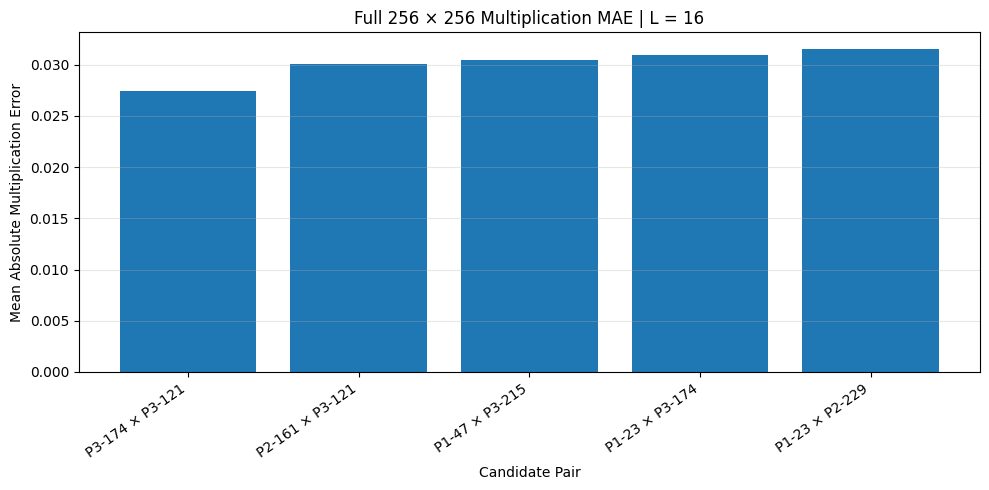

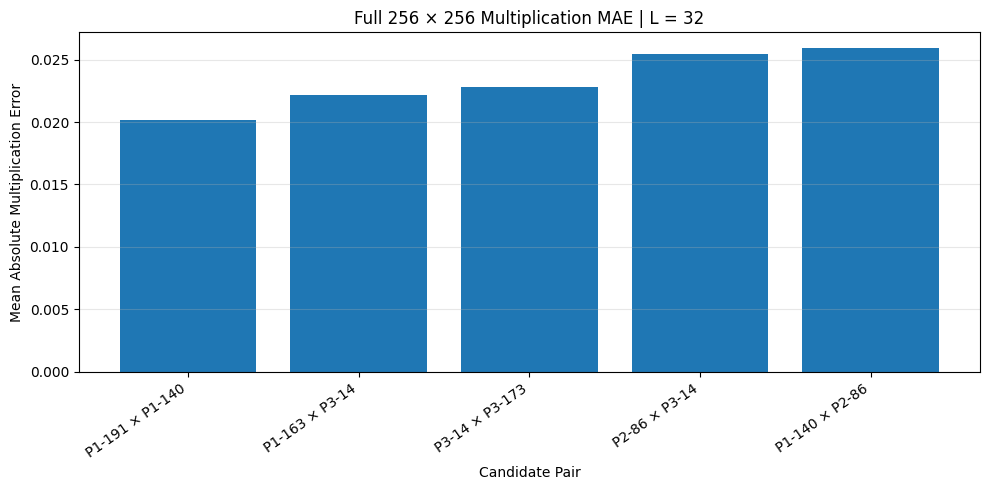

In [303]:
# ============================================================
# MULTIPLICATION MAE COMPARISON
# ============================================================

for L in STREAM_LENGTHS:

    subset = (
        full_space_results_df[
            full_space_results_df["Stream_Length"] == L
        ]
        .sort_values("Multiplication_MAE")
    )

    plt.figure(figsize=(10, 5))

    plt.bar(
        subset["Pair"],
        subset["Multiplication_MAE"]
    )

    plt.xlabel("Candidate Pair")
    plt.ylabel("Mean Absolute Multiplication Error")

    plt.title(
        f"Full 256 × 256 Multiplication MAE | L = {L}"
    )

    plt.xticks(rotation=35, ha="right")

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

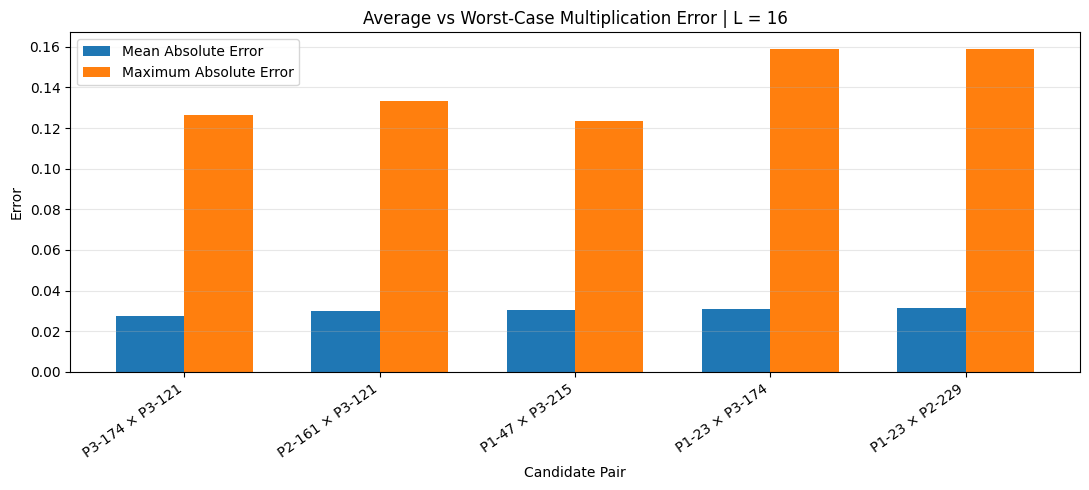

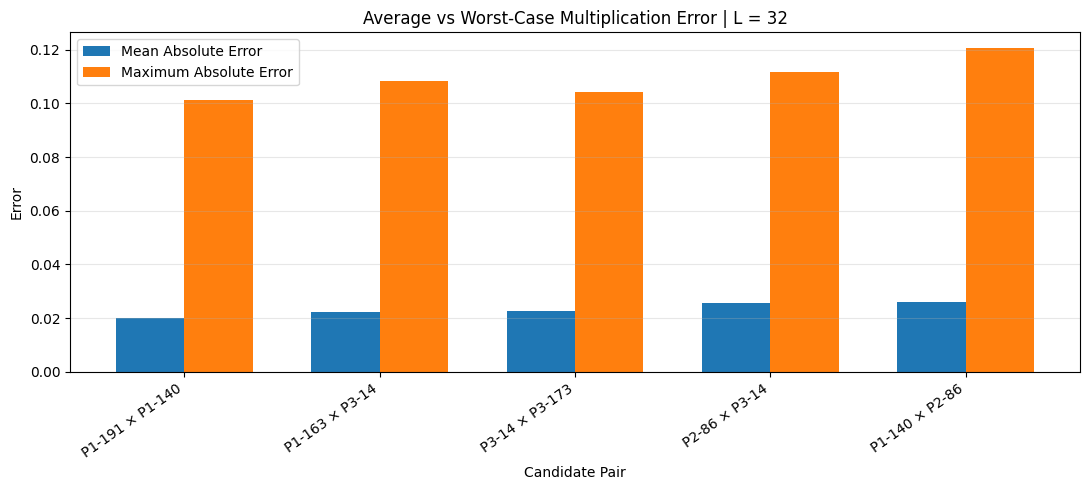

In [304]:
# ============================================================
# MAE VS WORST-CASE ERROR
# ============================================================

for L in STREAM_LENGTHS:

    subset = (
        full_space_results_df[
            full_space_results_df["Stream_Length"] == L
        ]
        .sort_values("Multiplication_MAE")
        .reset_index(drop=True)
    )

    positions = np.arange(len(subset))
    width = 0.35

    plt.figure(figsize=(11, 5))

    plt.bar(
        positions - width / 2,
        subset["Multiplication_MAE"],
        width,
        label="Mean Absolute Error"
    )

    plt.bar(
        positions + width / 2,
        subset["Maximum_Absolute_Multiplication_Error"],
        width,
        label="Maximum Absolute Error"
    )

    plt.xticks(
        positions,
        subset["Pair"],
        rotation=35,
        ha="right"
    )

    plt.xlabel("Candidate Pair")
    plt.ylabel("Error")

    plt.title(
        f"Average vs Worst-Case Multiplication Error | L = {L}"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

## Selecting the Best Multiplier Pair

The final ranking is based primarily on the actual multiplication error rather than dependence alone.

The primary selection metric is:

$$
\boxed{
MAE_{\text{mult}}
=
\operatorname{mean}
\left(
|P(A\land B)-xy|
\right)
}
$$

This directly measures the average difference between the stochastic multiplier output and the ideal numerical multiplication result across the complete 8-bit input space.

Secondary metrics include:

- Multiplication RMSE.
- Maximum Absolute Multiplication Error.
- Multiplication Bias.

The dependence metrics are retained to explain the behavior of the multiplier pair.

Therefore, the final analysis distinguishes between:

$$
\boxed{
\text{Which pair performs best?}
}
$$

and:

$$
\boxed{
\text{Why does that pair perform well?}
}
$$

The first question is answered primarily using multiplication accuracy.

The second question is investigated using representation and dependence metrics.

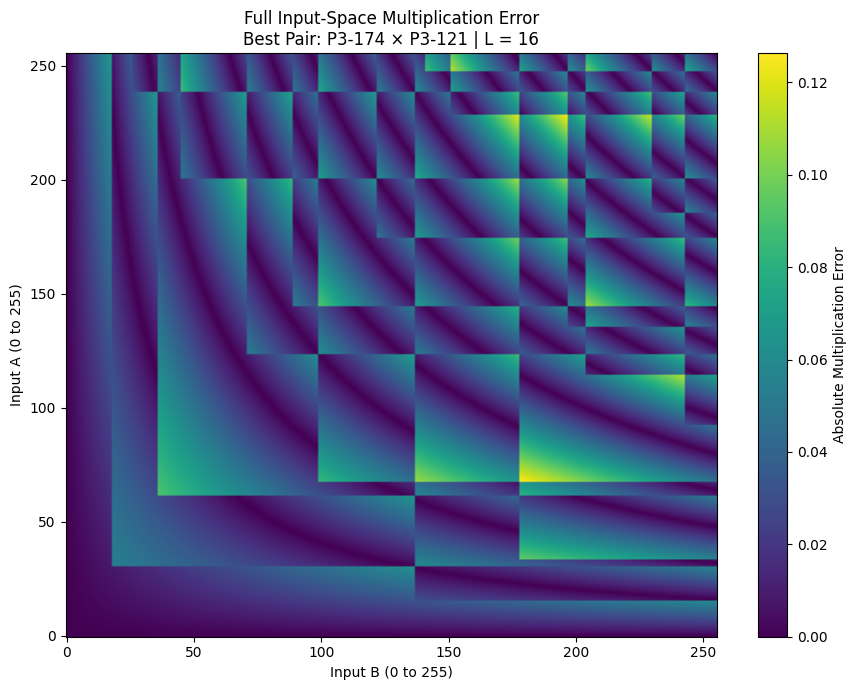

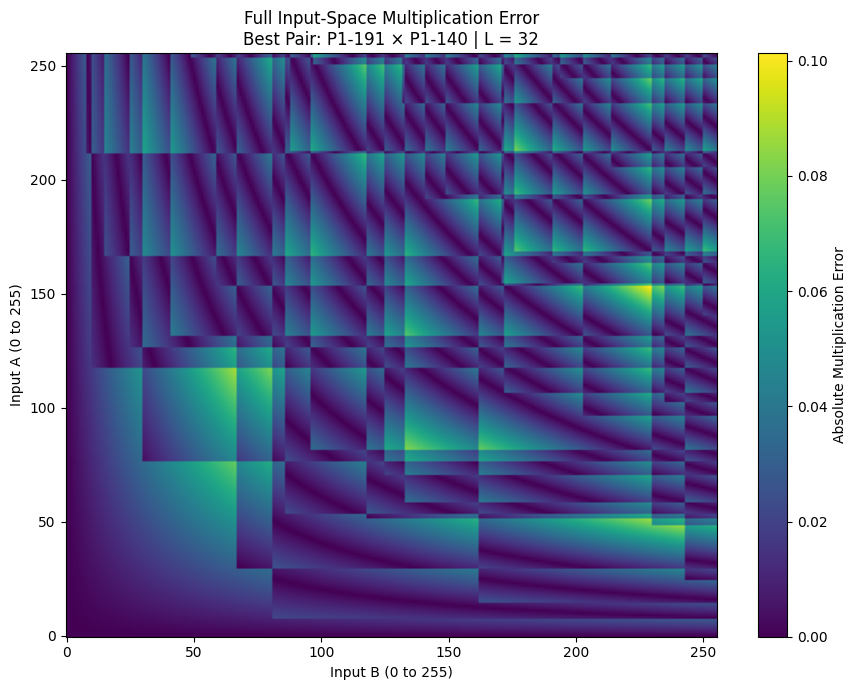

In [305]:
# ============================================================
# FIND AND VISUALIZE THE BEST PAIR
# ============================================================

best_pairs = {}

for L in STREAM_LENGTHS:

    best_row = (
        full_space_results_df[
            full_space_results_df["Stream_Length"] == L
        ]
        .sort_values("Multiplication_MAE")
        .iloc[0]
    )

    best_pairs[L] = best_row

    pair_name = best_row["Pair"]

    details = full_space_details[
        (L, pair_name)
    ]

    error_matrix = np.abs(
        details["multiplication_error"]
    )

    plt.figure(figsize=(9, 7))

    plt.imshow(
        error_matrix,
        origin="lower",
        aspect="auto"
    )

    plt.colorbar(
        label="Absolute Multiplication Error"
    )

    plt.xlabel("Input B (0 to 255)")
    plt.ylabel("Input A (0 to 255)")

    plt.title(
        f"Full Input-Space Multiplication Error\n"
        f"Best Pair: {pair_name} | L = {L}"
    )

    plt.tight_layout()

    plt.show()

In [306]:
# ============================================================
# FINAL WINNERS
# ============================================================

final_summary = []

for L in STREAM_LENGTHS:

    winner = best_pairs[L]

    final_summary.append({

        "Stream_Length": L,

        "Best_Pair": winner["Pair"],

        "Multiplication_MAE":
            winner["Multiplication_MAE"],

        "Multiplication_RMSE":
            winner["Multiplication_RMSE"],

        "Maximum_Error":
            winner[
                "Maximum_Absolute_Multiplication_Error"
            ],

        "Bias":
            winner["Multiplication_Bias"],

        "Dependence_Error":
            winner[
                "Mean_Absolute_Dependence_Error"
            ]
    })

final_summary_df = pd.DataFrame(
    final_summary
)

print("=" * 90)
print("FINAL STOCHASTIC MULTIPLIER CANDIDATES")
print("=" * 90)

display(final_summary_df)

FINAL STOCHASTIC MULTIPLIER CANDIDATES


,Stream_Length,Best_Pair,Multiplication_MAE,Multiplication_RMSE,Maximum_Error,Bias,Dependence_Error
0,16,P3-174 × P3-121,0.027448,0.034734,0.126356,0.000868,0.020523
1,32,P1-191 × P1-140,0.020190,0.025683,0.101324,-0.005108,0.015733


# Global Exhaustive Search Across All Candidate SNG Pairs

The previous experiment evaluated only the top candidate pairs selected from the representative dependence screening.

That experiment demonstrated an important result:

$$
\text{Lowest Dependence Error}
\neq
\text{Lowest Multiplication Error}
$$

Therefore, selecting only a small number of pairs based on dependence metrics may exclude configurations that provide better overall multiplication accuracy.

To remove this limitation, the final stage performs an exhaustive evaluation across all unique candidate SNG pairs.

For each stream length:

$$
L\in\{16,32\}
$$

there are nine selected candidate SNG configurations.

The number of unique non-self pairs is therefore:

$$
\binom{9}{2}=36
$$

Each pair is evaluated over the complete unsigned 8-bit input space:

$$
X,Y\in\{0,1,\dots,255\}
$$

giving:

$$
256\times256=65,536
$$

input combinations per pair.

Therefore, for each stream length:

$$
36\times65,536
=
2,359,296
$$

input combinations are evaluated.

Across both stream lengths, the experiment performs:

$$
\boxed{
4,718,592
}
$$

input-pair evaluations.

The purpose of this experiment is to identify the globally best-performing Stream-A and Stream-B configuration among all selected candidate SNG pairs.

The final ranking will be based primarily on actual stochastic multiplication accuracy rather than dependence alone.

In [307]:
# ============================================================
# VERIFY THE COMPLETE CANDIDATE POOL
# ============================================================

all_candidates_by_length = {}

for L in STREAM_LENGTHS:

    candidates_L = (
        candidate_df[
            candidate_df["Stream_Length"] == L
        ]
        .copy()
        .reset_index(drop=True)
    )

    all_candidates_by_length[L] = candidates_L

    print("\n" + "=" * 80)
    print(f"CANDIDATE CONFIGURATIONS | L = {L}")
    print("=" * 80)

    print(f"\nNumber of candidates: {len(candidates_L)}")

    display(
        candidates_L[
            [
                "Architecture",
                "Seed"
            ]
        ]
    )


CANDIDATE CONFIGURATIONS | L = 16

Number of candidates: 9


,Architecture,Seed
0,P1,47
1,P1,23
2,P1,95
3,P2,161
4,P2,229
5,P2,136
6,P3,215
7,P3,174
8,P3,121



CANDIDATE CONFIGURATIONS | L = 32

Number of candidates: 9


,Architecture,Seed
0,P1,191
1,P1,163
2,P1,140
3,P2,172
4,P2,198
5,P2,86
6,P3,14
7,P3,173
8,P3,90


In [308]:
# ============================================================
# PRECOMPUTE ALL INPUT STREAMS FOR EVERY CANDIDATE
# ============================================================

candidate_stream_cache = {}

for L in STREAM_LENGTHS:

    print("\n" + "=" * 80)
    print(f"PRECOMPUTING STREAMS | L = {L}")
    print("=" * 80)

    candidates_L = all_candidates_by_length[L]

    for _, row in candidates_L.iterrows():

        architecture = row["Architecture"]
        seed = int(row["Seed"])

        cache_key = (
            L,
            architecture,
            seed
        )

        states, streams = precompute_candidate_streams(
            architecture=architecture,
            seed=seed,
            stream_length=L
        )

        candidate_stream_cache[cache_key] = {
            "states": states,
            "streams": streams,
            "probabilities": streams.mean(axis=1)
        }

        print(
            f"Cached: {architecture}, "
            f"Seed={seed}, L={L}"
        )

print("\nAll candidate streams successfully cached.")


PRECOMPUTING STREAMS | L = 16
Cached: P1, Seed=47, L=16
Cached: P1, Seed=23, L=16
Cached: P1, Seed=95, L=16
Cached: P2, Seed=161, L=16
Cached: P2, Seed=229, L=16
Cached: P2, Seed=136, L=16
Cached: P3, Seed=215, L=16
Cached: P3, Seed=174, L=16
Cached: P3, Seed=121, L=16

PRECOMPUTING STREAMS | L = 32
Cached: P1, Seed=191, L=32
Cached: P1, Seed=163, L=32
Cached: P1, Seed=140, L=32
Cached: P2, Seed=172, L=32
Cached: P2, Seed=198, L=32
Cached: P2, Seed=86, L=32
Cached: P3, Seed=14, L=32
Cached: P3, Seed=173, L=32
Cached: P3, Seed=90, L=32

All candidate streams successfully cached.


## Efficient Exhaustive Evaluation

The stochastic streams are deterministic once the following parameters are fixed:

- LFSR polynomial.
- Initial seed.
- Stream length.
- Input value.

Therefore, the experiment does not regenerate the LFSR sequence for every multiplication.

Instead, each candidate configuration generates its LFSR sequence once.

For every candidate, all 256 possible input streams are then precomputed and stored.

The exhaustive search subsequently combines the precomputed streams to evaluate every unique candidate pair.

This significantly reduces computational overhead while preserving the complete:

$$
256\times256
$$

input-space evaluation.

In [309]:
# ============================================================
# EVALUATE ONE PAIR USING PRECOMPUTED STREAMS
# ============================================================

def evaluate_cached_pair(
    streams_a,
    p_a,
    streams_b,
    p_b
):
    """
    Evaluate one candidate SNG pair across the complete
    256 x 256 unsigned input space.
    """

    # --------------------------------------------------------
    # AND operation for all 256 x 256 combinations
    # --------------------------------------------------------

    p_and = (
        (
            streams_a[:, np.newaxis, :]
            &
            streams_b[np.newaxis, :, :]
        )
        .mean(axis=2)
    )

    # --------------------------------------------------------
    # Product of actual represented probabilities
    # --------------------------------------------------------

    represented_product = (
        p_a[:, np.newaxis]
        *
        p_b[np.newaxis, :]
    )

    # --------------------------------------------------------
    # Ideal multiplication result
    # --------------------------------------------------------

    input_probabilities = np.arange(256) / 255.0

    ideal_product = (
        input_probabilities[:, np.newaxis]
        *
        input_probabilities[np.newaxis, :]
    )

    # --------------------------------------------------------
    # Error decomposition
    # --------------------------------------------------------

    dependence_error = (
        p_and - represented_product
    )

    representation_error = (
        represented_product - ideal_product
    )

    multiplication_error = (
        p_and - ideal_product
    )

    # --------------------------------------------------------
    # Summary metrics
    # --------------------------------------------------------

    metrics = {

        "Mean_Absolute_Dependence_Error":
            np.mean(np.abs(dependence_error)),

        "Maximum_Absolute_Dependence_Error":
            np.max(np.abs(dependence_error)),

        "Mean_Absolute_Representation_Error":
            np.mean(np.abs(representation_error)),

        "Multiplication_MAE":
            np.mean(np.abs(multiplication_error)),

        "Multiplication_RMSE":
            np.sqrt(
                np.mean(
                    multiplication_error ** 2
                )
            ),

        "Maximum_Absolute_Multiplication_Error":
            np.max(
                np.abs(multiplication_error)
            ),

        "Multiplication_Bias":
            np.mean(multiplication_error)
    }

    return metrics

In [310]:
# ============================================================
# GLOBAL EXHAUSTIVE SEARCH
# ============================================================

from itertools import combinations

global_results = []

for L in STREAM_LENGTHS:

    print("\n" + "=" * 100)
    print(
        f"GLOBAL EXHAUSTIVE SEARCH | "
        f"STREAM LENGTH = {L}"
    )
    print("=" * 100)

    candidates_L = all_candidates_by_length[L]

    candidate_list = []

    for _, row in candidates_L.iterrows():

        candidate_list.append({
            "Architecture": row["Architecture"],
            "Seed": int(row["Seed"])
        })

    all_pairs = list(
        combinations(candidate_list, 2)
    )

    print(
        f"\nCandidates: {len(candidate_list)}"
    )

    print(
        f"Unique non-self pairs: {len(all_pairs)}"
    )

    print("\nStarting exhaustive evaluation...\n")

    # --------------------------------------------------------
    # Evaluate all unique pairs
    # --------------------------------------------------------

    for pair_index, (candidate_a, candidate_b) in enumerate(
        all_pairs,
        start=1
    ):

        architecture_a = candidate_a["Architecture"]
        seed_a = candidate_a["Seed"]

        architecture_b = candidate_b["Architecture"]
        seed_b = candidate_b["Seed"]

        print(
            f"[{pair_index:02d}/{len(all_pairs)}] "
            f"{architecture_a}-{seed_a} "
            f"× "
            f"{architecture_b}-{seed_b}"
        )

        # ----------------------------------------------------
        # Retrieve cached streams
        # ----------------------------------------------------

        cache_a = candidate_stream_cache[
            (
                L,
                architecture_a,
                seed_a
            )
        ]

        cache_b = candidate_stream_cache[
            (
                L,
                architecture_b,
                seed_b
            )
        ]

        # ----------------------------------------------------
        # Evaluate pair
        # ----------------------------------------------------

        metrics = evaluate_cached_pair(
            streams_a=cache_a["streams"],
            p_a=cache_a["probabilities"],

            streams_b=cache_b["streams"],
            p_b=cache_b["probabilities"]
        )

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        global_results.append({

            "Stream_Length": L,

            "Architecture_A": architecture_a,
            "Seed_A": seed_a,

            "Architecture_B": architecture_b,
            "Seed_B": seed_b,

            "Pair":
                f"{architecture_a}-{seed_a} × "
                f"{architecture_b}-{seed_b}",

            **metrics
        })


print("\n" + "=" * 100)
print("GLOBAL EXHAUSTIVE SEARCH COMPLETED SUCCESSFULLY")
print("=" * 100)


GLOBAL EXHAUSTIVE SEARCH | STREAM LENGTH = 16

Candidates: 9
Unique non-self pairs: 36

Starting exhaustive evaluation...

[01/36] P1-47 × P1-23
[02/36] P1-47 × P1-95
[03/36] P1-47 × P2-161
[04/36] P1-47 × P2-229
[05/36] P1-47 × P2-136
[06/36] P1-47 × P3-215
[07/36] P1-47 × P3-174
[08/36] P1-47 × P3-121
[09/36] P1-23 × P1-95
[10/36] P1-23 × P2-161
[11/36] P1-23 × P2-229
[12/36] P1-23 × P2-136
[13/36] P1-23 × P3-215
[14/36] P1-23 × P3-174
[15/36] P1-23 × P3-121
[16/36] P1-95 × P2-161
[17/36] P1-95 × P2-229
[18/36] P1-95 × P2-136
[19/36] P1-95 × P3-215
[20/36] P1-95 × P3-174
[21/36] P1-95 × P3-121
[22/36] P2-161 × P2-229
[23/36] P2-161 × P2-136
[24/36] P2-161 × P3-215
[25/36] P2-161 × P3-174
[26/36] P2-161 × P3-121
[27/36] P2-229 × P2-136
[28/36] P2-229 × P3-215
[29/36] P2-229 × P3-174
[30/36] P2-229 × P3-121
[31/36] P2-136 × P3-215
[32/36] P2-136 × P3-174
[33/36] P2-136 × P3-121
[34/36] P3-215 × P3-174
[35/36] P3-215 × P3-121
[36/36] P3-174 × P3-121

GLOBAL EXHAUSTIVE SEARCH | STREAM L

In [311]:
# ============================================================
# CREATE GLOBAL RESULTS DATAFRAME
# ============================================================

global_results_df = pd.DataFrame(
    global_results
)

print(
    f"Total evaluated pairs: "
    f"{len(global_results_df)}"
)

display(
    global_results_df.head()
)

Total evaluated pairs: 72


,Stream_Length,Architecture_A,Seed_A,Architecture_B,Seed_B,Pair,Mean_Absolute_Dependence_Error,Maximum_Absolute_Dependence_Error,Mean_Absolute_Representation_Error,Multiplication_MAE,Multiplication_RMSE,Maximum_Absolute_Multiplication_Error,Multiplication_Bias
0,16,P1,47,P1,23,P1-47 × P1-23,0.038002,0.140625,0.020202,0.049437,0.062541,0.190429,0.037457
1,16,P1,47,P1,95,P1-47 × P1-95,0.052282,0.175781,0.019040,0.060244,0.073855,0.216537,0.055943
2,16,P1,47,P2,161,P1-47 × P2-161,0.041756,0.140625,0.017436,0.048616,0.059486,0.167866,-0.043636
3,16,P1,47,P2,229,P1-47 × P2-229,0.031852,0.125000,0.018805,0.039295,0.048340,0.137781,0.020089
4,16,P1,47,P2,136,P1-47 × P2-136,0.030425,0.136719,0.022415,0.042842,0.054597,0.190140,-0.023457


In [312]:
# ============================================================
# GLOBAL RANKING BY MULTIPLICATION ACCURACY
# ============================================================

global_rankings = {}

for L in STREAM_LENGTHS:

    ranking = (
        global_results_df[
            global_results_df["Stream_Length"] == L
        ]
        .sort_values(
            by=[
                "Multiplication_MAE",
                "Multiplication_RMSE",
                "Maximum_Absolute_Multiplication_Error"
            ]
        )
        .reset_index(drop=True)
    )

    ranking.index = ranking.index + 1

    global_rankings[L] = ranking

    print("\n" + "=" * 100)
    print(
        f"GLOBAL MULTIPLICATION RANKING | "
        f"L = {L}"
    )
    print("=" * 100)

    display(
        ranking[
            [
                "Pair",
                "Multiplication_MAE",
                "Multiplication_RMSE",
                "Maximum_Absolute_Multiplication_Error",
                "Multiplication_Bias",
                "Mean_Absolute_Dependence_Error",
                "Mean_Absolute_Representation_Error"
            ]
        ]
    )


GLOBAL MULTIPLICATION RANKING | L = 16


,Pair,Multiplication_MAE,Multiplication_RMSE,Maximum_Absolute_Multiplication_Error,Multiplication_Bias,Mean_Absolute_Dependence_Error,Mean_Absolute_Representation_Error
1,P3-174 × P3-121,0.027448,0.034734,0.126356,0.000868,0.020523,0.018233
2,P2-161 × P3-121,0.030099,0.038055,0.133555,-0.004637,0.022311,0.017926
3,P1-47 × P3-215,0.030512,0.038222,0.123304,-0.005976,0.023932,0.017482
4,P1-23 × P3-174,0.030976,0.039020,0.159193,-0.011065,0.022246,0.018697
5,P1-95 × P3-174,0.031464,0.040135,0.150670,-0.008350,0.027881,0.020214
6,P1-23 × P2-229,0.031594,0.040261,0.158953,-0.014522,0.020663,0.019903
7,P2-161 × P3-174,0.032777,0.041250,0.148220,-0.010710,0.030419,0.020492
8,P2-161 × P3-215,0.032902,0.042420,0.182728,-0.014739,0.025013,0.018966
9,P1-47 × P3-121,0.033009,0.040775,0.130606,0.008313,0.026322,0.021236
10,P1-47 × P3-174,0.033596,0.042979,0.163268,0.001362,0.027376,0.017602



GLOBAL MULTIPLICATION RANKING | L = 32


,Pair,Multiplication_MAE,Multiplication_RMSE,Maximum_Absolute_Multiplication_Error,Multiplication_Bias,Mean_Absolute_Dependence_Error,Mean_Absolute_Representation_Error
1,P2-198 × P2-86,0.018916,0.024183,0.097141,-0.001496,0.023437,0.019607
2,P1-191 × P1-163,0.019866,0.026122,0.108151,-0.002709,0.016846,0.012619
3,P1-191 × P1-140,0.020190,0.025683,0.101324,-0.005108,0.015733,0.012156
4,P1-191 × P2-172,0.020215,0.025624,0.097623,-0.004765,0.017313,0.010732
5,P2-198 × P3-173,0.020752,0.026903,0.118668,0.008205,0.016859,0.014751
6,P1-163 × P2-198,0.021471,0.027193,0.096405,-0.010383,0.023969,0.015511
7,P1-191 × P3-14,0.021844,0.028967,0.131314,0.010161,0.015184,0.012409
8,P1-163 × P3-14,0.022175,0.028727,0.108524,0.009962,0.015011,0.014665
9,P2-172 × P2-198,0.022329,0.028046,0.098976,-0.006094,0.022763,0.015084
10,P2-198 × P3-90,0.022638,0.028910,0.114337,-0.010912,0.024296,0.014946


In [313]:
# ============================================================
# TOP 10 GLOBAL PAIRS
# ============================================================

for L in STREAM_LENGTHS:

    print("\n" + "=" * 90)
    print(f"TOP 10 PAIRS | GLOBAL SEARCH | L = {L}")
    print("=" * 90)

    display(
        global_rankings[L]
        .head(10)
        [
            [
                "Pair",
                "Multiplication_MAE",
                "Multiplication_RMSE",
                "Maximum_Absolute_Multiplication_Error",
                "Multiplication_Bias",
                "Mean_Absolute_Dependence_Error",
                "Mean_Absolute_Representation_Error"
            ]
        ]
    )


TOP 10 PAIRS | GLOBAL SEARCH | L = 16


,Pair,Multiplication_MAE,Multiplication_RMSE,Maximum_Absolute_Multiplication_Error,Multiplication_Bias,Mean_Absolute_Dependence_Error,Mean_Absolute_Representation_Error
1,P3-174 × P3-121,0.027448,0.034734,0.126356,0.000868,0.020523,0.018233
2,P2-161 × P3-121,0.030099,0.038055,0.133555,-0.004637,0.022311,0.017926
3,P1-47 × P3-215,0.030512,0.038222,0.123304,-0.005976,0.023932,0.017482
4,P1-23 × P3-174,0.030976,0.039020,0.159193,-0.011065,0.022246,0.018697
5,P1-95 × P3-174,0.031464,0.040135,0.150670,-0.008350,0.027881,0.020214
6,P1-23 × P2-229,0.031594,0.040261,0.158953,-0.014522,0.020663,0.019903
7,P2-161 × P3-174,0.032777,0.041250,0.148220,-0.010710,0.030419,0.020492
8,P2-161 × P3-215,0.032902,0.042420,0.182728,-0.014739,0.025013,0.018966
9,P1-47 × P3-121,0.033009,0.040775,0.130606,0.008313,0.026322,0.021236
10,P1-47 × P3-174,0.033596,0.042979,0.163268,0.001362,0.027376,0.017602



TOP 10 PAIRS | GLOBAL SEARCH | L = 32


,Pair,Multiplication_MAE,Multiplication_RMSE,Maximum_Absolute_Multiplication_Error,Multiplication_Bias,Mean_Absolute_Dependence_Error,Mean_Absolute_Representation_Error
1,P2-198 × P2-86,0.018916,0.024183,0.097141,-0.001496,0.023437,0.019607
2,P1-191 × P1-163,0.019866,0.026122,0.108151,-0.002709,0.016846,0.012619
3,P1-191 × P1-140,0.020190,0.025683,0.101324,-0.005108,0.015733,0.012156
4,P1-191 × P2-172,0.020215,0.025624,0.097623,-0.004765,0.017313,0.010732
5,P2-198 × P3-173,0.020752,0.026903,0.118668,0.008205,0.016859,0.014751
6,P1-163 × P2-198,0.021471,0.027193,0.096405,-0.010383,0.023969,0.015511
7,P1-191 × P3-14,0.021844,0.028967,0.131314,0.010161,0.015184,0.012409
8,P1-163 × P3-14,0.022175,0.028727,0.108524,0.009962,0.015011,0.014665
9,P2-172 × P2-198,0.022329,0.028046,0.098976,-0.006094,0.022763,0.015084
10,P2-198 × P3-90,0.022638,0.028910,0.114337,-0.010912,0.024296,0.014946


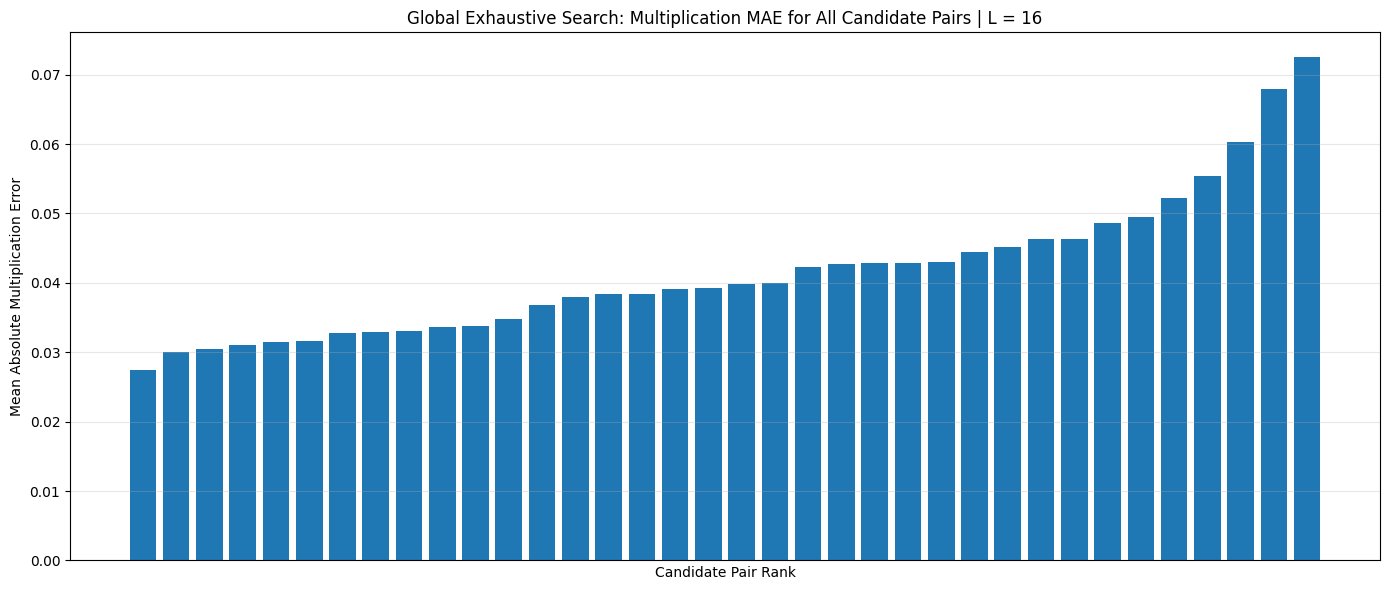

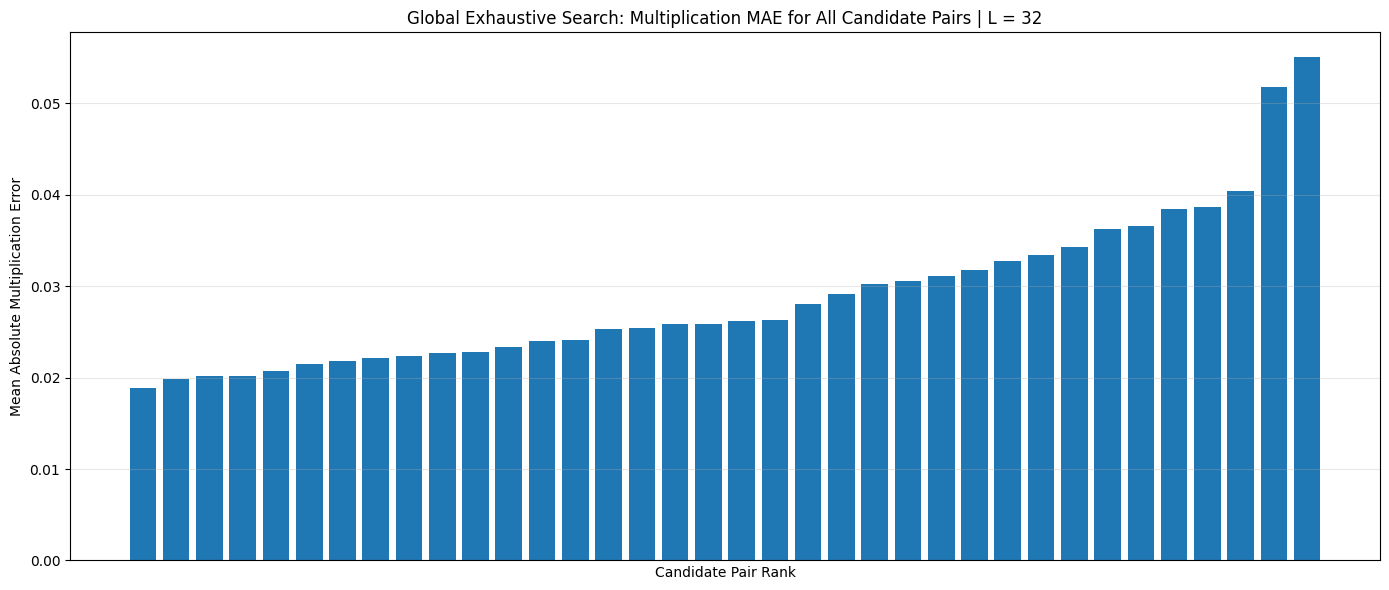

In [314]:
# ============================================================
# GLOBAL MULTIPLICATION MAE COMPARISON
# ============================================================

for L in STREAM_LENGTHS:

    subset = (
        global_rankings[L]
        .copy()
        .reset_index(drop=True)
    )

    plt.figure(figsize=(14, 6))

    plt.bar(
        range(len(subset)),
        subset["Multiplication_MAE"]
    )

    plt.xlabel("Candidate Pair Rank")
    plt.ylabel("Mean Absolute Multiplication Error")

    plt.title(
        f"Global Exhaustive Search: "
        f"Multiplication MAE for All Candidate Pairs | L = {L}"
    )

    plt.xticks([])

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [315]:
# ============================================================
# FINAL GLOBAL WINNERS
# ============================================================

final_global_winners = []

for L in STREAM_LENGTHS:

    winner = global_rankings[L].iloc[0]

    final_global_winners.append({

        "Stream_Length": L,

        "Best_Pair": winner["Pair"],

        "Multiplication_MAE":
            winner["Multiplication_MAE"],

        "Multiplication_RMSE":
            winner["Multiplication_RMSE"],

        "Maximum_Error":
            winner[
                "Maximum_Absolute_Multiplication_Error"
            ],

        "Bias":
            winner["Multiplication_Bias"],

        "Dependence_Error":
            winner[
                "Mean_Absolute_Dependence_Error"
            ],

        "Representation_Error":
            winner[
                "Mean_Absolute_Representation_Error"
            ]
    })


final_global_winners_df = pd.DataFrame(
    final_global_winners
)

print("\n" + "=" * 100)
print("🏆 FINAL GLOBAL STOCHASTIC MULTIPLIER WINNERS")
print("=" * 100)

display(final_global_winners_df)


🏆 FINAL GLOBAL STOCHASTIC MULTIPLIER WINNERS


,Stream_Length,Best_Pair,Multiplication_MAE,Multiplication_RMSE,Maximum_Error,Bias,Dependence_Error,Representation_Error
0,16,P3-174 × P3-121,0.027448,0.034734,0.126356,0.000868,0.020523,0.018233
1,32,P2-198 × P2-86,0.018916,0.024183,0.097141,-0.001496,0.023437,0.019607


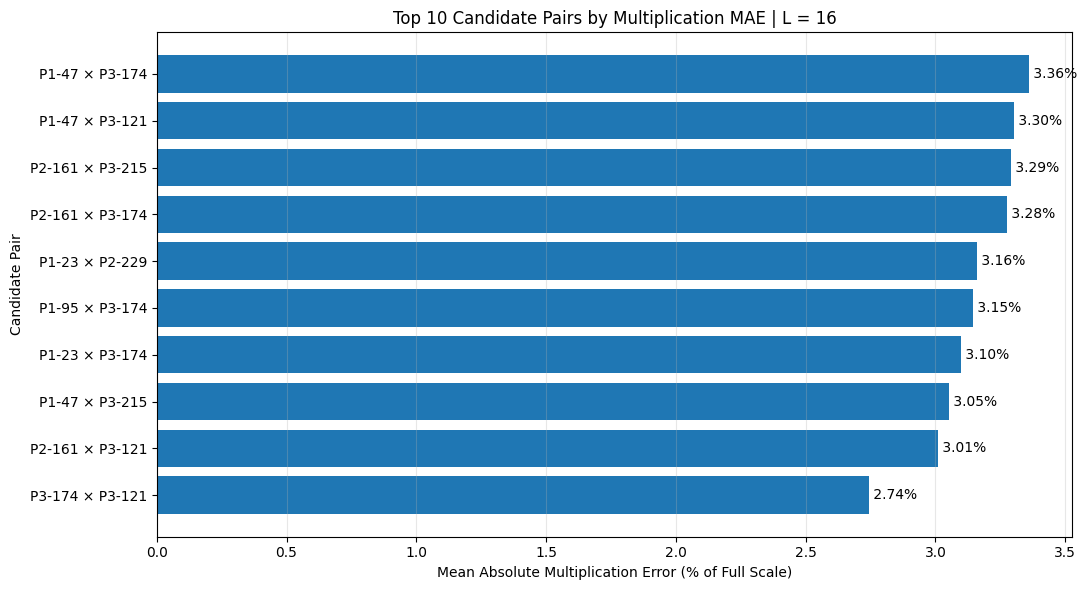

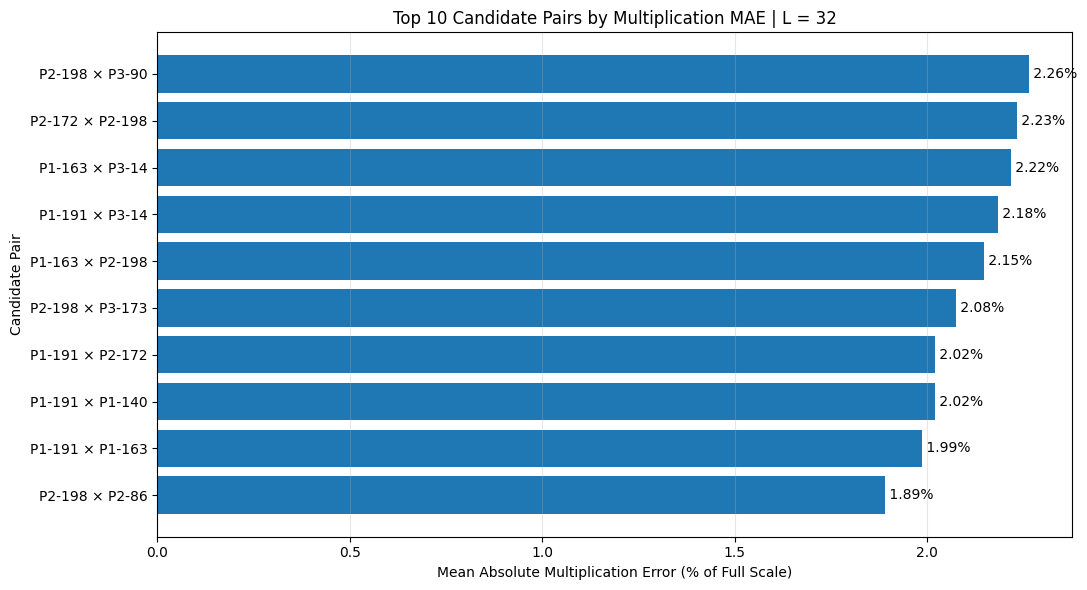

In [316]:
# ============================================================
# TOP 10 PAIRS — MULTIPLICATION MAE (%)
# ============================================================

for L in STREAM_LENGTHS:

    subset = (
        global_rankings[L]
        .head(10)
        .copy()
        .sort_values("Multiplication_MAE")
    )

    subset["MAE_Percentage"] = (
        subset["Multiplication_MAE"] * 100
    )

    plt.figure(figsize=(11, 6))

    bars = plt.barh(
        subset["Pair"],
        subset["MAE_Percentage"]
    )

    plt.xlabel(
        "Mean Absolute Multiplication Error (% of Full Scale)"
    )

    plt.ylabel("Candidate Pair")

    plt.title(
        f"Top 10 Candidate Pairs by Multiplication MAE | L = {L}"
    )

    plt.grid(
        axis="x",
        alpha=0.3
    )

    # Add values to bars
    for bar, value in zip(
        bars,
        subset["MAE_Percentage"]
    ):

        plt.text(
            value,
            bar.get_y() + bar.get_height() / 2,
            f" {value:.2f}%",
            va="center"
        )

    plt.tight_layout()

    plt.show()

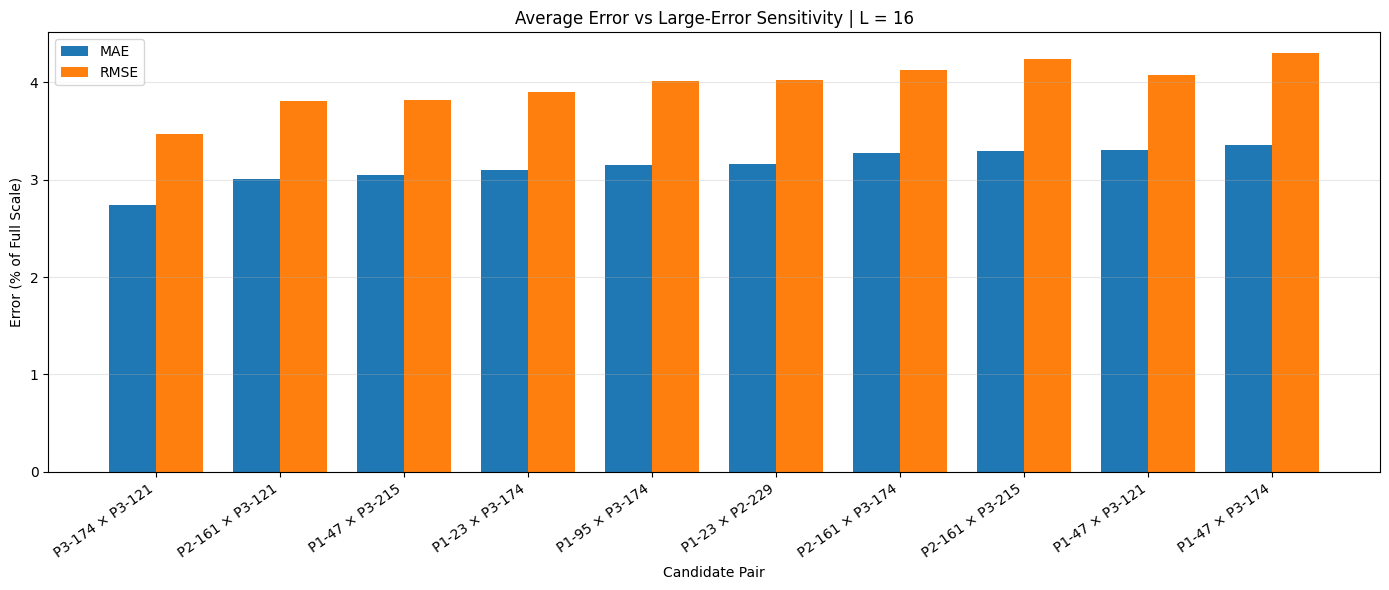

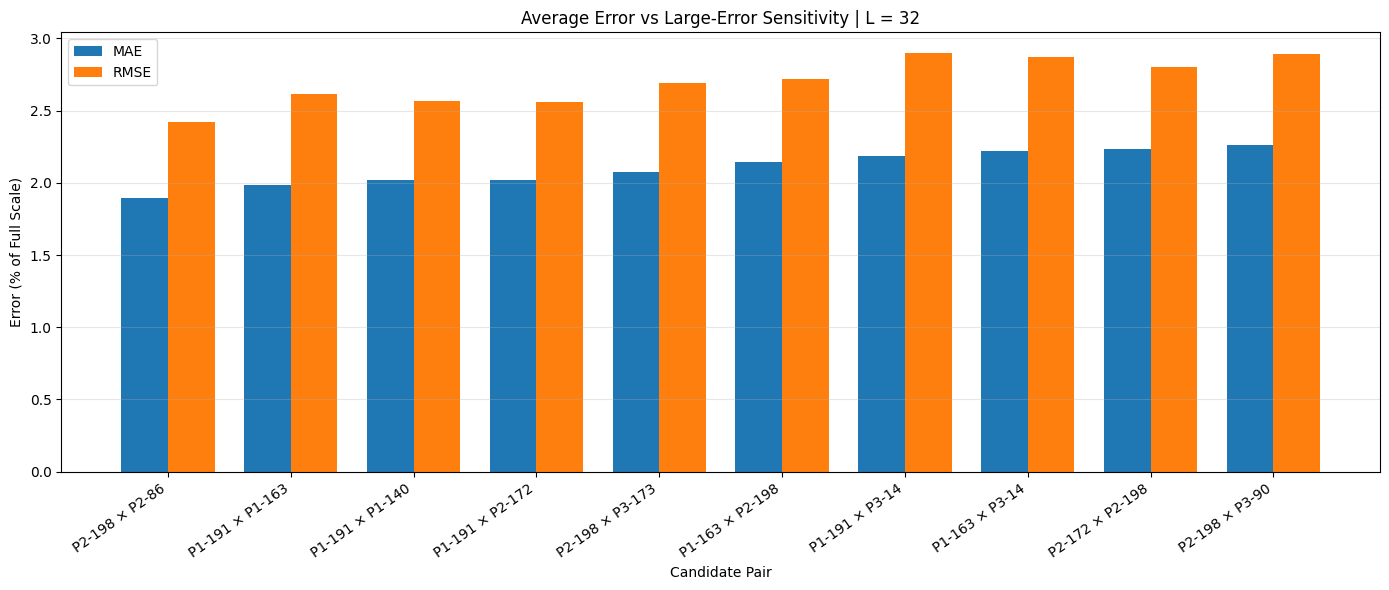

In [317]:
# ============================================================
# MAE VS RMSE — TOP 10 PAIRS
# ============================================================

for L in STREAM_LENGTHS:

    subset = (
        global_rankings[L]
        .head(10)
        .copy()
    )

    positions = np.arange(len(subset))
    width = 0.38

    mae_percent = (
        subset["Multiplication_MAE"] * 100
    )

    rmse_percent = (
        subset["Multiplication_RMSE"] * 100
    )

    plt.figure(figsize=(14, 6))

    plt.bar(
        positions - width / 2,
        mae_percent,
        width,
        label="MAE"
    )

    plt.bar(
        positions + width / 2,
        rmse_percent,
        width,
        label="RMSE"
    )

    plt.xticks(
        positions,
        subset["Pair"],
        rotation=35,
        ha="right"
    )

    plt.ylabel("Error (% of Full Scale)")

    plt.xlabel("Candidate Pair")

    plt.title(
        f"Average Error vs Large-Error Sensitivity | L = {L}"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

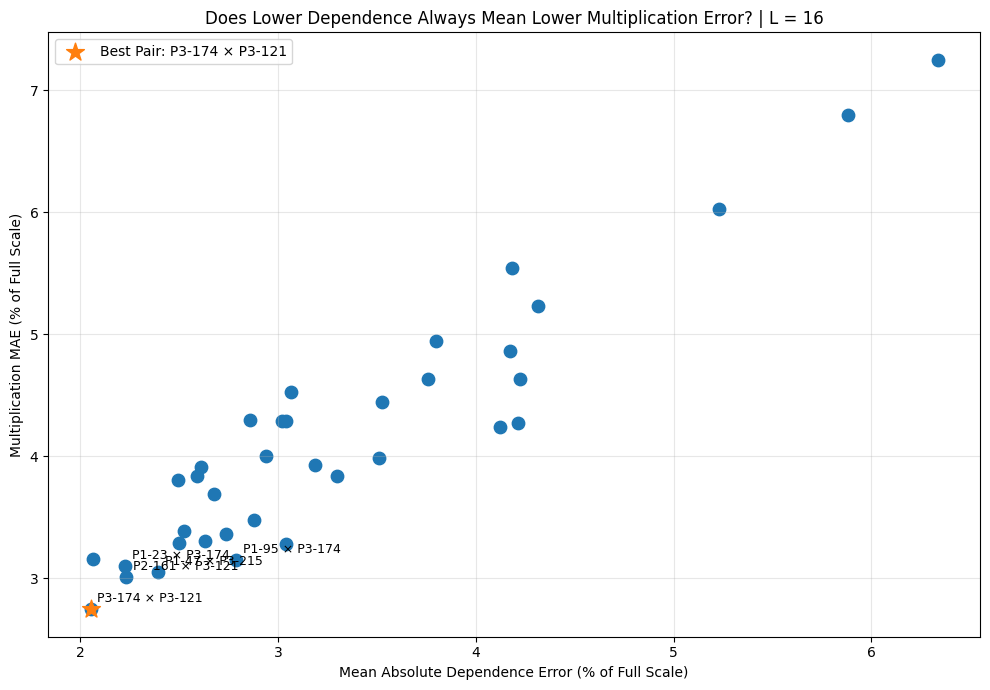

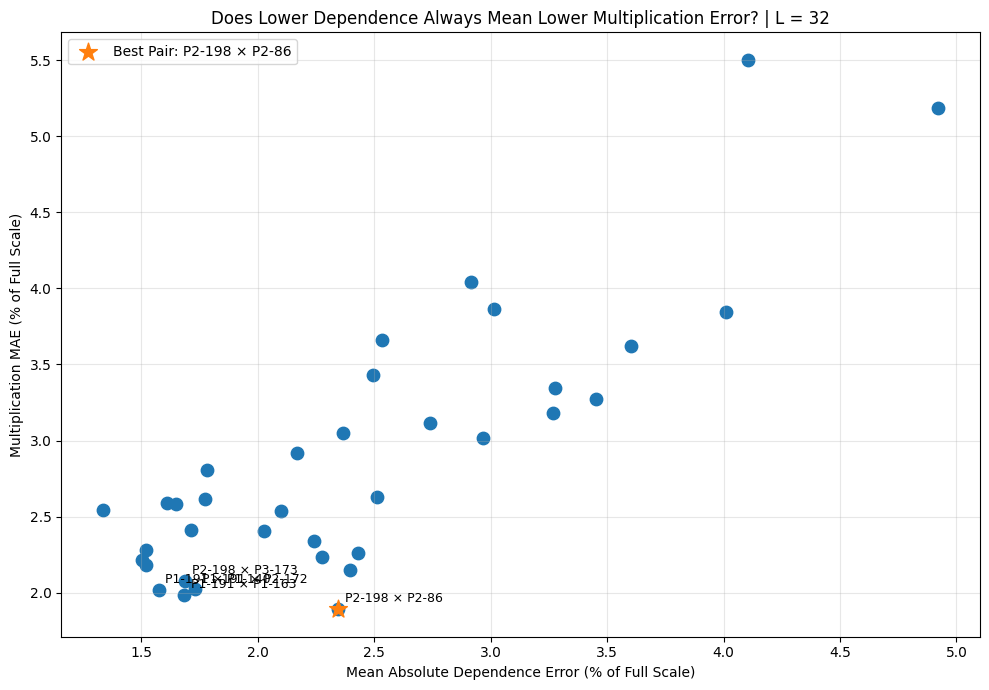

In [318]:
# ============================================================
# MULTIPLICATION MAE VS DEPENDENCE ERROR
# ============================================================

for L in STREAM_LENGTHS:

    subset = global_rankings[L].copy()

    dependence_percent = (
        subset["Mean_Absolute_Dependence_Error"] * 100
    )

    mae_percent = (
        subset["Multiplication_MAE"] * 100
    )

    plt.figure(figsize=(10, 7))

    plt.scatter(
        dependence_percent,
        mae_percent,
        s=80
    )

    # Highlight the best pair
    best = subset.iloc[0]

    best_x = (
        best["Mean_Absolute_Dependence_Error"] * 100
    )

    best_y = (
        best["Multiplication_MAE"] * 100
    )

    plt.scatter(
        best_x,
        best_y,
        s=180,
        marker="*",
        label=f"Best Pair: {best['Pair']}"
    )

    # Label only the top 5 pairs
    for _, row in subset.head(5).iterrows():

        x = (
            row["Mean_Absolute_Dependence_Error"] * 100
        )

        y = (
            row["Multiplication_MAE"] * 100
        )

        plt.annotate(
            row["Pair"],
            (x, y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

    plt.xlabel(
        "Mean Absolute Dependence Error (% of Full Scale)"
    )

    plt.ylabel(
        "Multiplication MAE (% of Full Scale)"
    )

    plt.title(
        f"Does Lower Dependence Always Mean Lower Multiplication Error? | L = {L}"
    )

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

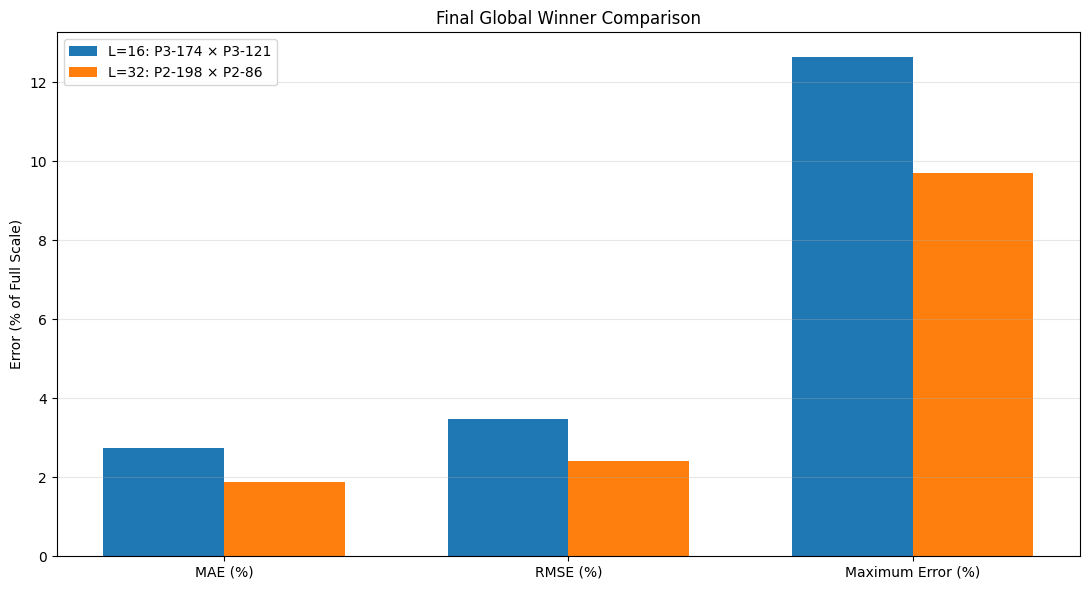

In [319]:
# ============================================================
# FINAL WINNER COMPARISON
# ============================================================

comparison = final_global_winners_df.copy()

comparison["MAE (%)"] = (
    comparison["Multiplication_MAE"] * 100
)

comparison["RMSE (%)"] = (
    comparison["Multiplication_RMSE"] * 100
)

comparison["Maximum Error (%)"] = (
    comparison["Maximum_Error"] * 100
)

metrics = [
    "MAE (%)",
    "RMSE (%)",
    "Maximum Error (%)"
]

positions = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(11, 6))

for i, (_, row) in enumerate(comparison.iterrows()):

    offset = (
        (i - (len(comparison) - 1) / 2) * width
    )

    plt.bar(
        positions + offset,
        row[metrics].values,
        width,
        label=(
            f"L={int(row['Stream_Length'])}: "
            f"{row['Best_Pair']}"
        )
    )

plt.xticks(
    positions,
    metrics
)

plt.ylabel("Error (% of Full Scale)")

plt.title(
    "Final Global Winner Comparison"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

/tmp/ipykernel_2884/1748973601.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


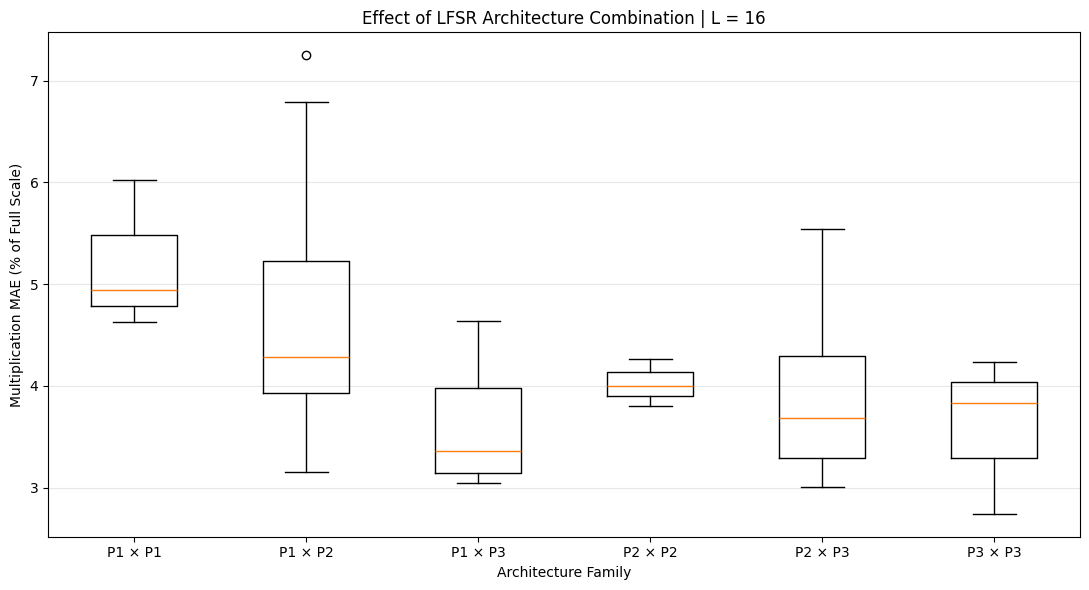

/tmp/ipykernel_2884/1748973601.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


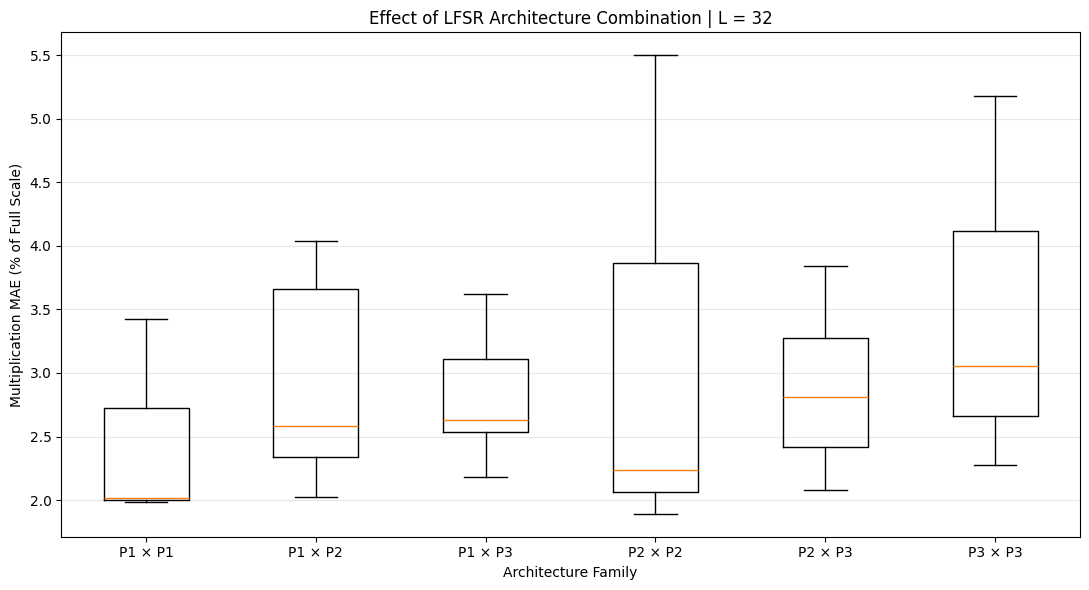

In [320]:
# ============================================================
# ARCHITECTURE FAMILY ANALYSIS
# ============================================================

for L in STREAM_LENGTHS:

    subset = global_rankings[L].copy()

    architecture_family = []

    for _, row in subset.iterrows():

        architectures = sorted([
            row["Architecture_A"],
            row["Architecture_B"]
        ])

        family = (
            f"{architectures[0]} × {architectures[1]}"
        )

        architecture_family.append(family)

    subset["Architecture_Family"] = architecture_family

    families = sorted(
        subset["Architecture_Family"].unique()
    )

    data = []

    for family in families:

        values = (
            subset[
                subset["Architecture_Family"] == family
            ]["Multiplication_MAE"]
            * 100
        )

        data.append(values.values)

    plt.figure(figsize=(11, 6))

    plt.boxplot(
        data,
        labels=families
    )

    plt.xlabel("Architecture Family")

    plt.ylabel(
        "Multiplication MAE (% of Full Scale)"
    )

    plt.title(
        f"Effect of LFSR Architecture Combination | L = {L}"
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

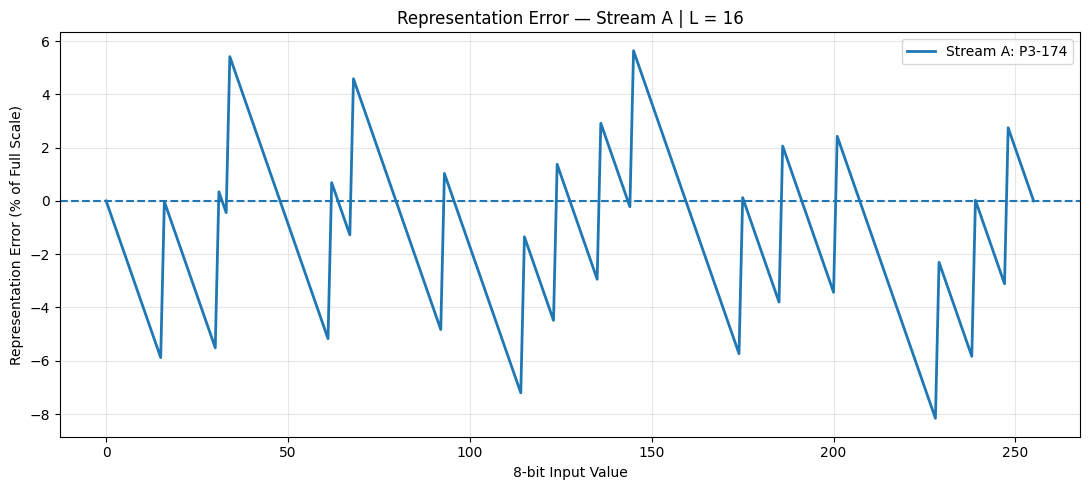

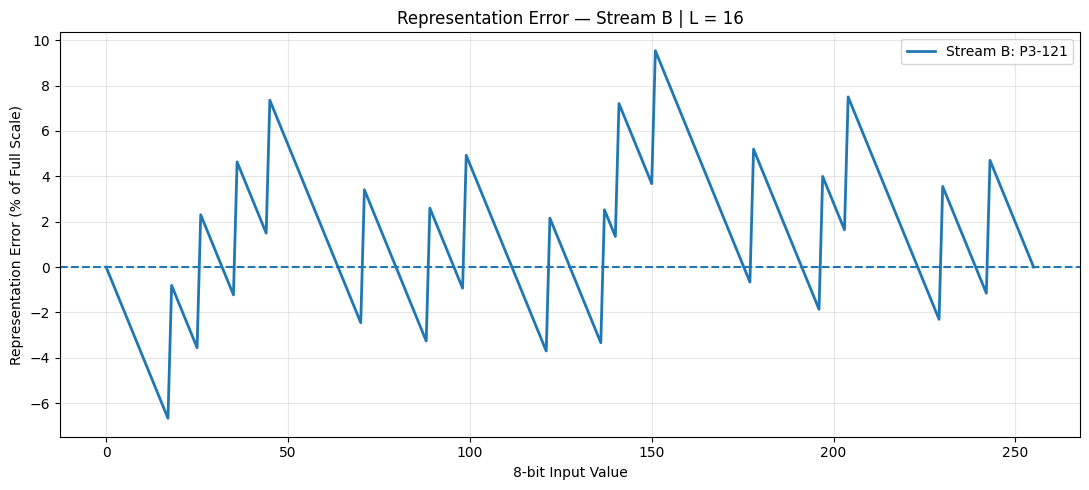

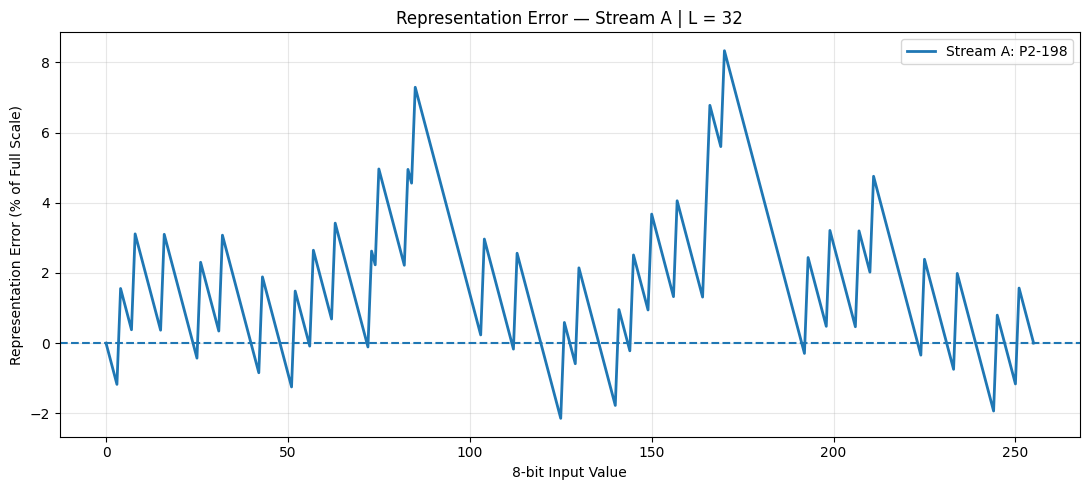

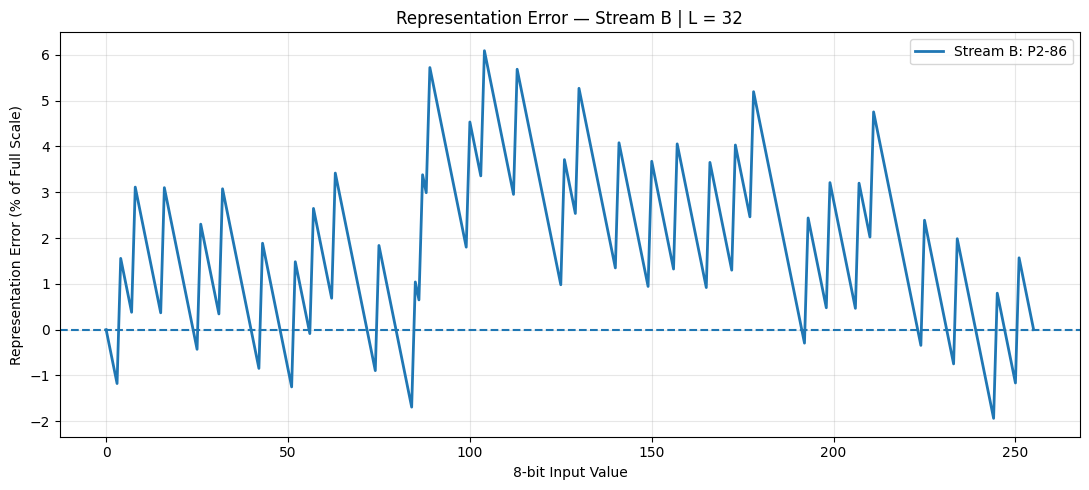

In [321]:
# ============================================================
# REPRESENTATION ERROR OF FINAL WINNING SNGs
# ============================================================

for L in STREAM_LENGTHS:

    winner = final_global_winners_df[
        final_global_winners_df["Stream_Length"] == L
    ].iloc[0]

    best_pair = winner["Best_Pair"]

    # Split pair
    config_a, config_b = best_pair.split(" × ")

    # Extract architecture and seed
    architecture_a, seed_a = config_a.rsplit("-", 1)
    architecture_b, seed_b = config_b.rsplit("-", 1)

    seed_a = int(seed_a)
    seed_b = int(seed_b)

    # Evaluate Stream A
    evaluation_a = evaluate_lfsr_window(
        config_name=architecture_a,
        seed=seed_a,
        stream_length=L
    )

    # Evaluate Stream B
    evaluation_b = evaluate_lfsr_window(
        config_name=architecture_b,
        seed=seed_b,
        stream_length=L
    )

    # --------------------------------------------------------
    # Stream A
    # --------------------------------------------------------

    plt.figure(figsize=(11, 5))

    plt.plot(
        evaluation_a["inputs"],
        evaluation_a["signed_errors"] * 100,
        linewidth=2,
        label=f"Stream A: {config_a}"
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    plt.xlabel("8-bit Input Value")
    plt.ylabel("Representation Error (% of Full Scale)")

    plt.title(
        f"Representation Error — Stream A | L = {L}"
    )

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Stream B
    # --------------------------------------------------------

    plt.figure(figsize=(11, 5))

    plt.plot(
        evaluation_b["inputs"],
        evaluation_b["signed_errors"] * 100,
        linewidth=2,
        label=f"Stream B: {config_b}"
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    plt.xlabel("8-bit Input Value")
    plt.ylabel("Representation Error (% of Full Scale)")

    plt.title(
        f"Representation Error — Stream B | L = {L}"
    )

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

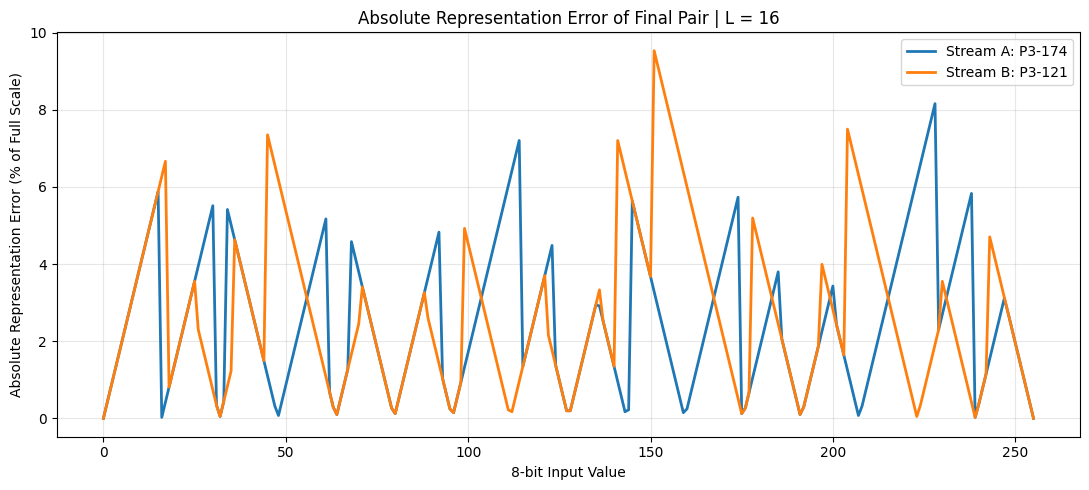

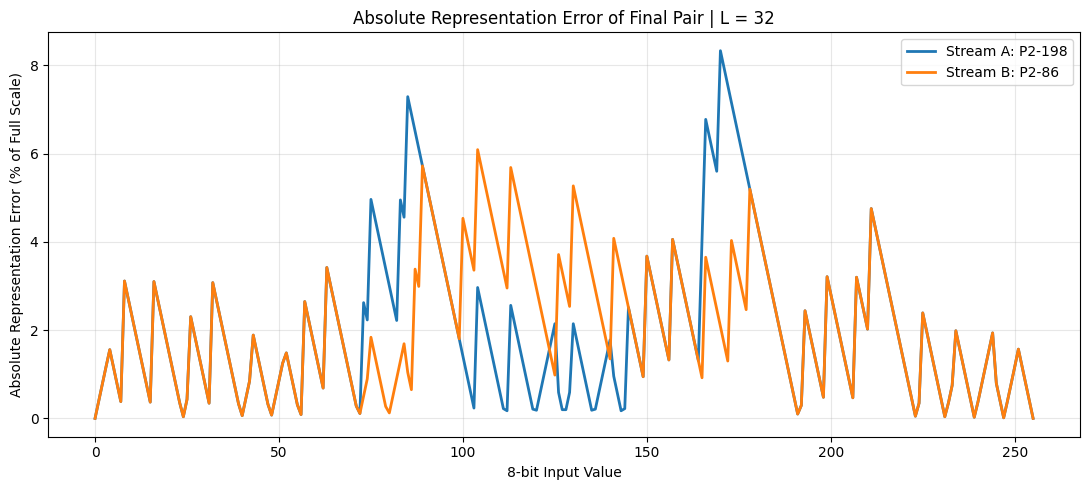

In [322]:
# ============================================================
# ABSOLUTE REPRESENTATION ERROR OF FINAL WINNERS
# ============================================================

for L in STREAM_LENGTHS:

    winner = final_global_winners_df[
        final_global_winners_df["Stream_Length"] == L
    ].iloc[0]

    best_pair = winner["Best_Pair"]

    config_a, config_b = best_pair.split(" × ")

    architecture_a, seed_a = config_a.rsplit("-", 1)
    architecture_b, seed_b = config_b.rsplit("-", 1)

    seed_a = int(seed_a)
    seed_b = int(seed_b)

    evaluation_a = evaluate_lfsr_window(
        config_name=architecture_a,
        seed=seed_a,
        stream_length=L
    )

    evaluation_b = evaluate_lfsr_window(
        config_name=architecture_b,
        seed=seed_b,
        stream_length=L
    )

    plt.figure(figsize=(11, 5))

    plt.plot(
        evaluation_a["inputs"],
        evaluation_a["absolute_errors"] * 100,
        linewidth=2,
        label=f"Stream A: {config_a}"
    )

    plt.plot(
        evaluation_b["inputs"],
        evaluation_b["absolute_errors"] * 100,
        linewidth=2,
        label=f"Stream B: {config_b}"
    )

    plt.xlabel("8-bit Input Value")

    plt.ylabel(
        "Absolute Representation Error (% of Full Scale)"
    )

    plt.title(
        f"Absolute Representation Error of Final Pair | L = {L}"
    )

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

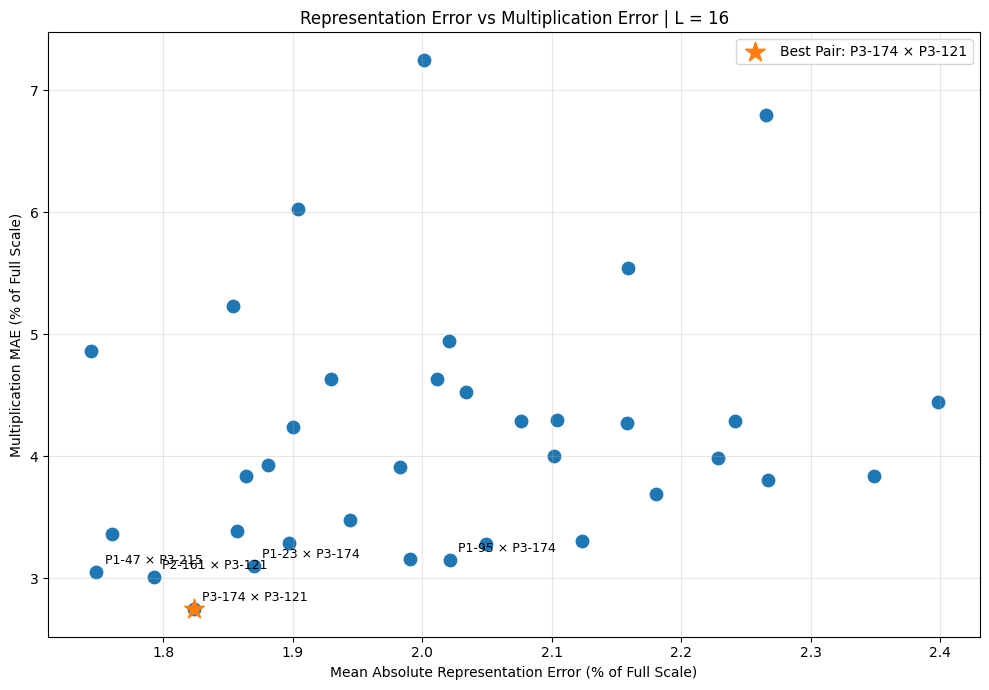

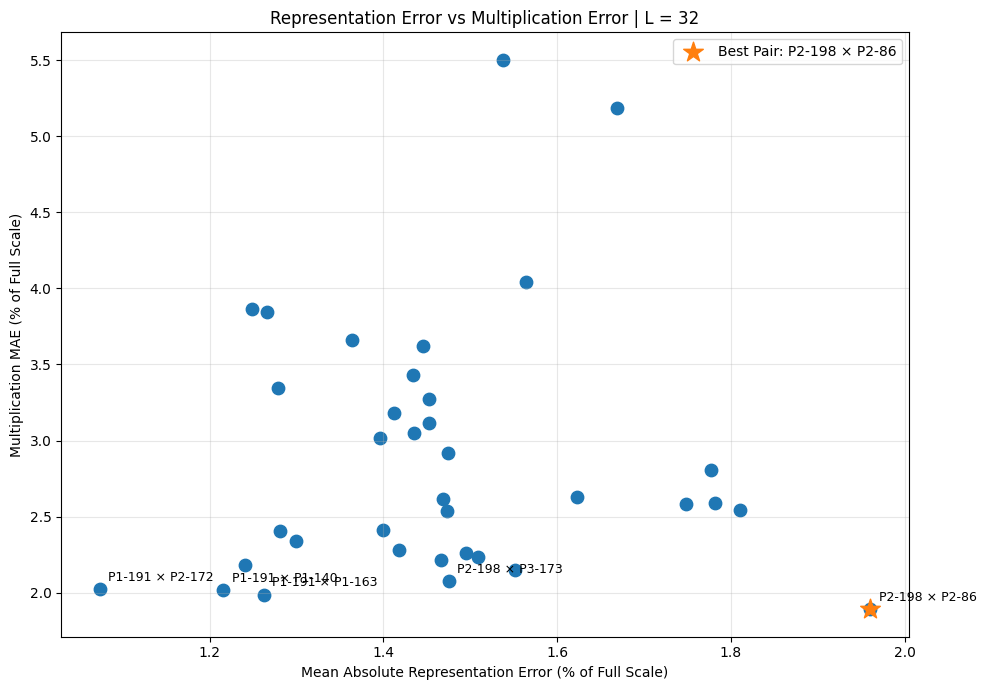

In [323]:
# ============================================================
# REPRESENTATION MAE VS MULTIPLICATION MAE
# ============================================================

for L in STREAM_LENGTHS:

    subset = global_rankings[L].copy()

    # Convert normalized errors to percentages
    representation_mae = (
        subset["Mean_Absolute_Representation_Error"] * 100
    )

    multiplication_mae = (
        subset["Multiplication_MAE"] * 100
    )

    plt.figure(figsize=(10, 7))

    plt.scatter(
        representation_mae,
        multiplication_mae,
        s=80
    )

    # --------------------------------------------------------
    # Highlight best pair
    # --------------------------------------------------------

    best = subset.iloc[0]

    best_x = (
        best["Mean_Absolute_Representation_Error"] * 100
    )

    best_y = (
        best["Multiplication_MAE"] * 100
    )

    plt.scatter(
        best_x,
        best_y,
        s=220,
        marker="*",
        label=f"Best Pair: {best['Pair']}"
    )

    # --------------------------------------------------------
    # Label top 5 pairs
    # --------------------------------------------------------

    for _, row in subset.head(5).iterrows():

        x = (
            row["Mean_Absolute_Representation_Error"] * 100
        )

        y = (
            row["Multiplication_MAE"] * 100
        )

        plt.annotate(
            row["Pair"],
            (x, y),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

    plt.xlabel(
        "Mean Absolute Representation Error (% of Full Scale)"
    )

    plt.ylabel(
        "Multiplication MAE (% of Full Scale)"
    )

    plt.title(
        f"Representation Error vs Multiplication Error | L = {L}"
    )

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

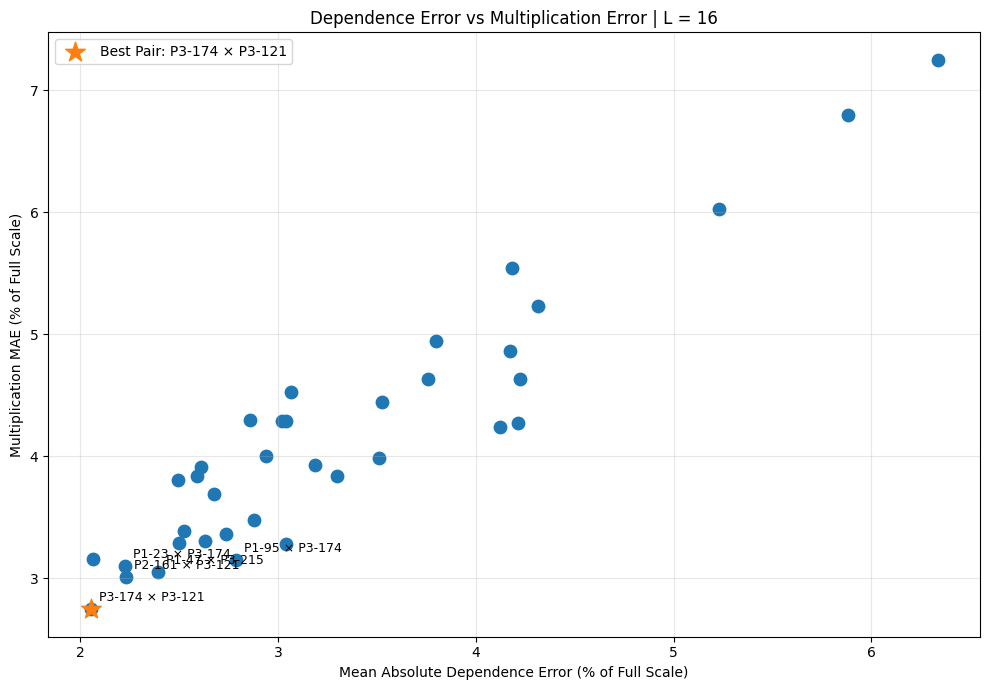

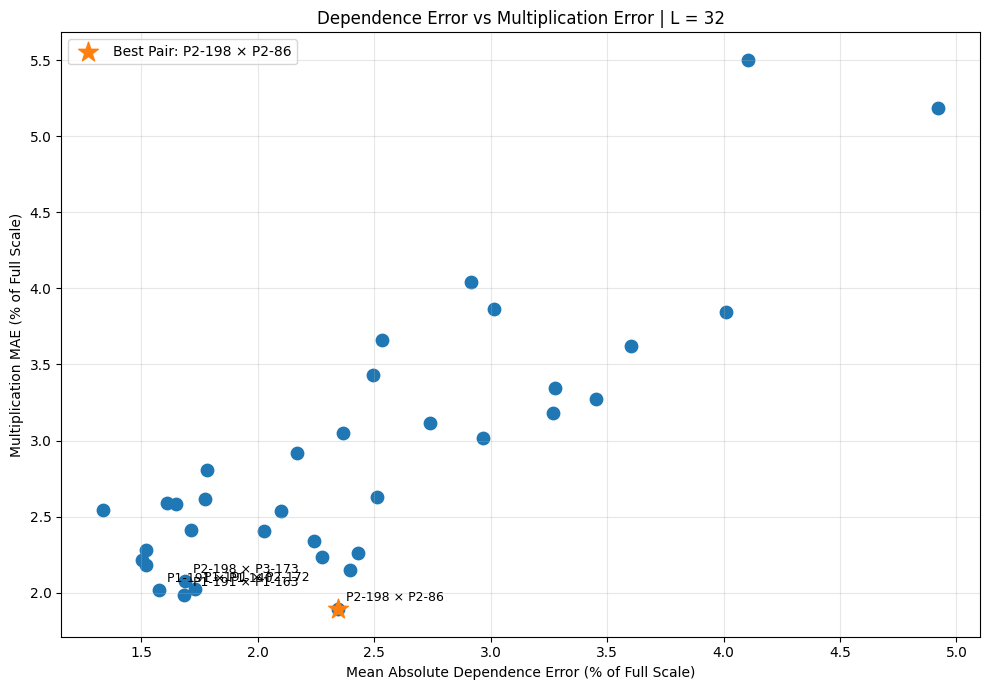

In [324]:
# ============================================================
# DEPENDENCE ERROR VS MULTIPLICATION MAE
# ============================================================

for L in STREAM_LENGTHS:

    subset = global_rankings[L].copy()

    dependence_mae = (
        subset["Mean_Absolute_Dependence_Error"] * 100
    )

    multiplication_mae = (
        subset["Multiplication_MAE"] * 100
    )

    plt.figure(figsize=(10, 7))

    plt.scatter(
        dependence_mae,
        multiplication_mae,
        s=80
    )

    # --------------------------------------------------------
    # Highlight best multiplication pair
    # --------------------------------------------------------

    best = subset.iloc[0]

    best_x = (
        best["Mean_Absolute_Dependence_Error"] * 100
    )

    best_y = (
        best["Multiplication_MAE"] * 100
    )

    plt.scatter(
        best_x,
        best_y,
        s=220,
        marker="*",
        label=f"Best Pair: {best['Pair']}"
    )

    # --------------------------------------------------------
    # Label top 5
    # --------------------------------------------------------

    for _, row in subset.head(5).iterrows():

        x = (
            row["Mean_Absolute_Dependence_Error"] * 100
        )

        y = (
            row["Multiplication_MAE"] * 100
        )

        plt.annotate(
            row["Pair"],
            (x, y),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

    plt.xlabel(
        "Mean Absolute Dependence Error (% of Full Scale)"
    )

    plt.ylabel(
        "Multiplication MAE (% of Full Scale)"
    )

    plt.title(
        f"Dependence Error vs Multiplication Error | L = {L}"
    )

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

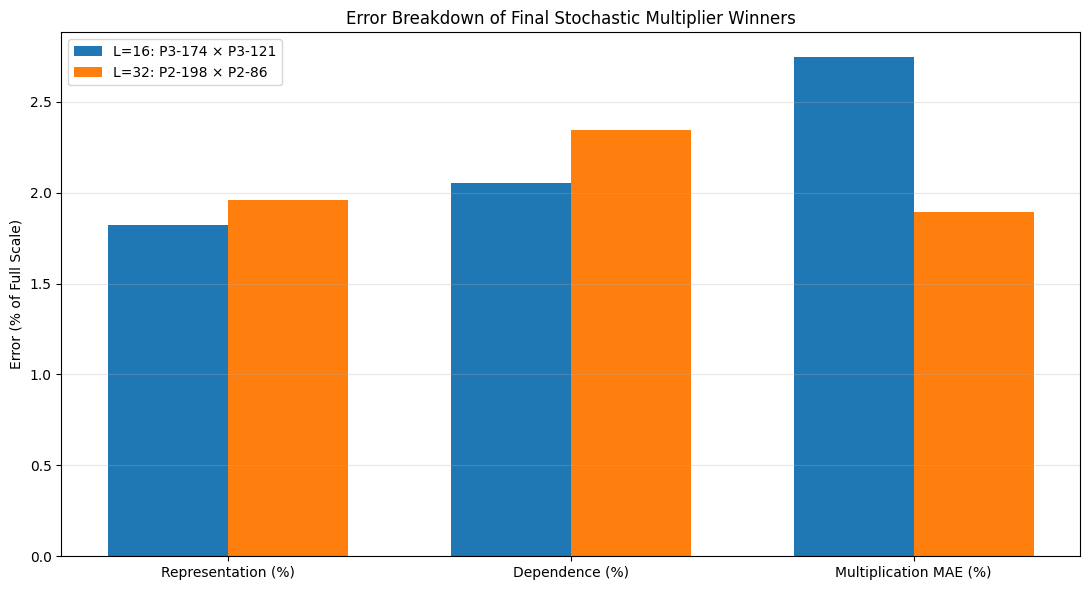

In [325]:
# ============================================================
# ERROR BREAKDOWN OF FINAL WINNERS
# ============================================================

comparison = final_global_winners_df.copy()

# Convert to percentages
comparison["Representation (%)"] = (
    comparison["Representation_Error"] * 100
)

comparison["Dependence (%)"] = (
    comparison["Dependence_Error"] * 100
)

comparison["Multiplication MAE (%)"] = (
    comparison["Multiplication_MAE"] * 100
)

metrics = [
    "Representation (%)",
    "Dependence (%)",
    "Multiplication MAE (%)"
]

x = np.arange(len(metrics))

width = 0.35

plt.figure(figsize=(11, 6))

for i, (_, row) in enumerate(comparison.iterrows()):

    offset = (
        (i - (len(comparison) - 1) / 2) * width
    )

    plt.bar(
        x + offset,
        row[metrics].values,
        width,
        label=(
            f"L={int(row['Stream_Length'])}: "
            f"{row['Best_Pair']}"
        )
    )

plt.xticks(
    x,
    metrics
)

plt.ylabel(
    "Error (% of Full Scale)"
)

plt.title(
    "Error Breakdown of Final Stochastic Multiplier Winners"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

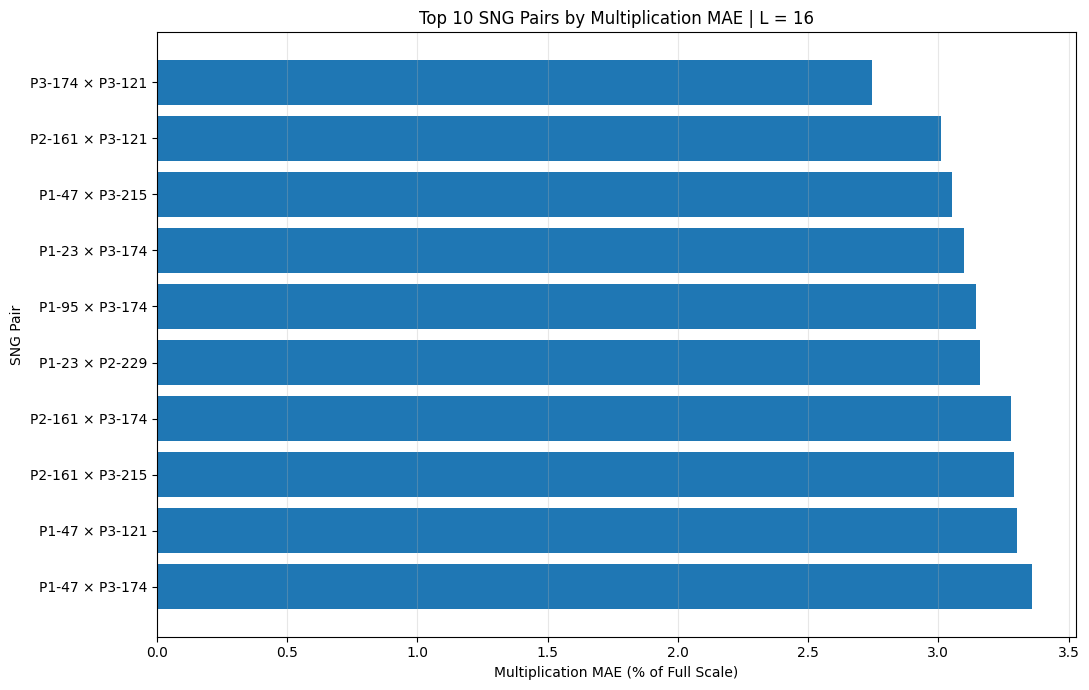

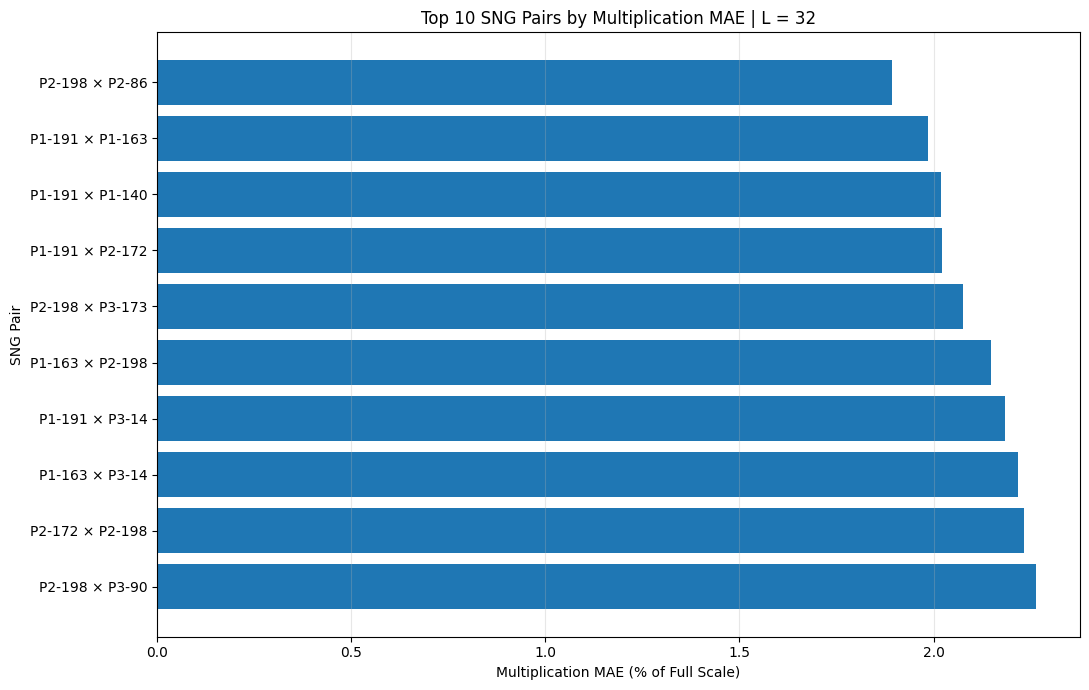

In [326]:
# ============================================================
# TOP-10 MULTIPLICATION MAE
# ============================================================

for L in STREAM_LENGTHS:

    top10 = (
        global_rankings[L]
        .sort_values("Multiplication_MAE")
        .head(10)
        .copy()
    )

    top10["MAE_Percent"] = (
        top10["Multiplication_MAE"] * 100
    )

    # Reverse order so best appears at the top
    top10 = top10.iloc[::-1]

    plt.figure(figsize=(11, 7))

    plt.barh(
        top10["Pair"],
        top10["MAE_Percent"]
    )

    plt.xlabel(
        "Multiplication MAE (% of Full Scale)"
    )

    plt.ylabel("SNG Pair")

    plt.title(
        f"Top 10 SNG Pairs by Multiplication MAE | L = {L}"
    )

    plt.grid(
        axis="x",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

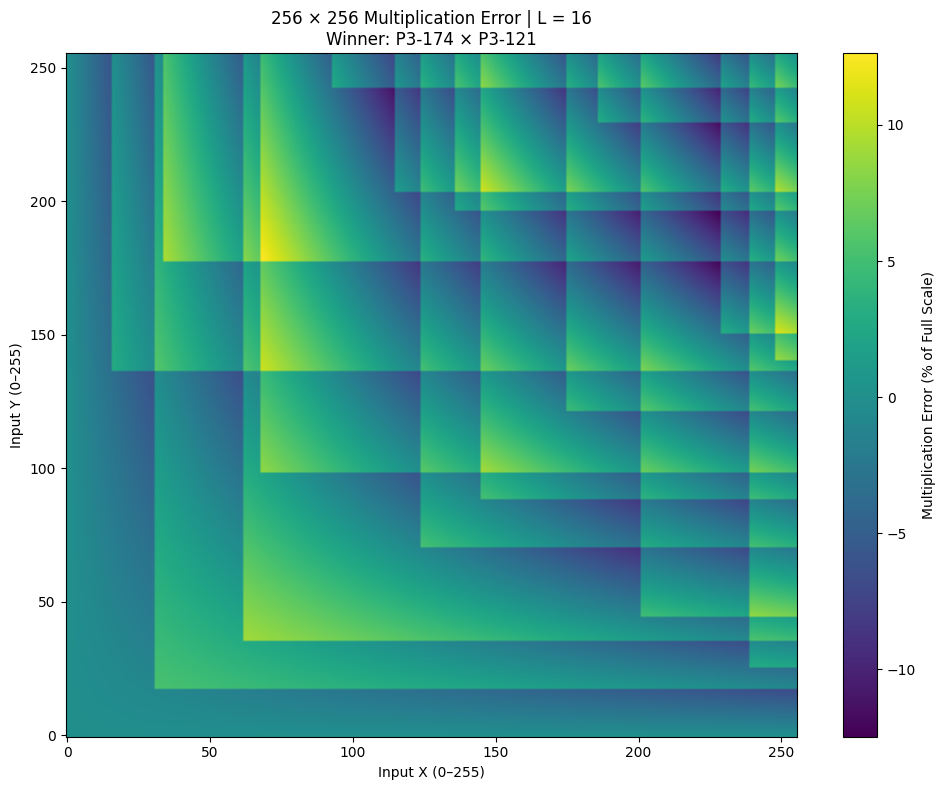

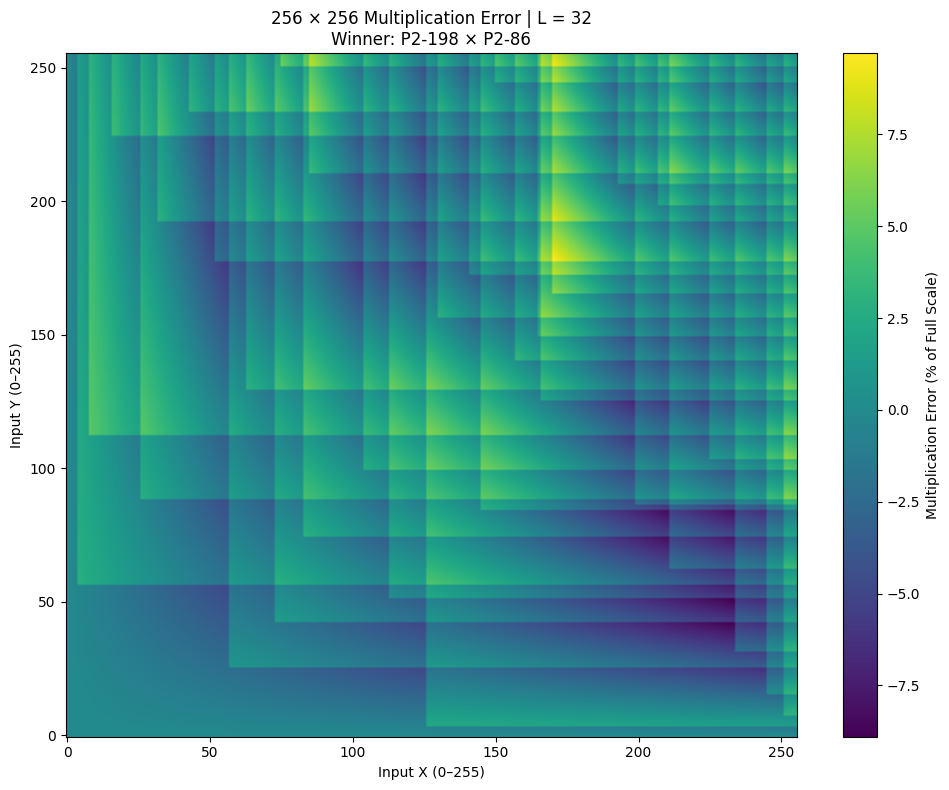

In [327]:
# ============================================================
# 256 × 256 MULTIPLICATION ERROR HEATMAP
# FINAL WINNER FOR EACH STREAM LENGTH
# ============================================================

for L in STREAM_LENGTHS:

    winner = final_global_winners_df[
        final_global_winners_df["Stream_Length"] == L
    ].iloc[0]

    best_pair = winner["Best_Pair"]

    config_a, config_b = best_pair.split(" × ")

    architecture_a, seed_a = config_a.rsplit("-", 1)
    architecture_b, seed_b = config_b.rsplit("-", 1)

    seed_a = int(seed_a)
    seed_b = int(seed_b)

    # --------------------------------------------------------
    # Retrieve cached streams
    # --------------------------------------------------------

    cache_a = candidate_stream_cache[
        (L, architecture_a, seed_a)
    ]

    cache_b = candidate_stream_cache[
        (L, architecture_b, seed_b)
    ]

    streams_a = cache_a["streams"]
    streams_b = cache_b["streams"]

    # --------------------------------------------------------
    # Calculate error matrix
    # --------------------------------------------------------

    error_matrix = np.zeros((256, 256))

    for X in range(256):

        A = streams_a[X]

        for Y in range(256):

            B = streams_b[Y]

            # Stochastic multiplication
            p_and = np.mean(A & B)

            # Ideal normalized product
            ideal = (X / 255.0) * (Y / 255.0)

            # Signed error
            error_matrix[Y, X] = p_and - ideal

    # --------------------------------------------------------
    # Convert to percentage
    # --------------------------------------------------------

    error_percent = error_matrix * 100

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(10, 8))

    im = plt.imshow(
        error_percent,
        origin="lower",
        aspect="auto"
    )

    plt.colorbar(
        im,
        label="Multiplication Error (% of Full Scale)"
    )

    plt.xlabel("Input X (0–255)")
    plt.ylabel("Input Y (0–255)")

    plt.title(
        f"256 × 256 Multiplication Error | L = {L}\n"
        f"Winner: {best_pair}"
    )

    plt.tight_layout()
    plt.show()

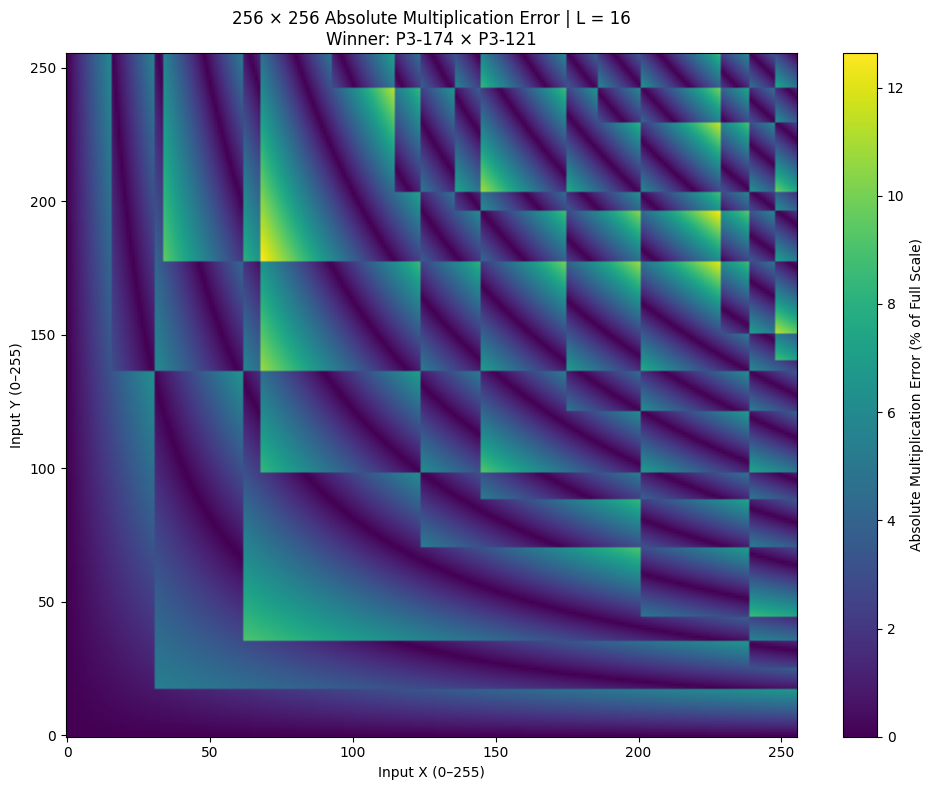

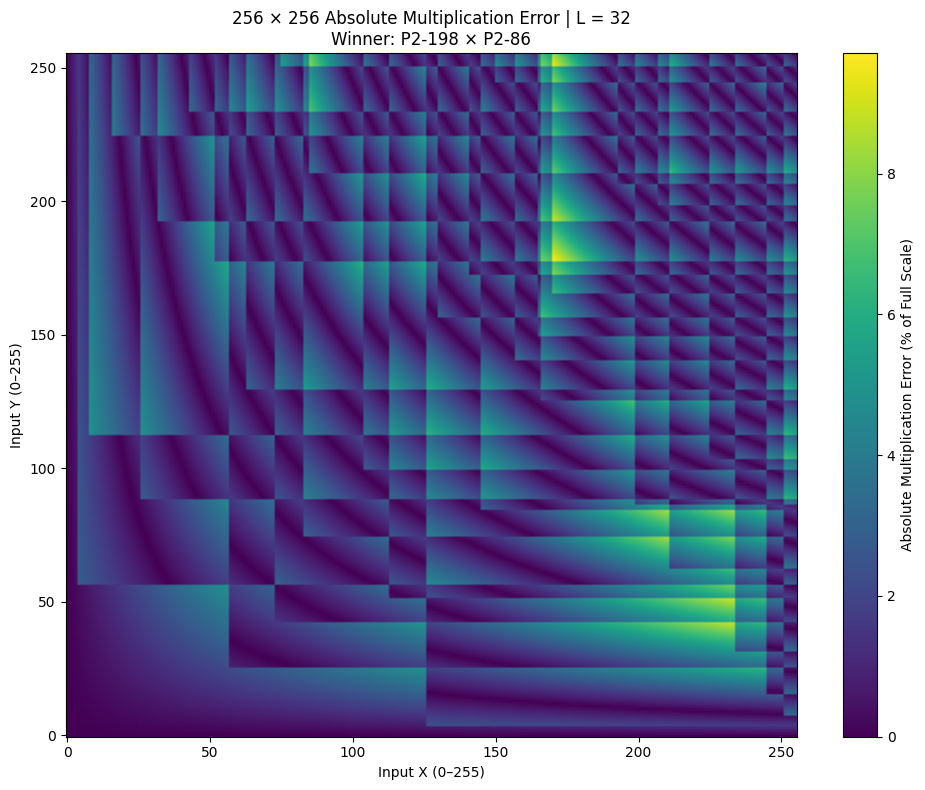

In [328]:
# ============================================================
# 256 × 256 ABSOLUTE MULTIPLICATION ERROR HEATMAP
# FINAL WINNER FOR EACH STREAM LENGTH
# ============================================================

for L in STREAM_LENGTHS:

    winner = final_global_winners_df[
        final_global_winners_df["Stream_Length"] == L
    ].iloc[0]

    best_pair = winner["Best_Pair"]

    config_a, config_b = best_pair.split(" × ")

    architecture_a, seed_a = config_a.rsplit("-", 1)
    architecture_b, seed_b = config_b.rsplit("-", 1)

    seed_a = int(seed_a)
    seed_b = int(seed_b)

    # Retrieve cached streams
    cache_a = candidate_stream_cache[
        (L, architecture_a, seed_a)
    ]

    cache_b = candidate_stream_cache[
        (L, architecture_b, seed_b)
    ]

    streams_a = cache_a["streams"]
    streams_b = cache_b["streams"]

    # --------------------------------------------------------
    # Calculate absolute error matrix
    # --------------------------------------------------------

    error_matrix = np.zeros((256, 256))

    for X in range(256):

        A = streams_a[X]

        for Y in range(256):

            B = streams_b[Y]

            # Stochastic AND multiplication
            p_and = np.mean(A & B)

            # Ideal normalized product
            ideal = (X / 255.0) * (Y / 255.0)

            # Absolute multiplication error
            error_matrix[Y, X] = abs(
                p_and - ideal
            )

    # Convert to percentage
    error_percent = error_matrix * 100

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(10, 8))

    im = plt.imshow(
        error_percent,
        origin="lower",
        aspect="auto"
    )

    plt.colorbar(
        im,
        label="Absolute Multiplication Error (% of Full Scale)"
    )

    plt.xlabel("Input X (0–255)")
    plt.ylabel("Input Y (0–255)")

    plt.title(
        f"256 × 256 Absolute Multiplication Error | L = {L}\n"
        f"Winner: {best_pair}"
    )

    plt.tight_layout()
    plt.show()

# Conclusion — Findings from the Stochastic Multiplier Study

## 1. Summary

This study investigated a hardware-oriented stochastic multiplier using **8-bit LFSR-based stochastic number generators (SNGs)** and an AND gate as the stochastic multiplication operator.

The investigation considered:

- Three maximal-length 8-bit Fibonacci LFSR configurations
- Multiple non-zero LFSR seeds
- Stream lengths of $L=16$ and $L=32$
- Individual stochastic representation accuracy
- Pairwise stream dependence
- Normalized multiplication error
- Integer-scale product error
- Relative multiplication percentage error
- Exhaustive evaluation over the complete $256\times256$ input space

The main objective was to identify SNG configurations that provide robust multiplication accuracy across the complete 8-bit input range rather than configurations optimized for only one particular input pair.

---

# 2. LFSR Configurations

Three maximal-length 8-bit Fibonacci LFSR configurations were investigated.

| Configuration | Taps | Feedback |
|---|---|---|
| **P1** | [7, 5, 4, 3] | $s_7\oplus s_5\oplus s_4\oplus s_3$ |
| **P2** | [7, 5, 4, 1] | $s_7\oplus s_5\oplus s_4\oplus s_1$ |
| **P3** | [7, 6, 1, 0] | $s_7\oplus s_6\oplus s_1\oplus s_0$ |

Each configuration produces a 255-state non-zero sequence.

The investigation showed that the LFSR polynomial alone does not determine the quality of a finite stochastic stream.

The seed also matters because it determines the starting point of the deterministic LFSR sequence.

Therefore, the effective SNG configuration can be viewed as

$$
\boxed{
\text{SNG}
=
(\text{Polynomial},\text{Seed},L)
}
$$

rather than simply the LFSR polynomial.

---

# 3. Importance of Exhaustive Evaluation

A major finding of this study is that selecting an SNG pair using only a few input values can be misleading.

Therefore, each selected candidate pair was evaluated over the complete 8-bit multiplication space:

$$
256\times256=65,536
$$

input combinations.

This means that the final ranking reflects the average behavior of the stochastic multiplier across the complete input range.

The reported winners should therefore be interpreted as:

> **The best-performing pairs within the exhaustively evaluated candidate pool.**

They should not be interpreted as the theoretically optimal pair among every possible stochastic architecture.

---

# 4. Error Analysis

The study established a clear distinction between the different types of error.

## 4.1 Representation Error

For an individual SNG:

$$
E_{\text{rep}}
=
|p_X-X/255|
$$

This measures how accurately the stochastic stream represents the requested input.

---

## 4.2 Dependence Error

The dependence error is

$$
E_{\text{dep}}
=
p_{AND}-p_Ap_B
$$

It measures the deviation from the ideal independent-stream relationship.

A low representation error does not necessarily guarantee low dependence error.

---

## 4.3 Normalized Multiplication Error

The normalized multiplication error is

$$
E_{\text{norm}}
=
p_{AND}
-
\left(\frac{A}{255}\right)
\left(\frac{B}{255}\right)
$$

The primary ranking metric is the mean absolute normalized multiplication error:

$$
MAE_{\text{mult}}
=
\operatorname{mean}
\left(
|E_{\text{norm}}|
\right)
$$

over the complete $256\times256$ input space.

---

# 5. Error Decomposition

The normalized multiplication error can be exactly decomposed as

$$
\boxed{
E_{\text{norm}}
=
E_{\text{dep}}
+
E_{\text{rep-prod}}
}
$$

where

$$
E_{\text{dep}}
=
p_{AND}-p_Ap_B
$$

and

$$
E_{\text{rep-prod}}
=
p_Ap_B
-
\left(\frac{A}{255}\right)
\left(\frac{B}{255}\right)
$$

This demonstrates that multiplication error is influenced by both **stream dependence** and **operand representation accuracy**.

Therefore, minimizing dependence error alone does not necessarily produce the best overall multiplier.

Likewise, excellent individual representation does not automatically guarantee the best multiplication performance.

---

# 6. Connection Between Normalized and Actual Product Error

The ideal integer product is

$$
P_{\text{actual}}=A\times B
$$

while the decoded stochastic product is

$$
P_{\text{SC}}
=
p_{AND}\times255^2
$$

Because

$$
\left(\frac{A}{255}\right)
\left(\frac{B}{255}\right)
=
\frac{A\times B}{255^2}
$$

the integer-scale error is related to the normalized error by

$$
\boxed{
P_{\text{SC}}-P_{\text{actual}}
=
E_{\text{norm}}\times255^2
}
$$

Therefore, the normalized multiplication error used during architecture evaluation and the actual numerical product error are **directly interconnected**.

They represent the same underlying error at different scales.

For an individual multiplication, the conventional relative error can additionally be calculated as

$$
\boxed{
E_{\text{relative}}
=
\frac{|P_{\text{SC}}-P_{\text{actual}}|}
{|P_{\text{actual}}|}
\times100\%
}
$$

This metric is useful for describing the error of a specific multiplication, while normalized MAE is more suitable for comparing architectures over the complete input space.

---

# 7. Effect of Stream Length

The investigation compared stream lengths of $L=16$ and $L=32$.

For $L=16$:

$$
\Delta p=\frac{1}{16}=6.25\%
$$

For $L=32$:

$$
\Delta p=\frac{1}{32}=3.125\%
$$

Thus, the $L=32$ stream provides twice the density resolution of the $L=16$ stream.

The exhaustive evaluation showed that the selected $L=32$ configuration achieved substantially lower average multiplication error than the selected $L=16$ configuration.

---

# 8. Final Selected SNG Pairs

The final selected configurations were:

| Stream Length | SNG Pair | Multiplication MAE | RMSE | Maximum Error |
|---|---|---:|---:|---:|
| **$L=16$** | **P3-174 × P3-121** | **2.7448%** | **3.4734%** | **12.6356%** |
| **$L=32$** | **P2-198 × P2-86** | **1.8916%** | **2.4183%** | **9.7141%** |

For $L=16$:

$$
\boxed{
\text{P3-174}\times\text{P3-121}
}
$$

was the best-performing pair within the evaluated candidate pool.

For $L=32$:

$$
\boxed{
\text{P2-198}\times\text{P2-86}
}
$$

was the best-performing pair within the evaluated candidate pool.

---

# 9. Improvement from $L=16$ to $L=32$

The selected $L=16$ configuration achieved

$$
MAE_{16}=0.027448
$$

while the selected $L=32$ configuration achieved

$$
MAE_{32}=0.018916
$$

The relative reduction in MAE is approximately

$$
\frac{0.027448-0.018916}{0.027448}\times100
\approx31.08\%
$$

Therefore, the selected $L=32$ configuration provides approximately

$$
\boxed{31.08\%}
$$

lower normalized multiplication MAE than the selected $L=16$ configuration.

---

# 10. Important Observation About Dependence

An important observation from the candidate evaluation is that the pair with the lowest dependence error is not necessarily the pair with the lowest multiplication MAE.

This follows directly from

$$
E_{\text{norm}}
=
E_{\text{dep}}
+
E_{\text{rep-prod}}
$$

Therefore, a pair may have excellent dependence characteristics but still exhibit relatively high multiplication error because of representation errors.

For this reason, **Multiplication MAE is retained as the primary SNG-pair selection metric**, while dependence error, representation error, RMSE, maximum error, and bias are used as supporting diagnostic metrics.

---

# 11. Practical Design Insight

The investigation demonstrates that stochastic multiplication should not be viewed simply as

$$
\boxed{
\text{LFSR}+\text{LFSR}+\text{AND}
}
$$

with arbitrary LFSR configurations.

The resulting accuracy depends on the combined choice of:

$$
\boxed{
\text{Polynomial}
+
\text{Seed}
+
\text{Stream Length}
+
\text{Input}
+
\text{Stream Relationship}
}
$$

The AND gate itself is extremely simple, but achieving good numerical accuracy requires careful design of the stochastic number generators.

---

# 12. Final Conclusion

The study successfully established a systematic methodology for investigating a hardware-oriented stochastic multiplier.

The main findings are:

1. **LFSR polynomial selection matters.**  
   Different feedback structures generate different deterministic state sequences.

2. **Seed selection matters.**  
   Different seeds change the starting point of the LFSR sequence and therefore affect finite-length stochastic behavior.

3. **Stream length matters.**  
   Increasing the stream length from $16$ to $32$ cycles improved the selected multiplication MAE by approximately **31.08%**.

4. **Representation error and dependence error are different.**  
   Good individual SNG representation does not automatically guarantee good multiplication.

5. **The two error sources are interconnected.**

$$
E_{\text{norm}}
=
E_{\text{dep}}
+
E_{\text{rep-prod}}
$$

6. **Normalized multiplication error and actual integer product error are directly related.**

$$
P_{\text{SC}}-P_{\text{actual}}
=
E_{\text{norm}}\times255^2
$$

7. **Normalized MAE is appropriate for architecture selection.**  
   It provides a common full-scale metric across the complete $256\times256$ input space.

8. **Relative percentage error is useful for individual results.**  
   It communicates how far a particular stochastic product is from the actual numerical product.

9. **Exhaustive evaluation provides a stronger basis for SNG selection** than evaluating only a few manually selected input combinations.

10. The final selected configurations are:

$$
\boxed{
L=16:\quad
\text{P3-174}\times\text{P3-121}
}
$$

and

$$
\boxed{
L=32:\quad
\text{P2-198}\times\text{P2-86}
}
$$

Overall, the study demonstrates that although stochastic multiplication requires very simple logic, its numerical accuracy depends strongly on the design of the stochastic number generators and on the relationship between their generated streams.

The selected SNG configurations will therefore be carried forward to the next stage of the project:

$$
\boxed{
\text{SNG Design}
\rightarrow
\text{RTL Implementation}
\rightarrow
\text{Stochastic Multiplier}
\rightarrow
\text{Booth Multiplier Comparison}
}
$$

The next stage will evaluate the resulting hardware in terms of **functional correctness, numerical accuracy, area, timing, and power**, providing a complete comparison between the stochastic and conventional multiplier implementations.

In [330]:
# ================================================================
# INTERACTIVE STOCHASTIC MULTIPLIER SIMULATOR
# ================================================================
#
# Select:
#   1. Vector / stream length: 16 or 32
#   2. Top-pair rank: 1 to 10
#   3. Input A: 0 to 255
#   4. Input B: 0 to 255
#
# The selected pair is taken directly from the exhaustive-search
# results already calculated in this notebook.
#
# ================================================================

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import re


# ================================================================
# 1. LFSR DEFINITIONS
# ================================================================

TAPS = {
    "P1": [7, 5, 4, 3],
    "P2": [7, 5, 4, 1],
    "P3": [7, 6, 1, 0]
}

POLYNOMIAL_DESCRIPTION = {
    "P1": "Taps [7,5,4,3] → feedback = s7 ⊕ s5 ⊕ s4 ⊕ s3",
    "P2": "Taps [7,5,4,1] → feedback = s7 ⊕ s5 ⊕ s4 ⊕ s1",
    "P3": "Taps [7,6,1,0] → feedback = s7 ⊕ s6 ⊕ s1 ⊕ s0"
}


# ================================================================
# 2. LFSR FUNCTIONS
# ================================================================

def lfsr_next_state(state, taps):

    feedback = 0

    for tap in taps:
        feedback ^= (state >> tap) & 1

    next_state = (state << 1) & 0xFF
    next_state |= feedback

    return next_state


def generate_lfsr_states(seed, polynomial, L):

    states = []
    state = int(seed)

    for _ in range(L):

        # Record current state first
        states.append(state)

        # Then advance LFSR
        state = lfsr_next_state(
            state,
            TAPS[polynomial]
        )

    return np.array(states, dtype=np.uint8)


def generate_stochastic_stream(input_value, states):

    return (
        states < int(input_value)
    ).astype(np.uint8)


# ================================================================
# 3. ROBUSTLY EXTRACT RANKINGS FROM global_rankings
# ================================================================

def convert_ranking_object(obj):
    """
    Convert a ranking object into a pandas DataFrame.

    Handles:
        - DataFrame
        - list of dictionaries
        - list of lists/tuples
        - dictionary of records
    """

    if isinstance(obj, pd.DataFrame):

        return obj.copy()

    if isinstance(obj, list):

        if len(obj) == 0:
            return pd.DataFrame()

        if isinstance(obj[0], dict):
            return pd.DataFrame(obj)

        # If list/tuple format such as:
        # [pair, MAE, RMSE, max_error, bias]
        if isinstance(obj[0], (list, tuple)):

            # Detect standard ranking format
            if len(obj[0]) >= 5:

                return pd.DataFrame(
                    obj,
                    columns=[
                        "Best_Pair",
                        "Multiplication_MAE",
                        "Multiplication_RMSE",
                        "Maximum_Absolute_Multiplication_Error",
                        "Multiplication_Bias"
                    ]
                )

            return pd.DataFrame(obj)

    if isinstance(obj, dict):

        # Dictionary of records
        try:
            return pd.DataFrame(obj)
        except Exception:
            pass

    return pd.DataFrame()


def find_stream_length_key(key):

    """
    Convert dictionary keys such as:
        16
        32
        "16"
        "L=16"
        "L_16"

    into integer stream lengths.
    """

    if isinstance(key, (int, np.integer)):

        return int(key)

    key = str(key)

    match = re.search(r'(\d+)', key)

    if match:
        return int(match.group(1))

    return None


def normalize_global_rankings():

    """
    Convert the notebook's global_rankings dictionary into:

        {
            16: DataFrame,
            32: DataFrame
        }

    """

    if "global_rankings" not in globals():

        raise RuntimeError(
            "global_rankings does not exist. "
            "Please run the exhaustive-search cells first."
        )

    raw = global_rankings

    print("Detected global_rankings type:",
          type(raw).__name__)

    # ------------------------------------------------------------
    # CASE 1: global_rankings itself is a DataFrame
    # ------------------------------------------------------------

    if isinstance(raw, pd.DataFrame):

        df = raw.copy()

        result = {}

        if "Stream_Length" in df.columns:

            for L in [16, 32]:

                sub = df[
                    df["Stream_Length"] == L
                ].copy()

                if len(sub) > 0:
                    result[L] = sub

        return result


    # ------------------------------------------------------------
    # CASE 2: global_rankings is a dictionary
    # ------------------------------------------------------------

    if isinstance(raw, dict):

        result = {}

        for key, value in raw.items():

            L = find_stream_length_key(key)

            if L not in [16, 32]:
                continue

            df = convert_ranking_object(value)

            if len(df) > 0:

                # Add stream length if missing
                if "Stream_Length" not in df.columns:

                    df["Stream_Length"] = L

                result[L] = df

        return result


    raise TypeError(
        "Unsupported global_rankings type: "
        + str(type(raw))
    )


# ================================================================
# 4. GET TOP PAIRS
# ================================================================

def find_pair_column(df):

    possible_columns = [
        "Best_Pair",
        "Pair",
        "SNG_Pair",
        "Candidate_Pair"
    ]

    for col in possible_columns:

        if col in df.columns:
            return col

    raise ValueError(
        "Could not find the SNG-pair column.\n"
        f"Available columns: {list(df.columns)}"
    )


def get_top_pairs(L):

    rankings = normalize_global_rankings()

    if L not in rankings:

        raise ValueError(
            f"No ranking data found for L={L}.\n"
            f"Available lengths: {list(rankings.keys())}"
        )

    df = rankings[L].copy()

    pair_column = find_pair_column(df)

    # ------------------------------------------------------------
    # Sort exactly according to the project's primary metric
    # ------------------------------------------------------------

    if "Multiplication_MAE" in df.columns:

        df = df.sort_values(
            by="Multiplication_MAE",
            ascending=True
        ).reset_index(drop=True)

    return df.head(10).copy()


# ================================================================
# 5. PARSE PAIR
# ================================================================

def parse_pair(pair_string):

    """
    Converts:

        P3–174 × P3–121

    into:

        P3, 174, P3, 121
    """

    pair_string = str(pair_string)

    pair_string = (
        pair_string
        .replace("–", "-")
        .replace("—", "-")
        .replace("×", "x")
        .replace("X", "x")
    )

    parts = re.split(
        r"\s*x\s*",
        pair_string
    )

    if len(parts) != 2:

        raise ValueError(
            f"Could not parse pair: {pair_string}"
        )

    left = parts[0].strip()
    right = parts[1].strip()

    m1 = re.match(
        r"(P[123])-(\d+)",
        left
    )

    m2 = re.match(
        r"(P[123])-(\d+)",
        right
    )

    if m1 is None or m2 is None:

        raise ValueError(
            f"Could not parse pair: {pair_string}"
        )

    return (
        m1.group(1),
        int(m1.group(2)),
        m2.group(1),
        int(m2.group(2))
    )


# ================================================================
# 6. RUN ONE SIMULATION
# ================================================================

def simulate_selected_pair(
    L,
    rank,
    A,
    B
):

    top_df = get_top_pairs(L)

    if rank < 1 or rank > len(top_df):

        raise ValueError(
            f"Rank {rank} is unavailable for L={L}."
        )

    selected = top_df.iloc[rank - 1]

    pair_column = find_pair_column(top_df)

    pair_name = selected[pair_column]

    arch_a, seed_a, arch_b, seed_b = parse_pair(
        pair_name
    )

    # ============================================================
    # Generate LFSR states
    # ============================================================

    states_a = generate_lfsr_states(
        seed_a,
        arch_a,
        L
    )

    states_b = generate_lfsr_states(
        seed_b,
        arch_b,
        L
    )

    # ============================================================
    # Generate stochastic streams
    # ============================================================

    stream_a = generate_stochastic_stream(
        A,
        states_a
    )

    stream_b = generate_stochastic_stream(
        B,
        states_b
    )

    # ============================================================
    # AND stochastic multiplication
    # ============================================================

    stream_out = stream_a & stream_b

    # ============================================================
    # Counts
    # ============================================================

    ones_a = int(np.sum(stream_a))
    ones_b = int(np.sum(stream_b))
    ones_out = int(np.sum(stream_out))

    # ============================================================
    # Measured densities
    # ============================================================

    p_a = ones_a / L
    p_b = ones_b / L
    p_out = ones_out / L

    # ============================================================
    # Ideal normalized values
    # ============================================================

    x = A / 255.0
    y = B / 255.0

    ideal_product = x * y

    # ============================================================
    # Representation errors
    # ============================================================

    signed_rep_a = p_a - x
    signed_rep_b = p_b - y

    abs_rep_a = abs(signed_rep_a)
    abs_rep_b = abs(signed_rep_b)

    # ============================================================
    # Dependence error
    # ============================================================

    independent_product = p_a * p_b

    dependence_error = (
        p_out -
        independent_product
    )

    # ============================================================
    # Representation-product error
    # ============================================================

    representation_product_error = (
        independent_product -
        ideal_product
    )

    # ============================================================
    # Normalized multiplication error
    # ============================================================

    normalized_multiplication_error = (
        p_out -
        ideal_product
    )

    # ============================================================
    # Integer product
    # ============================================================

    actual_product = A * B

    stochastic_product = (
        p_out * (255 ** 2)
    )

    signed_integer_error = (
        stochastic_product -
        actual_product
    )

    absolute_integer_error = abs(
        signed_integer_error
    )

    # ============================================================
    # Conventional relative error
    # ============================================================

    if actual_product != 0:

        relative_error = (
            absolute_integer_error /
            abs(actual_product)
        )

        signed_relative_error = (
            signed_integer_error /
            actual_product
        )

    else:

        relative_error = None
        signed_relative_error = None

    # ============================================================
    # Print header
    # ============================================================

    print("\n")
    print("=" * 90)
    print("        INTERACTIVE STOCHASTIC MULTIPLIER SIMULATION")
    print("=" * 90)

    print(f"\nVector / Stream Length : {L}")
    print(f"Selected Pair Rank     : #{rank}")
    print(f"Selected SNG Pair      : {pair_name}")

    print("\n" + "-" * 90)
    print("SNG CONFIGURATION")
    print("-" * 90)

    print(
        f"SNG A = {arch_a}-{seed_a}"
    )

    print(
        POLYNOMIAL_DESCRIPTION[arch_a]
    )

    print(
        f"\nSNG B = {arch_b}-{seed_b}"
    )

    print(
        POLYNOMIAL_DESCRIPTION[arch_b]
    )

    print("\n" + "-" * 90)
    print("INPUTS")
    print("-" * 90)

    print(
        f"A = {A}"
        f"   → ideal normalized value = {x:.6f}"
    )

    print(
        f"B = {B}"
        f"   → ideal normalized value = {y:.6f}"
    )

    # ============================================================
    # LFSR state + stochastic bit table
    # ============================================================

    print("\n" + "-" * 90)
    print("CLOCK-BY-CLOCK STOCHASTIC GENERATION")
    print("-" * 90)

    cycle_df = pd.DataFrame({

        "Cycle":
            np.arange(1, L + 1),

        "LFSR State A":
            states_a,

        "Stochastic Bit A":
            stream_a,

        "LFSR State B":
            states_b,

        "Stochastic Bit B":
            stream_b,

        "AND Output":
            stream_out
    })

    display(cycle_df)

    # ============================================================
    # Bitstream strings
    # ============================================================

    print("\n" + "-" * 90)
    print("STOCHASTIC BITSTREAMS")
    print("-" * 90)

    print(
        f"\nStream A ({L} bits):"
    )

    print(
        "".join(
            map(str, stream_a)
        )
    )

    print(
        f"\nStream B ({L} bits):"
    )

    print(
        "".join(
            map(str, stream_b)
        )
    )

    print(
        f"\nAND Output ({L} bits):"
    )

    print(
        "".join(
            map(str, stream_out)
        )
    )

    # ============================================================
    # Density table
    # ============================================================

    print("\n" + "-" * 90)
    print("1-COUNTS AND STOCHASTIC DENSITIES")
    print("-" * 90)

    density_df = pd.DataFrame({

        "Stream": [
            "A",
            "B",
            "AND Output"
        ],

        "Number of 1s": [
            ones_a,
            ones_b,
            ones_out
        ],

        "Measured Density": [
            p_a,
            p_b,
            p_out
        ],

        "Measured (%)": [
            p_a * 100,
            p_b * 100,
            p_out * 100
        ],

        "Ideal Density": [
            x,
            y,
            ideal_product
        ],

        "Ideal (%)": [
            x * 100,
            y * 100,
            ideal_product * 100
        ]
    })

    display(density_df)

    # ============================================================
    # Error table
    # ============================================================

    print("\n" + "-" * 90)
    print("ERROR ANALYSIS")
    print("-" * 90)

    error_df = pd.DataFrame({

        "Metric": [

            "A representation error",

            "B representation error",

            "Dependence error",

            "Representation-product error",

            "Normalized multiplication error",

            "Absolute product error",

            "Relative multiplication error",

            "Signed relative error"
        ],

        "Value": [

            abs_rep_a,

            abs_rep_b,

            dependence_error,

            representation_product_error,

            normalized_multiplication_error,

            absolute_integer_error,

            (
                relative_error
                if relative_error is not None
                else np.nan
            ),

            (
                signed_relative_error
                if signed_relative_error is not None
                else np.nan
            )
        ],

        "Percentage": [

            abs_rep_a * 100,

            abs_rep_b * 100,

            dependence_error * 100,

            representation_product_error * 100,

            normalized_multiplication_error * 100,

            np.nan if actual_product == 0
            else (
                absolute_integer_error /
                (255 ** 2) * 100
            ),

            np.nan if relative_error is None
            else relative_error * 100,

            np.nan if signed_relative_error is None
            else signed_relative_error * 100
        ]
    })

    display(error_df)

    # ============================================================
    # Final numerical result
    # ============================================================

    print("\n" + "-" * 90)
    print("FINAL MULTIPLICATION RESULT")
    print("-" * 90)

    print(
        f"\nActual product:"
        f"                 {actual_product}"
    )

    print(
        f"Stochastic decoded product:"
        f"    {stochastic_product:.6f}"
    )

    print(
        f"Absolute product error:"
        f"           {absolute_integer_error:.6f}"
    )

    print(
        f"Signed product error:"
        f"             {signed_integer_error:+.6f}"
    )

    if relative_error is not None:

        print(
            f"Relative multiplication error:"
            f"  {relative_error * 100:.4f}%"
        )

        print(
            f"Signed relative error:"
            f"          {signed_relative_error * 100:+.4f}%"
        )

    else:

        print(
            "Relative multiplication error:"
            "  N/A (actual product = 0)"
        )

    # ============================================================
    # Error decomposition
    # ============================================================

    print("\n" + "-" * 90)
    print("ERROR DECOMPOSITION")
    print("-" * 90)

    print(
        f"\nDependence error:"
        f"              {dependence_error:+.8f}"
    )

    print(
        f"Representation-product error:"
        f"    {representation_product_error:+.8f}"
    )

    print(
        f"Sum:"
        f"                         {decomposition_check if False else (dependence_error + representation_product_error):+.8f}"
    )

    print(
        f"Normalized multiplication error:"
        f" {normalized_multiplication_error:+.8f}"
    )

    check_value = (
        dependence_error +
        representation_product_error
    )

    if np.isclose(
        check_value,
        normalized_multiplication_error
    ):

        print(
            "\n✓ Decomposition verified:"
            " dependence + representation-product"
            " = normalized multiplication error"
        )

    else:

        print(
            "\n⚠ Decomposition check failed."
        )

    # ============================================================
    # Selected pair's exhaustive performance
    # ============================================================

    print("\n" + "-" * 90)
    print("SELECTED PAIR'S EXHAUSTIVE-SEARCH PERFORMANCE")
    print("-" * 90)

    ranking_columns = [

        c for c in [

            "Stream_Length",

            pair_column,

            "Multiplication_MAE",

            "Multiplication_RMSE",

            "Maximum_Absolute_Multiplication_Error",

            "Multiplication_Bias",

            "Mean_Absolute_Dependence_Error",

            "Mean_Absolute_Representation_Error"

        ]

        if c in selected.index
    ]

    selected_info = (
        selected[ranking_columns]
        .to_frame("Value")
    )

    display(selected_info)

    print("\n" + "=" * 90)


# ================================================================
# 7. CREATE WIDGETS
# ================================================================

# First test that ranking information is available
ranking_data = normalize_global_rankings()

print("\nAvailable ranking lengths:")

for L in ranking_data:
    print(
        f"  L = {L}: "
        f"{len(ranking_data[L])} ranking entries"
    )


length_widget = widgets.Dropdown(

    options=[16, 32],

    value=32,

    description="Vector Length:",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="240px"
    )
)


rank_widget = widgets.Dropdown(

    options=[
        (
            f"Rank #{i}",
            i
        )
        for i in range(1, 11)
    ],

    value=1,

    description="Top Pair:",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="240px"
    )
)


A_widget = widgets.IntText(

    value=170,

    min=0,

    max=255,

    description="Input A:",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="240px"
    )
)


B_widget = widgets.IntText(

    value=150,

    min=0,

    max=255,

    description="Input B:",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="240px"
    )
)


run_button = widgets.Button(

    description="▶ RUN SIMULATION",

    button_style="primary",

    layout=widgets.Layout(
        width="240px",
        height="42px"
    )
)


output_widget = widgets.Output()


# ================================================================
# 8. RUN BUTTON
# ================================================================

def on_run_clicked(_):

    with output_widget:

        clear_output(wait=True)

        try:

            A = int(
                np.clip(
                    A_widget.value,
                    0,
                    255
                )
            )

            B = int(
                np.clip(
                    B_widget.value,
                    0,
                    255
                )
            )

            simulate_selected_pair(

                L=length_widget.value,

                rank=rank_widget.value,

                A=A,

                B=B
            )

        except Exception as e:

            print(
                "\nSimulation error:"
            )

            print(
                type(e).__name__,
                ":",
                e
            )


run_button.on_click(
    on_run_clicked
)


# ================================================================
# 9. DISPLAY INTERFACE
# ================================================================

display(
    HTML(
        """
        <h2>
        Interactive Stochastic Multiplier
        </h2>

        <p>
        Select the <b>vector length</b>, the
        <b>Top-N SNG pair</b>, and any two
        <b>8-bit inputs A and B</b>.
        </p>

        <p>
        The SNG pair is taken directly from the
        exhaustive candidate-pool ranking.
        Ranking is based primarily on
        <b>Multiplication MAE</b>.
        </p>

        <p>
        The simulation then shows the complete chain:
        <b>
        LFSR state → comparator → stochastic bit
        → AND → output stream → density
        → decoded product → error analysis
        </b>.
        </p>
        """
    )
)


display(
    widgets.VBox([

        widgets.HBox([
            length_widget,
            rank_widget
        ]),

        widgets.HBox([
            A_widget,
            B_widget
        ]),

        run_button

    ])
)


display(
    output_widget
)


# ================================================================
# 10. RUN DEFAULT SIMULATION
# ================================================================

on_run_clicked(None)

Detected global_rankings type: dict

Available ranking lengths:
  L = 16: 36 ranking entries
  L = 32: 36 ranking entries


Output()